# Structural Sampling (Error)

This script builds a substrate environment to filter and cluster simulation datasets using a `KMeansSampler`. However, the execution fails because the filtered dataset contains an unaligned data type that violates the requirements of `sampler.setup()`, which strictly expects a list composed of `ase.Atoms` or `agox.candidates.Candidate` objects.

In [28]:
import os
import numpy as np
from ase.build import surface, bulk
from ase.io import write

from agox.environments import Environment
from agox.databases import Database
from agox.models.descriptors.fingerprint import Fingerprint
from agox.samplers import KMeansSampler

# Custom stack building modules
from scripts.build_mgo_stack import build_mgo_stack
from scripts.build_fe_stack import build_fe_stack
from scripts.build_heteroStruct import build_heteroStruct

# === System Parameters ===
vacuum = 20
a_mgo = 4.212
a_fe = 2.870190
dist_z_fe2o = 0.5 
supercell = (5, 5, 1)
sample_size = 20

# === Path Configuration ===
db_path = f'1_result/1_1ML_feOnMgo/1_db/db_0.db'

# === Lattice Matching and Base Slabs ===
bulk_mgo = bulk('MgO', 'rocksalt', a=a_mgo, cubic=True)
slab_fe_base = surface('Fe', (0, 0, 1), layers=1, vacuum=vacuum)

# === Substrate and Deposition Stacks ===
slab_mgofe = build_mgo_stack(slab_fe_base, num_layers=1, vacuum=vacuum)
slab_mgo = slab_mgofe[[atom.symbol != 'Fe' for atom in slab_mgofe]].repeat(supercell)
slab_fe = build_fe_stack(slab_fe_base, num_layers=1, vacuum=vacuum).repeat(supercell)

slab_substrate = slab_mgo.copy()
slab_deposition = slab_fe.copy()

# === AGOX Environment Geometry Setup ===
slab_substrate.pbc = [True, True, False]
confinement_corner = np.array([0, 0, slab_substrate.positions[:, 2].max() + dist_z_fe2o])

z_pos = slab_deposition.get_positions()[:, 2]
h_dep = max(z_pos.max() - z_pos.min(), 2.1)
confinement_cell = slab_deposition.cell.copy()
confinement_cell[2, 2] = h_dep * 4

environment = Environment(
    template=slab_substrate,
    symbols=slab_deposition.get_chemical_formula(),
    confinement_cell=confinement_cell,
    confinement_corner=confinement_corner,
    box_constraint_pbc=[True, True, False]
)

# === Database Loading and Sampling ===
if os.path.exists(db_path):
    db = Database(filename=db_path)
    all_structures = db.restore_to_trajectory() 
    print(f"Total structures in DB: {len(all_structures)}")

    # Initialize clustering descriptors and samplers
    descriptor = Fingerprint(environment=environment)
    sampler = KMeansSampler(
        descriptor=descriptor, 
        sample_size=20, 
        max_energy=500 
    )

    # Process and filter structural sample data
    try:
        filtered_structures = sampler.filters.filter(all_structures)
        print(f"Structures after energy filtering: {len(filtered_structures)}")
        
        if len(filtered_structures) == 0:
            print("ALERT: Energy filter is still too strict! Increase max_energy.")
        else:
            sampler.setup(filtered_structures)
            sample = sampler.get_sample(5)
            print(f"SUCCESS: Sampler retrieved {len(sample)} members.")
            write('check_sampler.xsf', sample[0])
    except Exception as e:
        print(f"Error: {e}")

╭───────────────────────────── Environment report ─────────────────────────────╮
│ Atoms in search:                                                             │
│     Fe = 25                                                                  │
│ Template formula: Mg25O25                                                    │
│ Full formula: Fe25Mg25O25                                                    │
│ Cell:                                                                        │
│     14.35 0.00 0.00                                                          │
│     0.00 14.35 0.00                                                          │
│     0.00 0.00 43.73                                                          │
│ Periodicity:                                                                 │
│     True True False                                                          │
│ Box constraint: True                                                         │
│ Confinement corner                                                           │
│     0.00 0.00 24.23                                                          │
│ Confinement cell:                                                            │
│     14.35 0.00 0.00                                                          │
│     0.00 14.35 0.00                                                          │
│     0.00 0.00 8.40                                                           │
╰──────────────────────────────────────────────────────────────────────────────╯

Total structures in DB: 108
Structures after energy filtering: 2
Error: 'list' object has no attribute 'get_potential_energy'


# Database Inspection Script

This script executes an inspection utility to filter and analyze an AGOX simulation database within a designated iteration range while safely handling file errors.

In [65]:
from scripts.inspect_database import inspect_database

# === Target Dataset Settings ===
# database_filename = '1_result/45_fxg_3b/seed_0/1_db/db_0.db' 
# database_filename = '1_result/47_3_3boron/seed_0/1_db/db_0.db' 
database_filename = '1_result/43_fxg_0b/seed_0/1_db/db_0.db' 

  # (f'{dir_simul}/42_amorph_seed_3x3', 42),
    # (f'{dir_simul}/43_fxg_0b', 43),
    # (f'{dir_simul}/44_fxg_1b', 44),
    # (f'{dir_simul}/45_fxg_3b', 45),
    # (f'{dir_simul}/61_fxg_5b', 61),

    # (f'{dir_simul}/46_1_1boron', 46),
    # (f'{dir_simul}/47_3_3boron', 47)

    # (f'{dir_simul}/58_pt0b', 58),
    # (f'{dir_simul}/59_pt1b', 59),
    # (f'{dir_simul}/60_pt3b', 60),

# Set your desired iteration range bounds here
iteration_A = 0
iteration_B = 50

# === Database Inspection Execution ===
try:
    inspect_database(database_filename, start_iter=iteration_A, end_iter=iteration_B)
except FileNotFoundError:
    print(f"Error: The file '{database_filename}' was not found. Please check your path.")

Connecting to database: 1_result/43_fxg_0b/seed_0/1_db/db_0.db

Total structures found (from iteration 0 to 50): 61
------------------------------------------------------------
Structure ID   | Iteration  | Energy (eV)  | Number of Atoms
------------------------------------------------------------
1              | 1          | -494.3792    | 54             
2              | 1          | -500.0647    | 54             
3              | 2          | -497.0442    | 54             
4              | 2          | -501.7799    | 54             
5              | 3          | -495.1070    | 54             
6              | 3          | -500.7671    | 54             
7              | 4          | -495.7138    | 54             
8              | 4          | -501.9563    | 54             
9              | 5          | -494.1527    | 54             
10             | 5          | -500.5414    | 54             
11             | 6          | -491.7544    | 54             
12             | 6          | 

# Landscape Generation and Density Plotter
This script generates a synthetic rugged potential energy surface to extract its local minima, maps its density of states via a kernel density estimation, and visualizes the aligned relationship side-by-side.

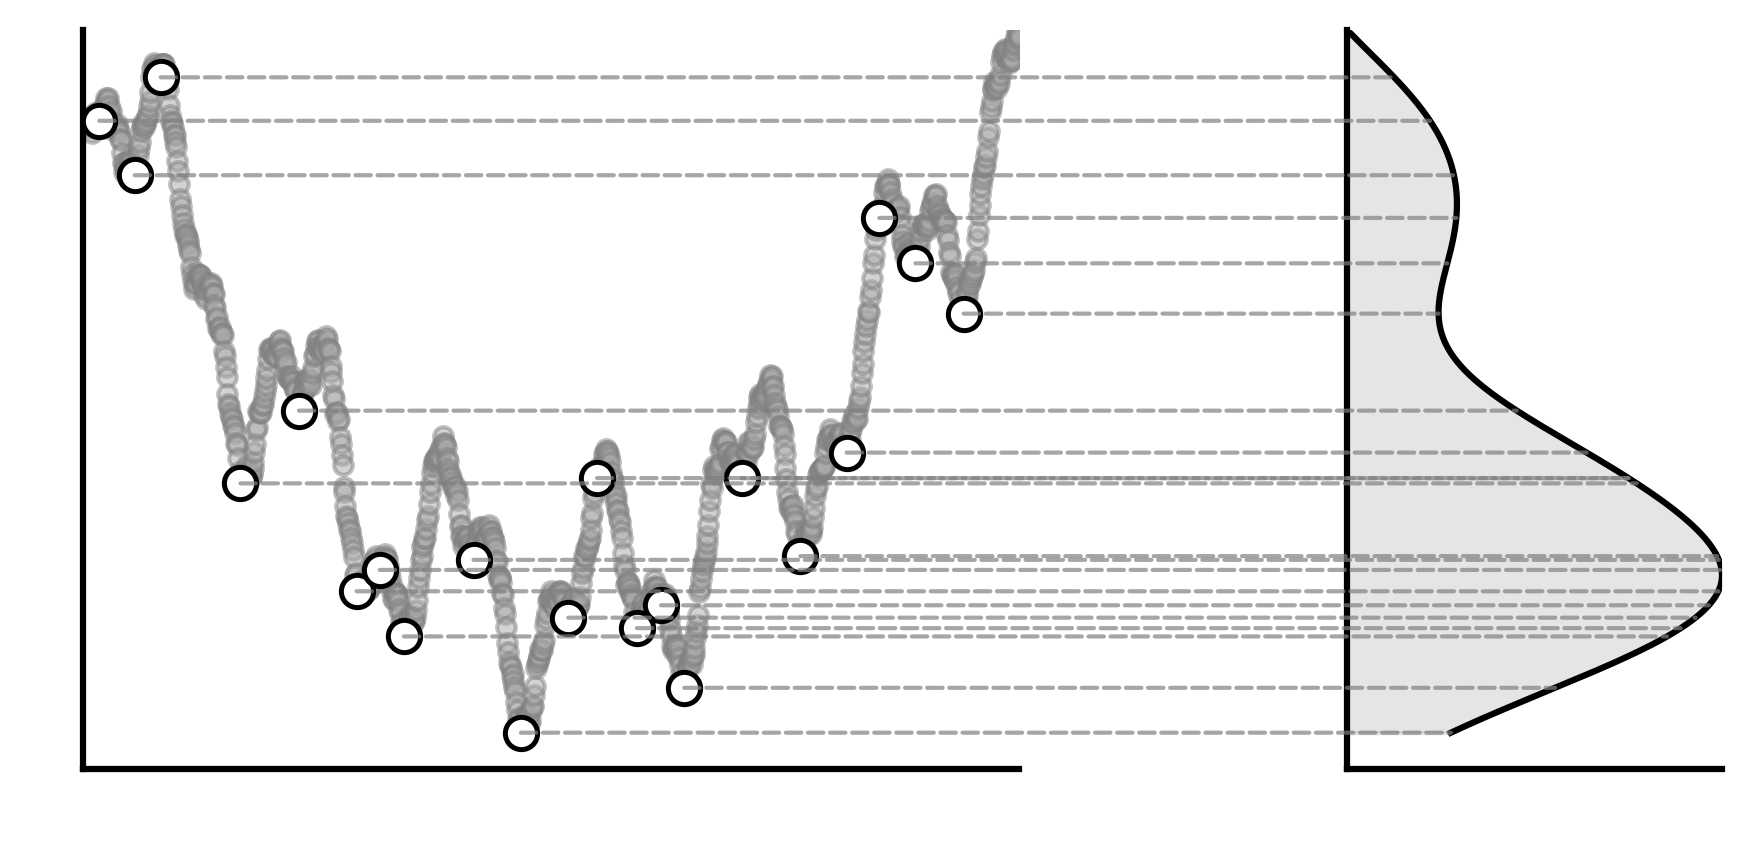

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.stats import gaussian_kde
from matplotlib.patches import ConnectionPatch

# === Tuning Parameters ===
kde_smoothing = 0.4
graph_distance = 0.5  # Adjusts spacing between the two subplots

# === Potential Energy Surface Generation ===
np.random.seed(42)
x = np.linspace(0, 50, 1000)

# Build a parabolic well envelope with overlapping micro-oscillations
y_container = 0.015 * (x - 25)**2
y_oscillations = -1.5 * np.cos(x * 0.8) + 0.8 * np.sin(x * 2.1)
y_base = y_container + y_oscillations

# Add fine-grained noise to simulate micro-barriers
noise = 0.15 * np.sin(x * 10) + 0.05 * np.random.normal(size=len(x))
y_raw = y_base + noise

# Shift absolute minimum to zero and apply scaling compression
y_shifted = y_raw - y_raw.min()
compression_factor = 0.8  
y = y_shifted * compression_factor

# === Peak Detection and Trough Extraction ===
minima_indices, _ = find_peaks(-y, distance=25, prominence=0.1)
minima_energies = y[minima_indices]
minima_x = x[minima_indices]

# === Density of States Estimation ===
kde = gaussian_kde(minima_energies, bw_method=kde_smoothing)
y_eval = np.linspace(y.min(), y.max(), 500)
dos_density = kde(y_eval)

# === Side-by-Side Visualization ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 3), dpi=300, gridspec_kw={'width_ratios': [2.5, 1]})

# --- Left Plot: Rugged Potential Energy Surface ---
ax1.scatter(x, y, color='darkgray', edgecolor='gray', s=20, alpha=0.5, zorder=2)
ax1.scatter(
    minima_x, minima_energies, 
    facecolors='white', 
    edgecolors='black', 
    linewidths=1.2, 
    s=60, 
    zorder=4
)

# Format left plot axes
ax1.set_xlabel(' ', fontsize=9)
ax1.set_ylabel(' ', fontsize=9)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_xticklabels([])
ax1.set_yticklabels([])
ax1.set_xticks([])
ax1.set_yticks([])
ax1.set_xlim(x.min() - 0.5, x.max())
ax1.set_ylim(y.min() - 0.5, y.max())

# --- Right Plot: Density of States ---
ax2.plot(dos_density, y_eval, color='black', linewidth=1.5, label='KDE (DOS)', zorder=3)
ax2.fill_betweenx(y_eval, 0, dos_density, color='gray', alpha=0.2, zorder=2)

# Format right plot axes
ax2.set_ylim(ax1.get_ylim())
ax2.set_xlabel(' ', fontsize=9)
ax2.set_ylabel(' ', fontsize=9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_xticklabels([])
ax2.set_yticklabels([])
ax2.set_xticks([])
ax2.set_yticks([])
ax2.set_xlim(dos_density.min(), dos_density.max())
ax2.set_ylim(y_eval.min() - 0.5, y_eval.max())

# --- Cross-Axes Alignment Lines ---
for mx, my in zip(minima_x, minima_energies):
    kde_val = kde(my)[0]
    con = ConnectionPatch(
        xyA=(mx, my), coordsA=ax1.transData,
        xyB=(kde_val, my), coordsB=ax2.transData,
        axesA=ax1, axesB=ax2,
        color='gray', linestyle='--', linewidth=1.0, alpha=0.7, zorder=1
    )
    fig.add_artist(con)

# Layout adjustments and file export
plt.tight_layout()
plt.subplots_adjust(wspace=graph_distance)
plt.savefig('rugged_pes_and_dos.png', dpi=300, bbox_inches='tight')
plt.show()

# Plotting Style and Label Configuration
This script configures a global Matplotlib style with serif typography and boxed axes for publication-ready figures, and defines a reusable LaTeX energy label.

In [78]:
import matplotlib.pyplot as plt

# === Color Palette Definitions ===
colors = [
    '#FF0000',  # Pure Bold Red
    '#00FF00',  # Pure Bold Green
]

# === Matplotlib Global Configuration (rcParams) ===
custom_rc_params = {
    # Typography
    'font.size': 12,
    'font.family': 'serif',

    # Axes and Borders
    'axes.linewidth': 1.5,
    'axes.edgecolor': 'black',
    'axes.spines.top': True,
    'axes.spines.right': True,

    # Major Ticks (Outer edge "boxed" look)
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.major.size': 5,
    'ytick.major.size': 5,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'xtick.top': True,
    'ytick.right': True,

    # Minor Ticks
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'xtick.minor.size': 2,
    'ytick.minor.size': 2,
    'xtick.minor.width': 1.0,
    'ytick.minor.width': 1.0,

    # Miscellaneous (Grid and Legend)
    'axes.grid': False,
    'legend.frameon': True,
}

# Apply the custom style settings
plt.rcParams.update(custom_rc_params)

# === Plot Labels and LaTeX Formatting ===
# Alternative: e_label = r'$E_{rel}$ (eV/atom)'
e_label = r'$E_{i}-E_{glob}$ (eV/atom)'

# ----------------------------------------

# Directory and Dataset Configuration
This script creates the necessary output directories for analysis files and manages a centralized registry of simulation paths and plot labels.

In [79]:
import os

# === Directory Definitions ===
dir_simul = '1_result'            # Directory for resulted simulations
dir_out = '0_analy'               # Directory for the analysis

dir_xsf_traj = '0_xsf_traj'       # Stores entire trajectory
dir_xsf = '1_xsf'                 # Stores all structures
dir_im = '2_im'
dir_xsf_min_so_far = '3_min_so_far'

# === Directory Initialization ===
os.makedirs(f'{dir_out}', exist_ok=True)
os.makedirs(f'{dir_out}/{dir_xsf_traj}', exist_ok=True)
os.makedirs(f'{dir_out}/{dir_xsf}', exist_ok=True)
os.makedirs(f'{dir_out}/{dir_im}', exist_ok=True)
os.makedirs(f'{dir_out}/{dir_xsf_min_so_far}', exist_ok=True)

# === Database Paths Configuration ===
db_paths = [
    # (f'{dir_simul}/1_1ML_feOnMgo', 0),
    # (f'{dir_simul}/2_1ML_mgoOnFe', 1),

    # (f'{dir_simul}/0_5x5_mgoOnFe', 0),
    # (f'{dir_simul}/0_5x5_feOnMgo', 1),

    # -- Supercell --
    # (f'{dir_simul}/18_kappa2_iter100_trajNoSave_repSeedDat101', 18),
    # (f'{dir_simul}/19_kappa2_iter100_trajNoSave_repSeedDat0_5x5', 19),
    # (f'{dir_simul}/20_kappa2_iter100_trajNoSave_repSeedDat0_4x4', 20),

    # -- Lattice --
    # (f'{dir_simul}/22_latt_0', 22),
    # (f'{dir_simul}/23_latt_025', 23),
    # (f'{dir_simul}/24_latt_50', 24),
    # (f'{dir_simul}/25_latt_075', 25),
    # (f'{dir_simul}/26_latt_100', 26),

    # -- Concentration --
    # (f'{dir_simul}/27_fe_con0', 27),
    # (f'{dir_simul}/28_fe_con5', 28),
    # (f'{dir_simul}/29_fe_con10', 29),
    # (f'{dir_simul}/30_fe_con15', 30),
    # (f'{dir_simul}/31_fe_con20', 31),
    # (f'{dir_simul}/19_kappa2_iter100_trajNoSave_repSeedDat0_5x5', 19),

    # (f'{dir_simul}/32_latt_0_mgo', 32),
    # (f'{dir_simul}/33_latt_25_mgo', 33),
    # (f'{dir_simul}/34_latt_50_mgo', 34),
    # (f'{dir_simul}/35_latt_75_mgo', 35),
    # (f'{dir_simul}/36_latt_100_mgo', 36),

    # (f'{dir_simul}/38_test28', 38),    
    # (f'{dir_simul}/41_mgoOnFe', 39),

    # (f'{dir_simul}/42_amorph_seed_3x3', 42),
    (f'{dir_simul}/43_fxg_0b', 43),
    (f'{dir_simul}/44_fxg_1b', 44),
    (f'{dir_simul}/45_fxg_3b', 45),
    (f'{dir_simul}/61_fxg_5b', 61),

    # (f'{dir_simul}/46_1_1boron', 46),
    # (f'{dir_simul}/47_3_3boron', 47)

    (f'{dir_simul}/58_pt0b', 58),
    (f'{dir_simul}/59_pt1b', 59),
    (f'{dir_simul}/60_pt3b', 60),
    
]

# === Plot Labels configuration ===
labels = [
    # 'MgO on Fe',
    # 'Fe on MgO',

    # r'0% $a_{\mathrm{MgO}}$ ($a_{\mathrm{Fe}}$)',
    # r'25% $a_{\mathrm{MgO}}$',
    # r'50% $a_{\mathrm{MgO}}$',
    # r'75% $a_{\mathrm{MgO}}$',
    # r'100% $a_{\mathrm{MgO}}$'

    # '2.0 ML Fe/MgO',  # 27_fe_con0 (Baseline)
    # '1.8 ML Fe/MgO',  # 28_fe_con5 (-5 atoms)
    # '1.6 ML Fe/MgO',  # 29_fe_con10 (-10 atoms)
    # '1.4 ML Fe/MgO',  # 30_fe_con15 (-15 atoms)
    # '1.2 ML Fe/MgO',  # 31_fe_con20 (-20 atoms)
    # '1.0 ML Fe/MgO',  # 31_fe_con20 (-20 atoms)
]

# Database Processing Loop
This script loops through the registered dataset paths to process each simulation database, generating trajectory files, structure files, and seed-specific progress plots with custom layout constraints.

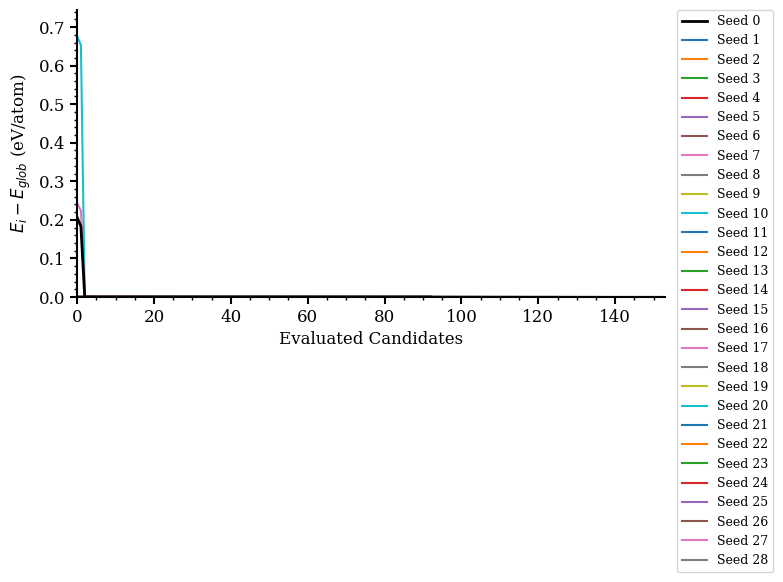

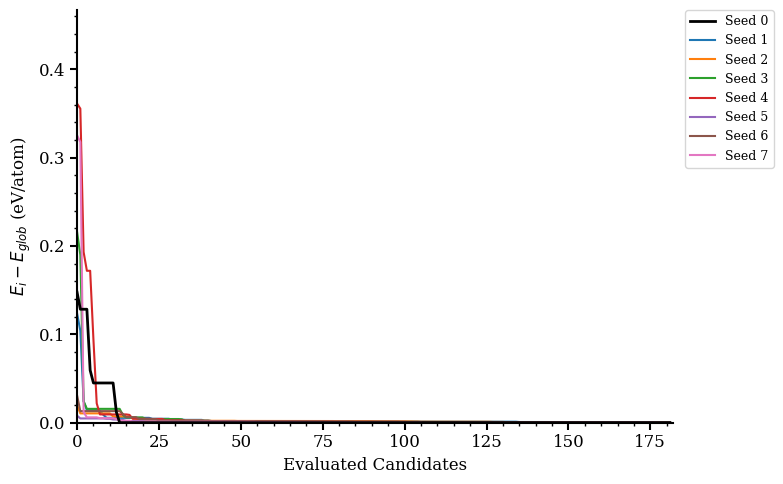

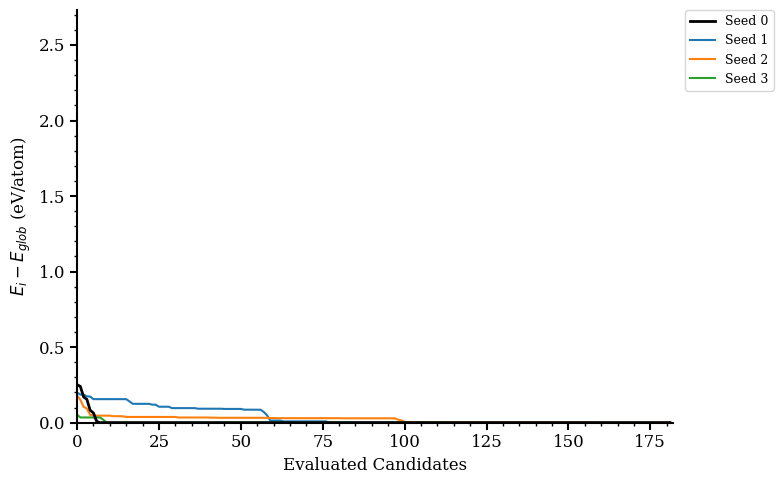

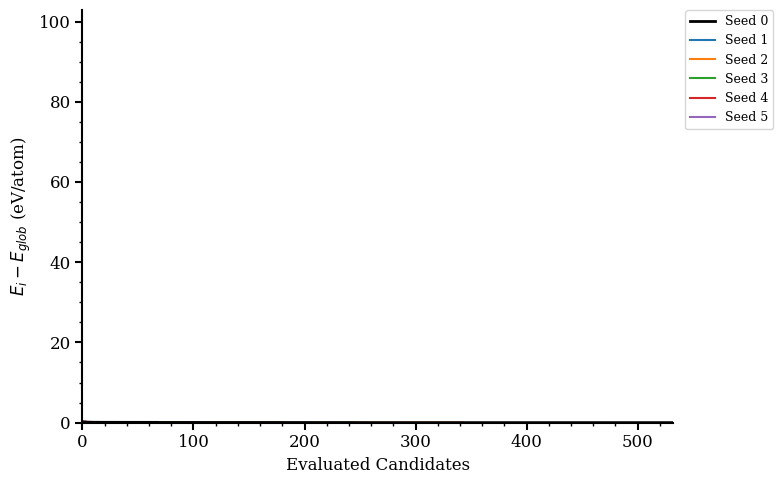

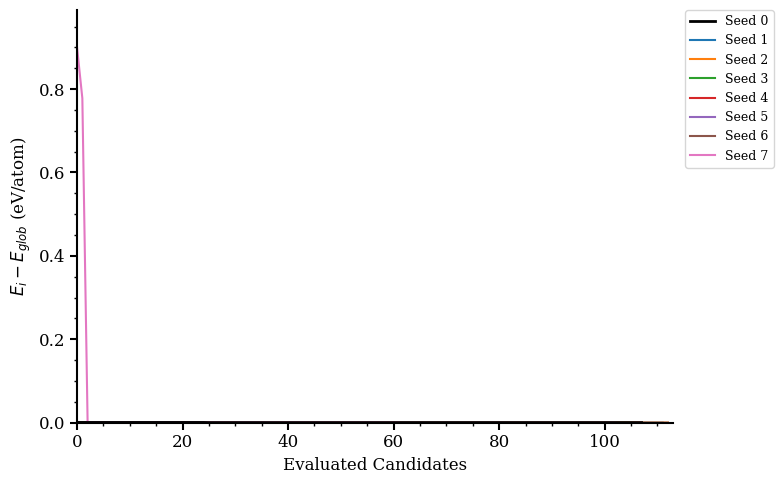

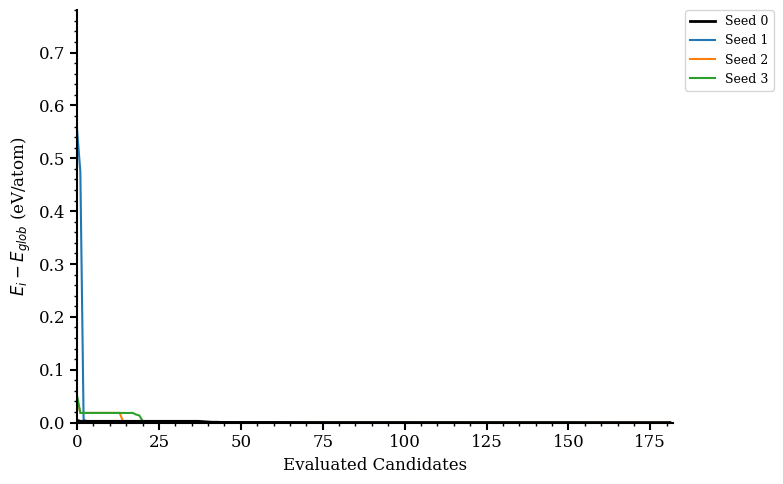

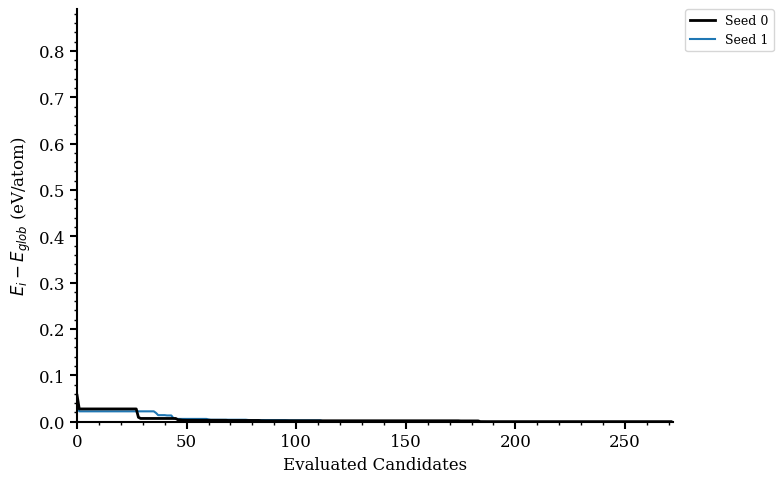

In [67]:
from scripts.process_database import process_database

# === Database Processing Execution ===
for dir_path, file_idx in db_paths:
    process_database(
        # Input and Output Paths
        dir_path=dir_path,
        file_idx=file_idx,
        dir_out=dir_out,
        dir_xsf_traj=dir_xsf_traj,
        dir_xsf=dir_xsf,
        individual_seeds_dir_name=file_idx,

        # Processing and Save Flags
        save_individual_trajectories=True,
        plot_best_so_far=True,
        plot_by_seed=True,

        # Plot Settings and Limits
        figsize=(8, 5),
        custom_max_x=None,
        custom_max_y=None,
        start_iter=10,  # Starts at iteration ten
    )

# Landscape Analysis and Evaluation Script
This script extracts normalized atomic energies and geometry profiles from a trajectory. It applies PCA to structural fingerprints and passes these components to the landscape visualization tool.

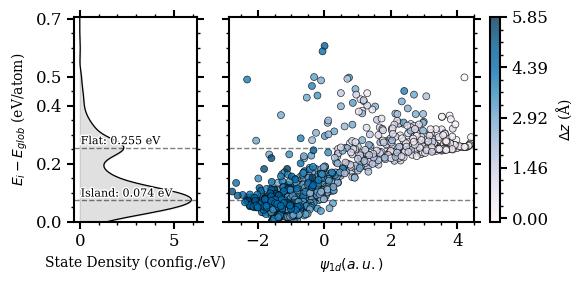

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from ase.io import read
from matplotlib import patheffects
from matplotlib.ticker import AutoMinorLocator
from scipy.stats import gaussian_kde

from agox.models.descriptors.fingerprint import Fingerprint

from scripts.plot_structure_landscape import plot_structure_landscape

# === Script Tuning Parameters ===
use_z_data = True
show_limits = True
animate_scatter = False
custom_peak_labels = ['Island', 'Flat']
z_atom_type = 'Fe'

# === Data Ingestion and Trajectory Extraction ===
structures = read(f"{dir_out}/{dir_xsf_traj}/traj_19.traj", index=':')

raw_energies = []
valid_structures = []
z_height_spans = []

for atoms in structures:
    try:
        e = atoms.get_potential_energy()
        raw_energies.append(e)
        valid_structures.append(atoms)

        if use_z_data:
            z_pos = atoms.get_positions()[:, 2]
            z_height_spans.append(z_pos.max() - z_pos.min())
    except Exception:
        continue

# === Properties Scaling and Normalization ===
num_atoms = len(valid_structures[0])
energies = (np.array(raw_energies) - min(raw_energies)) / num_atoms

if use_z_data:
    z_data = np.array(z_height_spans)
    z_data = z_data - min(z_data)  # Relative delta_z value
    show_cbar = True
    cbar_padding = 0.05
    colormap = 'PuBu'
else:
    z_data = None
    show_cbar = False
    cbar_padding = 0.02
    colormap = 'PuBu'

# === Dimensionality Reduction (PCA via Fingerprints) ===
fp_instance = Fingerprint.from_atoms(valid_structures[0])
data = np.array([fp_instance.create_features(s).flatten() for s in valid_structures])

X_centered = data - np.mean(data, axis=0)
cov_matrix = np.cov(X_centered, rowvar=False)
evals, evecs = np.linalg.eigh(cov_matrix)
idx = np.argsort(evals)[::-1]
X_eigen = X_centered @ evecs[:, idx[0]]

# === Figure Generation and Landscape Visualization ===
fig = plot_structure_landscape(
    # Core Data Inputs
    X_eigen,
    energies,
    z_data=z_data,

    # File and Save Settings
    save_path=f"{dir_out}/{dir_im}",
    animate_scatter=animate_scatter,

    # Plot Layout and Sizing
    figsize=(6, 3),
    wspace=0.1,
    fontsize=10,

    # Energy and Density View Constraints
    e_limit=(0.0, max(energies) + 0.1, 5),
    fill_density=True,
    dens_line_weight=0.9,
    show_limits=show_limits,
    custom_peak_labels=custom_peak_labels,

    # Colorbar and Colormap Styling
    cmap=colormap,
    show_colorbar=show_cbar,
    cbar_pad=cbar_padding,
    z_limit=(5.85, 0, 5),
    black_seed_zero=True,

    # Evaluation Flags
    plot_z_vs_e=False,
)
plt.show()

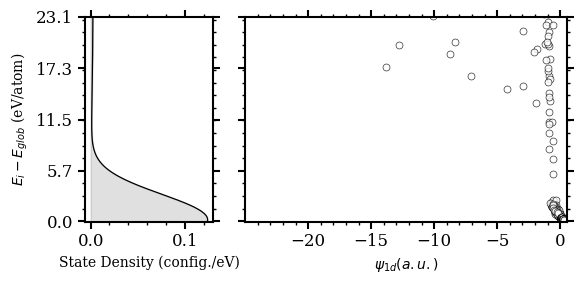

In [75]:
import numpy as np
import matplotlib.pyplot as plt
from ase.io import read
from matplotlib import patheffects
from matplotlib.ticker import AutoMinorLocator
from scipy.stats import gaussian_kde

from agox.models.descriptors.fingerprint import Fingerprint

from scripts.plot_structure_landscape import plot_structure_landscape

# === Script Tuning Parameters ===
use_z_data = False
show_limits = False
animate_scatter = False
# custom_peak_labels = ['Island', 'Flat']
costume_peak_labels = [None]
z_atom_type = 'Fe'

# === Data Ingestion and Trajectory Extraction ===
# structures = read(f"{dir_out}/{dir_xsf_traj}/traj_43.traj", index=':')
# structures = read(f"{dir_out}/{dir_xsf_traj}/traj_44.traj", index=':')
# structures = read(f"{dir_out}/{dir_xsf_traj}/traj_45.traj", index=':')
structures = read(f"{dir_out}/{dir_xsf_traj}/traj_61.traj", index=':')

raw_energies = []
valid_structures = []
z_height_spans = []

for atoms in structures:
    try:
        e = atoms.get_potential_energy()
        raw_energies.append(e)
        valid_structures.append(atoms)

        if use_z_data:
            z_pos = atoms.get_positions()[:, 2]
            z_height_spans.append(z_pos.max() - z_pos.min())
    except Exception:
        continue

# === Properties Scaling and Normalization ===
num_atoms = len(valid_structures[0])
energies = (np.array(raw_energies) - min(raw_energies)) / num_atoms

if use_z_data:
    z_data = np.array(z_height_spans)
    z_data = z_data - min(z_data)  # Relative delta_z value
    show_cbar = True
    cbar_padding = 0.05
    colormap = 'PuBu'
else:
    z_data = None
    show_cbar = False
    cbar_padding = 0.02
    colormap = 'PuBu'

# === Dimensionality Reduction (PCA via Fingerprints) ===
fp_instance = Fingerprint.from_atoms(valid_structures[0])
data = np.array([fp_instance.create_features(s).flatten() for s in valid_structures])

X_centered = data - np.mean(data, axis=0)
cov_matrix = np.cov(X_centered, rowvar=False)
evals, evecs = np.linalg.eigh(cov_matrix)
idx = np.argsort(evals)[::-1]
X_eigen = X_centered @ evecs[:, idx[0]]

# === Figure Generation and Landscape Visualization ===
fig = plot_structure_landscape(
    # Core Data Inputs
    X_eigen,
    energies,
    z_data=z_data,

    # File and Save Settings
    save_path=f"{dir_out}/{dir_im}",
    animate_scatter=animate_scatter,

    # Plot Layout and Sizing
    figsize=(6, 3),
    wspace=0.1,
    fontsize=10,

    # Energy and Density View Constraints
    e_limit=(0.0-0.05, 23 + 0.1, 5), #e_limit=(0.0, max(energies) + 0.1, 5),
    fill_density=True,
    dens_line_weight=0.9,
    show_limits=show_limits,
    custom_peak_labels=custom_peak_labels,

    # Colorbar and Colormap Styling
    cmap=colormap,
    show_colorbar=show_cbar,
    cbar_pad=cbar_padding,
    z_limit=(5.85, 0, 5),
    black_seed_zero=True,

    # Evaluation Flags
    plot_z_vs_e=False,
)
plt.show()

# Cumulative Dataset Parser and Plotter
This script aggregates energy data from multiple seed trajectories into an expanding cumulative pool. It normalizes values against a global minimum and plots the evolving density profiles.

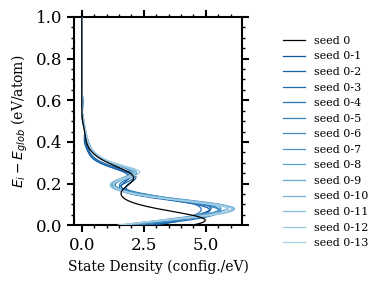

In [39]:
import glob
import os
import re
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np
from ase.io import read

from scripts.plot_structure_landscape import plot_structure_landscape

# === Path Configuration ===
seeds_dir = os.path.join(dir_out, dir_xsf_traj, '19')
traj_files = glob.glob(os.path.join(seeds_dir, '*.traj'))

# === Step 1: Group Raw Energies by Unique Seed ID ===
seed_groups = defaultdict(list)
num_atoms = None

for file_path in traj_files:
    file_name = os.path.basename(file_path)
    match = re.search(r'seed_(\d+)', file_name)
    
    if not match:
        print(f"Skipping file with unrecognized name pattern: {file_name}")
        continue
        
    seed_num = int(match.group(1))

    try:
        structures = read(file_path, index=':')
    except Exception as e:
        print(f"Failed to read file {file_name}: {e}")
        continue

    # Extract stable trajectory potential energies into the matching seed bucket
    for atoms in structures:
        try:
            e = atoms.get_potential_energy()
            if num_atoms is None:
                num_atoms = len(atoms)  # Capture atom count from the first valid structure
            seed_groups[seed_num].append(e)
        except Exception: 
            continue 

# === Step 2: Cumulative Energy Normalization & Aggregation ===
energy_landscape_dict = {}
cumulative_raw_energies = []
processed_seeds = []

# Process keys sequentially (e.g., 0, 1, 2...)
sorted_unique_seeds = sorted(seed_groups.keys())

for seed_num in sorted_unique_seeds:
    seed_energies = seed_groups[seed_num]
    if not seed_energies:
        continue
        
    processed_seeds.append(str(seed_num))
    cumulative_raw_energies.extend(seed_energies)

    # Shift energy against the global relative minimum of the accumulated pool
    cumulative_arr = np.array(cumulative_raw_energies)
    normalized_energies = (cumulative_arr - np.min(cumulative_arr)) / num_atoms

    # Format interval string range labels (e.g., "seed 0", "seed 0-1", "seed 0-2")
    start_seed = processed_seeds[0]
    current_seed = processed_seeds[-1]
    dict_key = f"seed {start_seed}" if len(processed_seeds) == 1 else f"seed {start_seed}-{current_seed}"

    energy_landscape_dict[dict_key] = normalized_energies

# === Logging Terminal Summary ===
# print("\nExtraction finished! Cumulative map keys:")
# for key, entries in energy_landscape_dict.items():
#     print(f"-> Key: '{key}' (Contains {len(entries)} total entries)")

# === Plot Generation and Export ===
fig = plot_structure_landscape(
    # Core Data Inputs
    X_eigen=None, 
    energies=energy_landscape_dict, 

    # Plot Layout and Sizing
    figsize=(5, 3),
    plot_density_only=True,

    # Energy View Constraints
    e_limit=(0.0, 1.0, 6),
    dens_line_weight=0.9,
    show_limits=False,

    # Styling Flags
    black_seed_zero=True,
    seed_zero_top_zorder=True
)

plt.savefig('state_denst.png', dpi=300, bbox_inches='tight')
plt.show()

# Multi-Trajectory Density Plotter
This script extracts and normalizes potential energies from a series of individual trajectory files. It maps each dataset to its corresponding custom legend label and passes the aggregated dictionary to the landscape tool for density profiling.

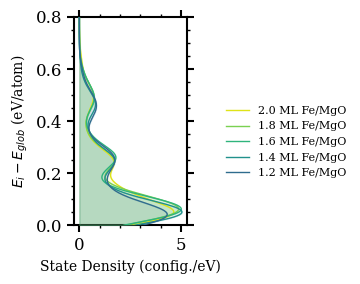

In [43]:
import os
import matplotlib.pyplot as plt
import numpy as np
from ase.io import read

# === Path and File Setup ===
dir_path = f"{dir_out}/{dir_xsf_traj}"
traj_files = ["traj_22.traj", "traj_23.traj", "traj_24.traj", "traj_25.traj", "traj_26.traj"]
# legend_labels = ["0% MgO latt.", "25% MgO latt.", "50% MgO latt.", "75% MgO latt."]
legend_labels = [
    '2.0 ML Fe/MgO',  # 27_fe_con0 (Baseline)
    '1.8 ML Fe/MgO',  # 28_fe_con5 (-5 atoms)
    '1.6 ML Fe/MgO',  # 29_fe_con10 (-10 atoms)
    '1.4 ML Fe/MgO',  # 30_fe_con15 (-15 atoms)
    '1.2 ML Fe/MgO',  # 31_fe_con20 (-20 atoms)
    '1.0 ML Fe/MgO',  # 31_fe_con20 (-20 atoms)
]

# === Dictionary Energy Creation Framework ===
energy_landscape_dict = {}
num_atoms = None

for i, filename in enumerate(traj_files):
    try:
        full_path = os.path.join(dir_path, filename)
        structures = read(full_path, index=':')
        
        raw_energies = []
        for atoms in structures:
            try:
                raw_energies.append(atoms.get_potential_energy())
                if num_atoms is None:
                    num_atoms = len(atoms)
            except Exception:
                continue
                
        if not raw_energies:
            continue
            
        # Normalize and store entries matching the target labels
        energies = (np.array(raw_energies) - min(raw_energies)) / num_atoms
        dict_key = legend_labels[i] if i < len(legend_labels) else filename.replace('.traj', '')
        energy_landscape_dict[dict_key] = energies

    except Exception as e:
        print(f"Error processing {filename}: {e}")

# === Landscape Visualization Generation ===
fig = plot_structure_landscape(
    # Core Data Inputs
    X_eigen=None,
    energies=energy_landscape_dict,

    # Plot Layout and Sizing
    figsize=(4, 3),
    plot_density_only=True,

    # Energy View Constraints
    e_limit=(0.0, 0.8, 5),
    dens_line_weight=1.0,
    fill_density=True,
    density_alpha=0.1,
    show_limits=False,

    # Styling Flags
    density_cmap='viridis'
)

plt.show()

# XRD

In [77]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from ase.io import read 
from pymatgen.io.ase import AseAtomsAdaptor
from pymatgen.analysis.diffraction.xrd import XRDCalculator
from scipy.stats import norm

# ==============================================================================
# CONFIGURATION PARAMETERS
# ==============================================================================
# Define the specific representative energy points you want to pick out
target_energies = [0.0, 0.01, 0.05]
tolerance = 0.002  # Maximum allowed delta distance to capture a target match

dir_out = '0_analy'               # Directory for the analysis
dir_xsf_traj = '0_xsf_traj'       # Stores entire trajectory
trajectory_file = f"{dir_out}/{dir_xsf_traj}/traj_61.traj"

# Peak Broadening Parameters for the continuous profile representation
two_theta_grid = np.linspace(30, 50, 1000)
fwhm = 0.40  # Slightly broadened peak width for clarity
sigma = fwhm / (2 * np.sqrt(2 * np.log(2)))

# Initialize Pymatgen XRD calculator (Standard Cu K-alpha radiation)
xrd_calc = XRDCalculator(wavelength="CuKa")
adaptor = AseAtomsAdaptor()

# ==============================================================================
# 1. DATA INGESTION & ENERGY EVALUATION
# ==============================================================================
print(f"Reading structures from: {trajectory_file}")
all_structures = read(trajectory_file, index=":")

energies_per_atom = []
for atoms in all_structures:
    num_atoms = len(atoms)
    try:
        total_energy = atoms.get_potential_energy()
    except RuntimeError:
        total_energy = atoms.info.get('energy', None)
        if total_energy is None:
            raise RuntimeError("Atoms object has no potential energy calculated or stored.")
    energies_per_atom.append(total_energy / num_atoms)

energies_per_atom = np.array(energies_per_atom)
min_energy_per_atom = np.min(energies_per_atom)
relative_energies_per_atom = energies_per_atom - min_energy_per_atom

# ==============================================================================
# 2. TARGETED ONE-STRUCTURE SELECTION
# ==============================================================================
datasets = []

for target in target_energies:
    # Find the structure that sits closest to the exact target energy
    abs_diffs = np.abs(relative_energies_per_atom - target)
    best_match_idx = np.argmin(abs_diffs)
    
    if abs_diffs[best_match_idx] <= tolerance:
        dE_atom = relative_energies_per_atom[best_match_idx]
        matched_atoms = all_structures[best_match_idx]
        
        syms = matched_atoms.get_chemical_symbols()
        ta_count = syms.count('Ta')
        b_count = syms.count('B')
        
        label = f"Target {target} eV/atom (Struct {best_match_idx}: [Ta{ta_count}B{b_count}] @ {dE_atom:.4f} eV/atom)"
        datasets.append({"atoms": matched_atoms, "label": label, "dE_atom": dE_atom})
    else:
        print(f"Warning: No structure found within tolerance window for target energy {target} eV/atom")

# Sort them so they layer naturally in the plot window (lowest energy at the back)
datasets = sorted(datasets, key=lambda x: x["dE_atom"])

# ==============================================================================
# 3. RUN PYMATGEN XRD & GENERATE DISCRETE HIGH-CONTRAST PLOT
# ==============================================================================
fig, ax = plt.subplots(figsize=(10.5, 5.5))

# --- MAXIMUM CONTRAST HEX COLORS ---
# Hardcoded to match targets sequentially: Black (0.0), Teal (0.01), Crimson Red (0.05)
high_contrast_colors = ["#000000", "#00a896", "#e63946"] 

for rank, data in enumerate(datasets):
    atoms = data["atoms"]
    
    # Convert to Pymatgen Structure object
    pmg_structure = adaptor.get_structure(atoms)
    
    # scaled=False turns off normalization to 100
    pattern = xrd_calc.get_pattern(pmg_structure, scaled=False, two_theta_range=(30, 50))
    
    # Generate continuous 2-theta profile using the calculated intensities
    simulated_intensity = np.zeros_like(two_theta_grid)
    for peak_angle, intensity in zip(pattern.x, pattern.y):
        simulated_intensity += intensity * norm.pdf(two_theta_grid, peak_angle, sigma)
    
    # Assign distinct visual weights and colors to each trace
    line_color = high_contrast_colors[rank % len(high_contrast_colors)]
    line_width = 2.2 if line_color == "#000000" else 1.8
    
    ax.plot(
        two_theta_grid, 
        simulated_intensity, 
        color=line_color, 
        lw=line_width, 
        label=data["label"],
        alpha=0.95
    )

# ==============================================================================
# 4. GRAPH LAYOUT & LEGEND MANAGEMENT
# ==============================================================================
ax.set_xlabel(r"$2\theta$ (degree)", fontsize=11)
ax.set_ylabel("Absolute Structural Intensity (a.u.)", fontsize=11)
ax.set_title("Pymatgen Crystal XRD: High-Contrast Energy Profile Comparison", fontsize=12, pad=15)
ax.set_xlim(30, 50)

# Clean legend for direct, effortless curve identification
ax.legend(loc="upper right", frameon=True, fontsize=9.5, facecolor="white", edgecolor="none")

output_img = "pymatgen_high_contrast_discrete_xrd.png"
plt.tight_layout()
plt.savefig(output_img, dpi=300)
print(f"\nSuccess! Plotted {len(datasets)} highly distinguishable target structures. Saved to '{output_img}'")
plt.show()

ModuleNotFoundError: No module named 'pymatgen'

# Island height

3x3 min(raw_energies)/num_atoms=-5.708614488588409
4x4 min(raw_energies)/num_atoms=-5.762537872423099
5x5 min(raw_energies)/num_atoms=-5.825457725689693

3x3 eV/atom: 116.84 meV/atom
4x4 eV/atom: 62.91 meV/atom
5x5 eV/atom: 0

min(raw_energies)/num_atoms=-5.762537872423099


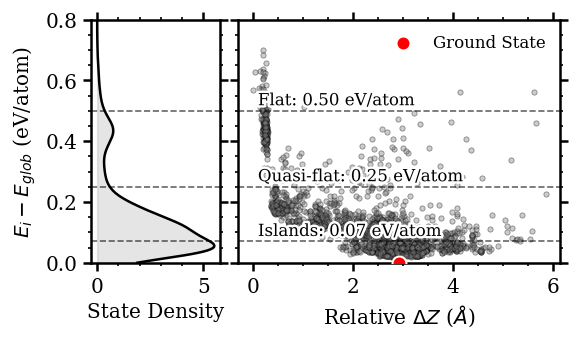

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from matplotlib import patheffects  # Required for the white outline
from ase.io import read
from scipy.stats import gaussian_kde

# --- Data Preparation ---
structures = read(f"{dir_out}/{dir_xsf_traj}/traj_20.traj", index=':')
raw_energies, z_height_spans = [], []

for atoms in structures:
    try:
        raw_energies.append(atoms.get_potential_energy())
        z_pos = atoms.get_positions()[:, 2]
        z_height_spans.append(z_pos.max() - z_pos.min())
    except Exception:
        continue

num_atoms = len(structures[0])
energies = (np.array(raw_energies) - min(raw_energies))/num_atoms
print(f"{min(raw_energies)/num_atoms=}")
z_data = np.array(z_height_spans)
z_data = z_data - min(z_data)

# --- Structural Limits (Horizontal on this graph) ---
limits = {
    "Islands": 0.07,
    "Quasi-flat": 0.25,
    "Flat": 0.50
}

# --- KDE Calculation ---
min_e, max_e = 0.0, 0.8
energy_grid = np.linspace(min_e, max_e, 200)
kde = gaussian_kde(energies)
density = kde.evaluate(energy_grid)

# --- Plotting ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(5, 3), sharey=True, 
                               gridspec_kw={'width_ratios': [1, 2.5]}, dpi=120)

# Subplot 1: State Density (Standard Weights)
ax1.plot(density, energy_grid, color='black', lw=1.5, zorder=4)
ax1.fill_betweenx(energy_grid, 0, density, color='gray', alpha=0.2)
ax1.set_xlabel('State Density', fontsize=12)
ax1.set_ylabel(r'$E_i - E_{glob}$ (eV/atom)', fontsize=12)

# Subplot 2: Delta Z Scatter
ax2.scatter(z_data, energies, s=10, facecolors='grey', edgecolors='black', 
            linewidth=0.5, alpha=0.4, zorder=2)

# Global Minimum Highlight
glob_idx = np.argmin(energies)
ax2.scatter(z_data[glob_idx], energies[glob_idx], s=70, facecolors='red', 
            edgecolors='white', linewidth=1.2, zorder=5, label='Ground State')

# list_of_indices = np.argsort(energies)[-1]
# ax2.scatter(z_data[list_of_indices], energies[list_of_indices], s=70, facecolors='blue', 
#             edgecolors='white', linewidth=1.2, zorder=5, label='Other')

# --- Add Structural Limit Lines and Outlined Labels ---
for label, val in limits.items():
    # Horizontal lines across both plots
    ax1.axhline(y=val, color='black', linestyle='--', linewidth=1, alpha=0.6, zorder=10)
    ax2.axhline(y=val, color='black', linestyle='--', linewidth=1, alpha=0.6, zorder=10)
    
    # Create the horizontal text label (No bold fontweight)
    t = ax2.text(0.1, val + 0.005, f'{label}: {val:.2f} eV/atom', 
                fontsize=10, color='black', 
                verticalalignment='bottom', zorder=11)
    
    # Apply the white outline effect for readability
    t.set_path_effects([
        patheffects.withStroke(linewidth=3, foreground='white')
    ])

# Final Styling
ax2.set_xlabel(r'Relative $\Delta Z$ ($\AA$)', fontsize=12)
ax2.set_ylim(min_e, max_e)

# Standard tick styling (No bold)
for ax in [ax1, ax2]:
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())

ax2.legend(frameon=False, loc='upper right', fontsize=10)

plt.tight_layout()
plt.subplots_adjust(wspace=0.08)
plt.show()

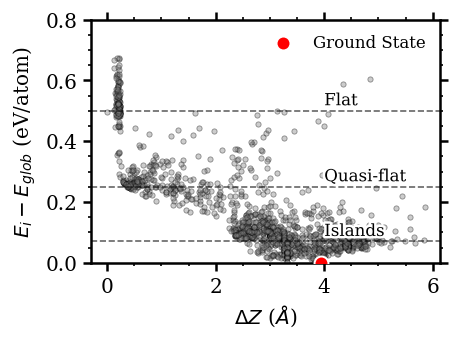

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from matplotlib import patheffects
from ase.io import read
from scipy.stats import gaussian_kde

# --- Configuration ---
plot_only_delta_z = True  # Set to False to see the State Density (KDE) plot as well

# --- Data Preparation ---
structures = read(f"{dir_out}/{dir_xsf_traj}/traj_19.traj", index=':')
raw_energies, z_height_spans = [], []

for atoms in structures:
    try:
        raw_energies.append(atoms.get_potential_energy())
        z_pos = atoms.get_positions()[:, 2]
        z_height_spans.append(z_pos.max() - z_pos.min())
    except Exception:
        continue

num_atoms = len(structures[0])
energies = (np.array(raw_energies) - min(raw_energies))/num_atoms
z_data = np.array(z_height_spans)
z_data = z_data - min(z_data)

# --- Structural Limits ---
limits = {
    "Islands": 0.07,
    "Quasi-flat": 0.25,
    "Flat": 0.50
}

min_e, max_e = 0.0, 0.8

# --- Plotting Logic ---
if plot_only_delta_z:
    fig, ax2 = plt.subplots(figsize=(4, 3), dpi=120)
    axes = [ax2]
else:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(5, 3), sharey=True, 
                                   gridspec_kw={'width_ratios': [1, 2.5]}, dpi=120)
    axes = [ax1, ax2]
    
    # KDE Calculation & Plotting
    energy_grid = np.linspace(min_e, max_e, 200)
    kde = gaussian_kde(energies)
    density = kde.evaluate(energy_grid)
    
    ax1.plot(density, energy_grid, color='black', lw=1.5, zorder=4)
    ax1.fill_betweenx(energy_grid, 0, density, color='gray', alpha=0.2)
    ax1.set_xlabel('State Density', fontsize=12)
    ax1.set_ylabel(r'$E_i - E_{glob}$ (eV/atom)', fontsize=12)

# --- Delta Z Scatter (Common to both modes) ---
ax2.scatter(z_data, energies, s=10, facecolors='grey', edgecolors='black', 
            linewidth=0.5, alpha=0.4, zorder=2)

# Global Minimum Highlight
glob_idx = np.argmin(energies)
ax2.scatter(z_data[glob_idx], energies[glob_idx], s=70, facecolors='red', 
            edgecolors='white', linewidth=1.2, zorder=5, label='Ground State')

# --- Add Structural Limit Lines and Outlined Labels ---
for label, val in limits.items():
    for ax in axes:
        ax.axhline(y=val, color='black', linestyle='--', linewidth=1, alpha=0.6, zorder=10)
    
    t = ax2.text(4, val + 0.005, f'{label}', 
                fontsize=10, color='black', 
                verticalalignment='bottom', zorder=11)
    t.set_path_effects([patheffects.withStroke(linewidth=3, foreground='white')])

# Final Styling
ax2.set_xlabel(r'$\Delta Z$ ($\AA$)', fontsize=12)
if plot_only_delta_z:
    ax2.set_ylabel(r'$E_i - E_{glob}$ (eV/atom)', fontsize=12)

ax2.set_ylim(min_e, max_e)
ax2.legend(frameon=False, loc='upper right', fontsize=10)

for ax in axes:
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())

plt.tight_layout()
if not plot_only_delta_z:
    plt.subplots_adjust(wspace=0.08)
    
plt.show()

## Find ref for dos

In [3]:
from scripts.build_mgo_stack import build_mgo_stack
from scripts.build_fe_stack import build_fe_stack
from scripts.build_heteroStruct import build_heteroStruct

from ase.build import surface, bulk
from ase.io import read, write

supercell = (5, 5, 1)
a_mgo = 4.212            
vacuum = 20           

mgo_layer_number = 1
fe_layer_number = 1

path_xsf = f"."


bulk_mgo = bulk('MgO', 'rocksalt', a=a_mgo, cubic=True)
slab_mgo = surface(bulk_mgo, (0, 0, 1), layers=1, vacuum=vacuum)
slab_fe_base = surface('Fe', (0, 0, 1), layers=1, vacuum=vacuum)

slab_mgofe = build_mgo_stack(slab_fe_base, num_layers=mgo_layer_number, vacuum=vacuum, output_path=f"{path_xsf}/slab_mgofe.xsf")
slab_mgo = slab_mgofe[[atom.symbol != 'Fe' for atom in slab_mgofe]].repeat(supercell)
slab_fe = build_fe_stack(slab_fe_base, num_layers=fe_layer_number, vacuum=vacuum, output_path=f"{path_xsf}/slab_fe.xsf").repeat(supercell)

slab_substrate = slab_mgo.copy()
slab_deposition = slab_fe.copy()
slab_heteroStruct, slab_substrate, slab_deposition, substrate_layer_heights, deposition_layer_heights = build_heteroStruct(slab_substrate, slab_deposition, output_path=f'{path_xsf}/heteroStruct.xsf')

write(f'{path_xsf}/hetero.xsf',slab_heteroStruct)

In [5]:
import pandas as pd
import numpy as np
from ase.io import read

structures = read(f"{dir_out}/{dir_xsf_traj}/traj_19.traj", index=':')
raw_energies, z_height_spans = [], []

for atoms in structures:
    try:
        raw_energies.append(atoms.get_potential_energy())
        z_pos = atoms.get_positions()[:, 2]
        z_height_spans.append(z_pos.max() - z_pos.min())
    except Exception:
        continue
    
num_atoms = len(structures[0])
rel_energies = (np.array(raw_energies) - min(raw_energies)) / num_atoms
rel_z = np.array(z_height_spans) - min(z_height_spans)

df = pd.DataFrame({
    'traj_index': np.arange(len(rel_energies)),
    'energy_per_atom': rel_energies,
    'z_height_rel': rel_z
})

num_bins = 10
df['energy_range'] = pd.cut(df['energy_per_atom'], bins=num_bins)

best_structures = df.sort_values('z_height_rel').groupby('energy_range', observed=True).first().reset_index()

output_file = "lowest_height_per_energy.csv"
best_structures.to_csv(output_file, index=False)

print("done")

done


In [9]:
from ase.io import read, write, Trajectory
import numpy as np

custom_struct = read('hetero.xsf')
structures = read(f"{dir_out}/{dir_xsf_traj}/traj_19.traj", index=':')

num_atoms = len(structures[0])
raw_energies = [atoms.get_potential_energy() for atoms in structures]
rel_energies = (np.array(raw_energies) - min(raw_energies)) / num_atoms

min_energy_idx = np.argmin(rel_energies)

target_indices = [919, 789, 1075, int(min_energy_idx)]
new_traj_list = []

for idx in target_indices:
    try:
        new_traj_list.append(structures[idx])
    except IndexError:
        print(f"Warning: Index {idx} out of range for the loaded trajectory.")

new_traj_list.append(custom_struct)
output_traj_path = "selected_structures_dos.traj"
write(output_traj_path, new_traj_list)

## Find density peak

In [5]:
from scipy.signal import find_peaks

peaks, properties = find_peaks(density)

peak_densities = density[peaks]
peak_energies = energy_grid[peaks]

sorted_indices = np.argsort(peak_densities)[::-1]
top_3_indices = sorted_indices[:3]

print("--- Top 3 Energy Peaks (Highest State Density) ---")
for i, idx in enumerate(top_3_indices):
    e_val = peak_energies[idx]
    d_val = peak_densities[idx]
    print(f"Rank {i+1}: Energy = {e_val:.4f} eV/atom (Density = {d_val:.2f})")
    
    ax1.hlines(e_val, 0, d_val, colors='red', linestyles='--', alpha=0.5)

--- Top 3 Energy Peaks (Highest State Density) ---
Rank 1: Energy = 0.0764 eV/atom (Density = 4.72)
Rank 2: Energy = 0.2533 eV/atom (Density = 1.79)
Rank 3: Energy = 0.5106 eV/atom (Density = 0.70)


## Height density

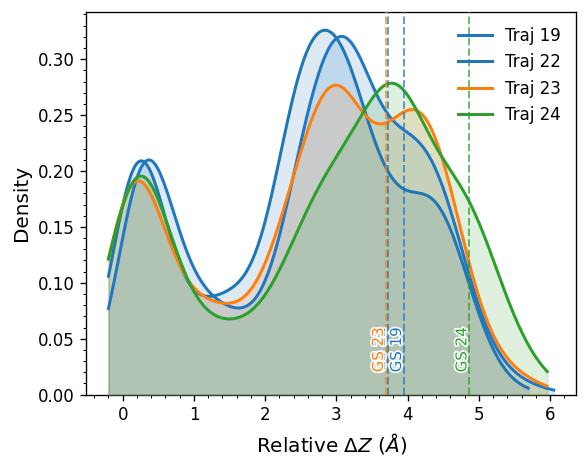

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from matplotlib import patheffects
from scipy.stats import gaussian_kde
from ase.io import read

# --- Configuration ---
traj_ids = [19, 22, 23, 24]  
colors = ['#1f77c5', '#1f77b4', '#ff7f0e', '#2ca02c']  
# dir_out and dir_xsf_traj should be defined in your environment

fig, ax = plt.subplots(figsize=(5, 4), dpi=120)

# To store data for global limit calculation
all_z_data = []

for i, t_id in enumerate(traj_ids):
    # --- Data Extraction ---
    try:
        structures = read(f"{dir_out}/{dir_xsf_traj}/traj_{t_id}.traj", index=':')
    except Exception as e:
        print(f"Could not read traj_{t_id}: {e}")
        continue

    raw_energies, z_height_spans = [], []
    for atoms in structures:
        try:
            raw_energies.append(atoms.get_potential_energy())
            z_pos = atoms.get_positions()[:, 2]
            z_height_spans.append(z_pos.max() - z_pos.min())
        except: continue

    num_atoms = len(structures[0])
    energies = (np.array(raw_energies) - min(raw_energies)) / num_atoms
    z_data = np.array(z_height_spans)
    z_data = z_data - min(z_data)

    # --- KDE Calculation ---
    # Create a smooth grid for plotting
    z_grid = np.linspace(z_data.min() - 0.2, z_data.max() + 0.2, 300)
    kde = gaussian_kde(z_data)
    density = kde.evaluate(z_grid)

    # --- Plotting the KDE ---
    ax.plot(z_grid, density, color=colors[i], lw=1.8, label=f'Traj {t_id}', zorder=4)
    ax.fill_between(z_grid, 0, density, color=colors[i], alpha=0.15, zorder=3)

    # --- Ground State Marker ---
    glob_idx = np.argmin(energies)
    gs_z = z_data[glob_idx]
    
    # Vertical line for GS
    ax.axvline(gs_z, color=colors[i], linestyle='--', lw=1.2, alpha=0.7, zorder=5)
    
    # Outlined Ground State Label
    # y_pos is staggered slightly for each trajectory
    y_pos = ax.get_ylim()[1] if i == 0 else plt.gca().get_ylim()[1] 
    # Update y_pos logic to use current max height
    t = ax.text(gs_z, 0.02, f'GS {t_id}', color=colors[i], fontsize=9, 
                rotation=90, ha='right', va='bottom', zorder=10)
    t.set_path_effects([patheffects.withStroke(linewidth=2, foreground='white')])

# --- Final Styling ---
ax.set_xlabel(r'Relative $\Delta Z$ ($\AA$)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)

# Ensure Y-axis starts at 0
ax.set_ylim(0, None)

ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())

ax.legend(frameon=False, loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

# Calc probability dist

In [285]:
# def calculate_boltzmann_probs(energies, kde_model, T):
#     """
#     Calc Pi = g_(E)exp(-A/kbT) / Z
#     """
#     kb = 8.6173e-5 # eV/K

#     rho_i = kde_model.evaluate(energies) + 1e-15

#     relative_e = energies - np.min(energies)
#     exponent = -relative_e / (kb * T)

#     weights = np.exp(exponent)
#     Z = np.sum(weights)

#     return rho_i * weights / Z

def calculate_boltzmann_probs(energies, kde_model, T):
    """
    Calculates normalized Pi = [rho(E) * exp(-dE/kbT)] / Z
    """
    kb = 8.6173e-5 # eV/K

    # Adding epsilon to avoid zero
    rho_i = kde_model.evaluate(energies) + 1e-15

    # 2. Calculate Boltzmann Weights
    relative_e = energies - np.min(energies)
    exponent = -relative_e / (kb * T)
    weights = np.exp(exponent)

    # 3. Calculate Partition Function Z 
    # Z must be the sum of (Density * Weights)
    numerator = rho_i * weights
    Z = np.sum(numerator)

    # 4. Return Normalized Probabilities
    return numerator / Z

/tmp/ipykernel_190761/4008912441.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors_plasma = cm.get_cmap('plasma')(np.linspace(0, 0.85, len(temps)))


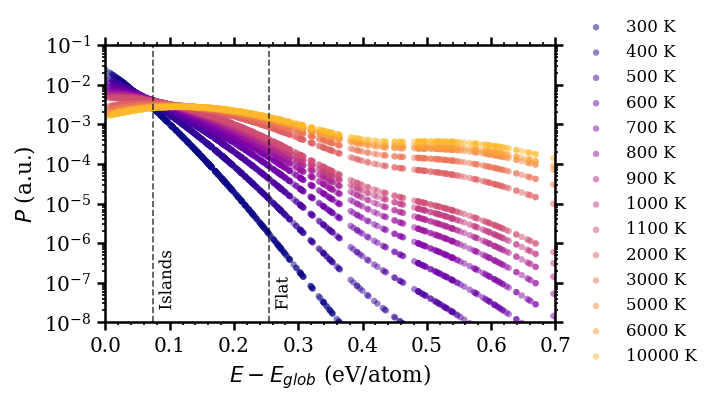

In [348]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LogLocator, LogFormatterExponent
from matplotlib import patheffects # Required for the outline
from ase.io import read
from scipy.stats import gaussian_kde

# --- Constants & Setup ---
kb = 8.6173e-5 # eV/K
temps = [300, 400, 500, 600, 700, 800, 900, 1000, 1100, 2000, 3000, 5000, 6000, 10000]
colors_plasma = cm.get_cmap('plasma')(np.linspace(0, 0.85, len(temps)))

# Load and normalize energies
# structures = read(f"{dir_out}/{dir_xsf_traj}/traj_19.traj", index=':')
structures = read(f"{dir_out}/{dir_xsf_traj}/traj_47.traj", index=':')
# structures = read(f"{dir_out}/{dir_xsf_traj}/traj_39.traj", index=':')
raw_energies = [atoms.get_potential_energy() for atoms in structures]
num_atoms = len(structures[0])

# Defining U = E_i - E_glob (normalized per atom)
energies = (np.array(raw_energies) - min(raw_energies)) / num_atoms
kde = gaussian_kde(energies)

# --- Define Structural Limits ---
limits = {
    "Islands": 0.074,
    "Flat": 0.255
}

# limits = {
#     "Disordered": 1.447,
#     "Flat": 0.093
# }

# --- Plotting ---
fig, ax = plt.subplots(figsize=(6, 3), dpi=120)

# 1. Plot Boltzmann Probabilities for each Temp
for T, color in zip(temps, colors_plasma):
    probs = calculate_boltzmann_probs(energies, kde, T)
    
    peak_idx = np.argmax(probs)
    peak_energy = energies[peak_idx]
    
    note_label = f'{T} K'
    ax.scatter(energies, probs, color=color, s=15, alpha=0.5, 
               edgecolors='none', label=note_label)

# 2. Add Structural Limit Vertical Lines (Black) with Outlined Text
y_text_pos = 2e-8 

for label, val in limits.items():
    ax.axvline(x=val, color='black', linestyle='--', linewidth=1, alpha=0.7, zorder=10)
    
    # Create the text object
    t = ax.text(val + 0.008, y_text_pos, f'{label}', 
                rotation=90, verticalalignment='bottom', fontsize=10, 
                color='black', zorder=11)
    
    # Apply the white outline (path effect)
    t.set_path_effects([
        patheffects.withStroke(linewidth=3, foreground='white')
    ])

# --- Final Styling ---
ax.set_xlabel(r'$E - E_{glob}$ (eV/atom)', fontsize=13)
ax.set_ylabel(r'$P$ (a.u.)', fontsize=13)
ax.set_yscale('log')

ax.set_xlim(0.0, 0.7) # ax.set_xlim(0.0-0.1, 1.8) # ax.set_xlim(0.0, 0.5)
ax.set_ylim(1e-8, 1e-1)
ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=10))
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=10))

ax.xaxis.set_minor_locator(AutoMinorLocator())

# --- Legend Outside ---
ax.legend(frameon=False, 
          fontsize=10, 
          loc='upper left', 
          bbox_to_anchor=(1.02, 1.15))

plt.subplots_adjust(right=0.75) 
plt.savefig('boltzmann_probabilities.png', dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_190761/3962416484.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors_plasma = cm.get_cmap('plasma')(np.linspace(0, 0.85, len(temps)))
/tmp/ipykernel_190761/3962416484.py:69: UserWarning: Legend does not support handles for Text instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1), frameon=False, fontsize=8)


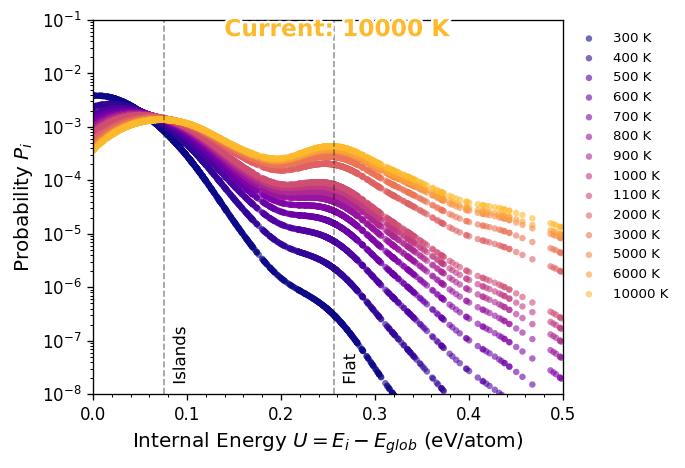

Stacking animation saved to: 0_analy/temp_stacking_evolution.gif


In [79]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import AutoMinorLocator
from matplotlib import patheffects
from matplotlib.animation import FuncAnimation, PillowWriter
from ase.io import read
from scipy.stats import gaussian_kde

# --- Data Preparation ---
structures = read(f"{dir_out}/{dir_xsf_traj}/traj_19.traj", index=':')
raw_energies = [atoms.get_potential_energy() for atoms in structures]
num_atoms = len(structures[0])
energies = (np.array(raw_energies) - min(raw_energies)) / num_atoms
kde = gaussian_kde(energies)

temps = [300, 400, 500, 600, 700, 800, 900, 1000, 1100, 2000, 3000, 5000, 6000, 10000]
colors_plasma = cm.get_cmap('plasma')(np.linspace(0, 0.85, len(temps)))

limits = {"Islands": 0.075, "Flat": 0.256}

# --- Setup Figure for Animation ---
# Increased bottom margin via subplots_adjust later to prevent cutting
fig, ax = plt.subplots(figsize=(5, 4), dpi=120)

def init():
    ax.clear()
    ax.set_xlabel(r'Internal Energy $U = E_i - E_{glob}$ (eV/atom)', fontsize=12)
    ax.set_ylabel(r'Probability $P_i$', fontsize=12)
    ax.set_yscale('log')
    ax.set_xlim(0.0, 0.5)
    ax.set_ylim(1e-8, 1e-1)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    
    # Static Structural Lines
    # Moved text pos slightly up to ensure it's within the axis box
    for label, val in limits.items():
        ax.axvline(x=val, color='black', linestyle='--', linewidth=1, alpha=0.4)
        t = ax.text(val + 0.008, 1.5e-8, label, rotation=90, va='bottom', fontsize=10)
        t.set_path_effects([patheffects.withStroke(linewidth=3, foreground='white')])
    
    plt.tight_layout()
    return []

def update(frame):
    # We NO LONGER remove ax.collections to allow stacking
    
    # Remove ONLY the previous large temperature header text
    for text in ax.texts:
        if "HEADER_TEMP" in text.get_label():
            text.remove()

    T = temps[frame]
    color = colors_plasma[frame]
    
    # Calculate probabilities
    probs = calculate_boltzmann_probs(energies, kde, T)
    
    # Add new scatter (stacking on top of old ones)
    ax.scatter(energies, probs, color=color, s=15, alpha=0.6, 
               edgecolors='none', label=f'{T} K')
    
    # Floating Header Temperature Label (Current frame indicator)
    temp_text = ax.text(0.38, 0.5e-1, f'Current: {T} K', fontsize=14, color=color, 
                        fontweight='bold', ha='right', label="HEADER_TEMP")
    temp_text.set_path_effects([patheffects.withStroke(linewidth=3, foreground='white')])
    
    # Optional: Update legend to show progress
    ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1), frameon=False, fontsize=8)
    
    return []

# --- Create and Save Animation ---
# Note: repeat=True will keep the gif looping
ani = FuncAnimation(fig, update, frames=len(temps), init_func=init, blit=False)

# Adjust plot to make room for labels and legend
plt.subplots_adjust(bottom=0.15, right=0.8)

# Save as GIF
writer = PillowWriter(fps=3) 
save_path = f"{dir_out}/temp_stacking_evolution.gif"
ani.save(save_path, writer=writer)

plt.show()
print(f"Stacking animation saved to: {save_path}")

# Visual struct

In [122]:
from typing import Optional, Sequence
import numpy as np
from numpy.typing import NDArray
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import AutoMinorLocator
from ase import Atoms
from ase.constraints import FixAtoms
from agox.utils.plot.colors import Colors
from agox.utils.plot import plot_atoms, plot_cell

def plot_structure(
    atoms: Atoms,
    plane: str = 'yz+',
    constraint_symbols: Optional[Sequence[str]] = None,
    height_darken_symbols: Optional[Sequence[str]] = None, # Kept for backward compatibility but unused
    figsize: tuple[int, int] = (10, 10),
    environment=None,
    save_path: Optional[str] = None,
    radius_factor: float = 0.8,
    repeat: int = 1,
    cell_offset: NDArray[np.floating] = np.array([0.0, 0.0, 0.0]),
    set_axis_off: bool = True,
    add_cell: bool = True,
    linewidths: float = 1.5,
    linewidths_environment: float = 1.0,
    plot_show: bool = True,
    darken_factor: float = 0.4,
    n_darken_layers: int = 2,
    show_colorbar: bool = False,
    cbar_label: str = r'$\Delta z$ ($\AA$)',
    max_cbar: float = 5.0,
    num_ticks: int = 3,
    fontsize: int = 10
) -> None:
    """
    Plot an ASE atomic structure where unconstrained cluster atoms get 
    progressively darker with height. If multiple unconstrained elements exist,
    multiple colorbars are rendered.
    """
    # Make a copy to avoid mutating the original object
    atoms_copy = atoms.copy()
    
    # Apply dynamic element-based constraints if specified
    if constraint_symbols:
        fixed_indices = [a.index for a in atoms_copy if a.symbol in constraint_symbols]
        atoms_copy.set_constraint(FixAtoms(indices=fixed_indices))

    # --- Base coloring framework -------------------------------------------
    atom_colors = Colors(atoms_copy)

    oxygen_indices = [a.index for a in atoms_copy if a.symbol == 'O']
    if oxygen_indices:
        atom_colors.set_color('red', indices=oxygen_indices)
        atom_colors.lighten(indices=oxygen_indices, factor=0.2)

    magnesium_indices = [a.index for a in atoms_copy if a.symbol == 'Mg']
    if magnesium_indices:
        atom_colors.set_color('orange', indices=magnesium_indices)

    iron_indices = [a.index for a in atoms_copy if a.symbol == 'Fe']
    if iron_indices:
        atom_colors.set_color('green', indices=iron_indices)

    # --- Identify Unconstrained Atoms and Elements -------------------------
    if constraint_symbols:
        free_indices = [a.index for a in atoms_copy if a.symbol not in constraint_symbols]
    else:
        free_indices = [a.index for a in atoms_copy]

    # Map standard element strings to colors
    element_color_map = {
        'Fe': 'green',
        'Mg': 'orange',
        'O': 'red'
    }

    unique_free_elements = []
    if free_indices:
        free_z = np.array([atoms_copy[idx].position[2] for idx in free_indices])
        z_min = np.min(free_z)
        delta_z = np.max(free_z) - z_min
        print(f"Calculated unconstrained cluster Delta Z: {delta_z:.4f} Å")
        
        # Get unique elements ordered by discovery in the unconstrained indices
        for idx in free_indices:
            sym = atoms_copy[idx].symbol
            if sym not in unique_free_elements:
                unique_free_elements.append(sym)
    else:
        delta_z = 0.0
        z_min = 0.0
        print("Warning: No unconstrained atoms found to evaluate delta z.")

    # --- Progressive Continuous Darkening Logic ----------------------------
    if free_indices:
        for idx in free_indices:
            sym = atoms_copy[idx].symbol
            base_cluster_color = element_color_map.get(sym, 'green')
            base_rgba = np.array(mcolors.to_rgba(base_cluster_color))
            
            # Distance from cluster base
            atom_height = atoms_copy[idx].position[2] - z_min 
            norm_height = np.clip(atom_height / max_cbar, 0.0, 1.0)
            
            # Calculate darkening multiplier
            shade_factor = 1.0 - (norm_height * darken_factor)
            scaled_rgb = base_rgba[:3] * shade_factor
            hex_color = mcolors.to_hex(scaled_rgb)
            
            atom_colors.set_color(hex_color, indices=[idx])

    # --- Plot setup ----------------------------------------------------------
    fig, ax = plt.subplots(figsize=figsize)
    has_constraints = len(atoms_copy.constraints) > 0

    plot_atoms(
        ax,
        atoms_copy,
        colors=atom_colors,
        plane=plane,
        radius_factor=radius_factor,
        plot_constraint=has_constraints,
        patch_kwargs=dict(linewidth=1.0),
        repeat=repeat,
    )

    # --- Draw simulation cell ------------------------------------------------
    if add_cell:
        plot_cell(
            ax,
            atoms_copy.cell,
            plane=plane,
            collection_kwargs=dict(
                linewidths=linewidths,
                linestyles='--',
                dashes=(0, (5, 10)),
            ),
        )

        plot_cell(
            ax,
            atoms_copy.cell,
            plane=plane,
            offset=cell_offset,
            collection_kwargs=dict(linewidths=0),
        )

        plot_cell(
            ax,
            atoms_copy.cell,
            plane=plane,
            offset=-cell_offset,
            collection_kwargs=dict(linewidths=0),
        )

    # --- Optional confinement/environment cell ------------------------------
    if environment:
        plot_cell(
            ax,
            environment.get_confinement_cell(),
            plane=plane,
            offset=environment.get_confinement_corner(),
            collection_kwargs=dict(
                linewidths=linewidths_environment,
                edgecolors='red',
                linestyles='dashed',
            ),
        )

    if set_axis_off:
        ax.set_axis_off()

    # --- Generation of Multi-Element Colorbars ------------------------------
    if show_colorbar and unique_free_elements:
        num_cbars = len(unique_free_elements)
        
        # Sequentially place each colorbar to avoid overlap
        for i, sym in enumerate(unique_free_elements):
            base_cluster_color = element_color_map.get(sym, 'green')
            base_rgba = np.array(mcolors.to_rgba(base_cluster_color))
            
            darkened_rgba = base_rgba.copy()
            darkened_rgba[:3] *= (1.0 - darken_factor)
            
            # Custom linear map matching the element's darkening profile
            atom_shaded_cmap = mcolors.LinearSegmentedColormap.from_list(
                f'progressive_{sym}_darken', 
                [base_rgba, darkened_rgba], 
                N=256
            )
            
            norm = mcolors.Normalize(vmin=0.0, vmax=max_cbar)
            sm = plt.cm.ScalarMappable(cmap=atom_shaded_cmap, norm=norm)
            sm.set_array([])
            
            # Calculate shifting padding locations if multiple bars are needed
            # First bar gets standard pad, subsequent bars are pushed right
            pad_shift = 0.05 + (i * 0.15) 
            
            # Create the colorbar axis anchor
            cbar = fig.colorbar(sm, ax=ax, pad=pad_shift, shrink=0.55, aspect=20)
            
            # Label includes the element symbol to easily identify the colorbar
            label_text = f"{sym} {cbar_label}" if num_cbars > 1 else cbar_label
            cbar.set_label(label_text, fontsize=fontsize)
            cbar.ax.tick_params(labelsize=fontsize - 2)
            
            ticks = np.linspace(0.0, max_cbar, num_ticks)
            cbar.set_ticks(ticks)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches='tight')

    if plot_show:
        plt.show()

    plt.close()

Calculated unconstrained cluster Delta Z: 5.1879 Å


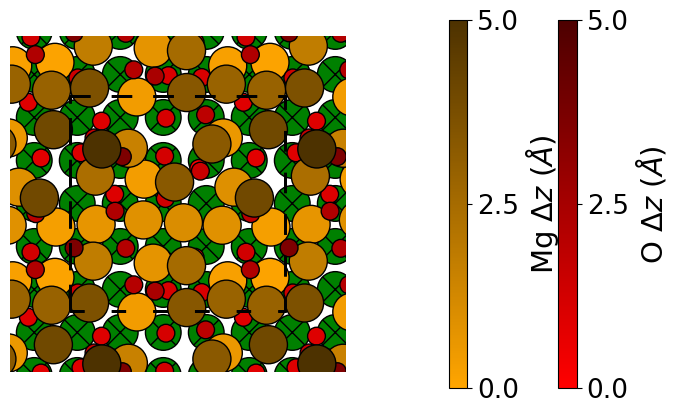

In [125]:
from ase.io import read
# from scripts.plot_structure import plot_structure
import numpy as np

# cell_offset = np.array([0, 8.7, 0])  # 22
# cell_offset = np.array([8.7, 8.7, 0]) # 23
# cell_offset = np.array([5, 5, 0]) # 24

# cell_offset = np.array([10, 10, 0])  
# structs = read(f"{dir_out}/{dir_xsf}/20/struct_1577.xsf")
# structs = read(f"{dir_out}/{dir_xsf}/18/struct_259.xsf")
# structs = read(f"{dir_out}/{dir_xsf}/19/struct_1109.xsf")
# atom_center = structs.get_positions().mean(axis=0)
# structs.rotate(90, 'z', center=atom_center)

# structs = read(f"{dir_out}/{dir_xsf}/19/struct_919.xsf")
# structs = read(f"{dir_out}/{dir_xsf}/19/struct_1124.xsf")
# structs = read(f"{dir_out}/{dir_xsf}/19/struct_1255.xsf")
# atom_center = structs.get_positions().mean(axis=0)
# structs.rotate(90, 'z', center=atom_center) #90

"""
734        | 0.447726        | 0.150352 
1040       | 0.500796        | 0.128013 
1237       | 0.549279        | 0.160606  

528        | 0.203660        | 1.223577 
748        | 0.247753        | 0.363083  
947        | 0.304457        | 0.445915 

1109| 0.0
56         | 0.098679        | 3.001485  
1268       | 0.181848        | 5.850280 
"""


# structs = read(f"{dir_out}/{dir_xsf}/18/struct_259.xsf")
# structs = read(f"{dir_out}/{dir_xsf}/20/struct_1577.xsf")
# constraint_symbols = ['Mg', 'O'] 
# height_darken_symbols = ['Fe']
# show_colorbar = True
# max_cbar = 5.0

# structs = read(f"1_result/32_dos/selected_structures_dos.traj", index=0)
# show_colorbar = False
# constraint_symbols = ['Mg', 'O'] 


# structs = read(f"{dir_out}/{dir_xsf}/19/struct_431.xsf") # struct_476
structs = read(f"{dir_out}/{dir_xsf}/39/struct_104.xsf")
constraint_symbols =  ['Fe'] # ['Mg', 'O'] 
height_darken_symbols =  ['Mg', 'O']
atom_center = structs.get_positions().mean(axis=0)
structs.rotate(90, 'z', center=atom_center) #90
show_colorbar = True
max_cbar = 5.0
cell_offset = np.array([3, 3, 0]) # 24


plot_structure(
    structs, 
    # axis_off = True,
    # plane='xz+',
    plane='xy+',
    # figsize=(3, 3),
    # figsize=(4, 4),
    figsize=(7, 7),

    cell_offset = cell_offset,
    repeat=3,
    constraint_symbols= constraint_symbols, 
    # height_darken_symbols=height_darken_symbols,  
    
    add_cell = True,
    radius_factor = 0.9,
    # linewidths = 2.5,
    linewidths = 2.0,
    cbar_label=r'$\Delta z$ ($\AA$)',
    show_colorbar = show_colorbar,
    fontsize = 21,
    max_cbar = max_cbar, #0.75,
    darken_factor=0.7,   # 0.0 = original color, 1.0 = goes toward black
    num_ticks=3          # Custom number of axis values
)

# make multiple ground state

Traj: traj_27.traj
  Lowest Energy: -590.7419 eV
  Fe layer thickness (span): 4.200 Å


Traj: traj_28.traj
  Lowest Energy: -524.8829 eV
  Fe layer thickness (span): 5.626 Å
Traj: traj_29.traj
  Lowest Energy: -498.8230 eV
  Fe layer thickness (span): 3.997 Å
Traj: traj_30.traj
  Lowest Energy: -458.6738 eV
  Fe layer thickness (span): 5.614 Å
Traj: traj_31.traj
  Lowest Energy: -441.4255 eV
  Fe layer thickness (span): 4.004 Å
Traj: traj_19.traj
  Lowest Energy: -436.9093 eV
  Fe layer thickness (span): 3.652 Å


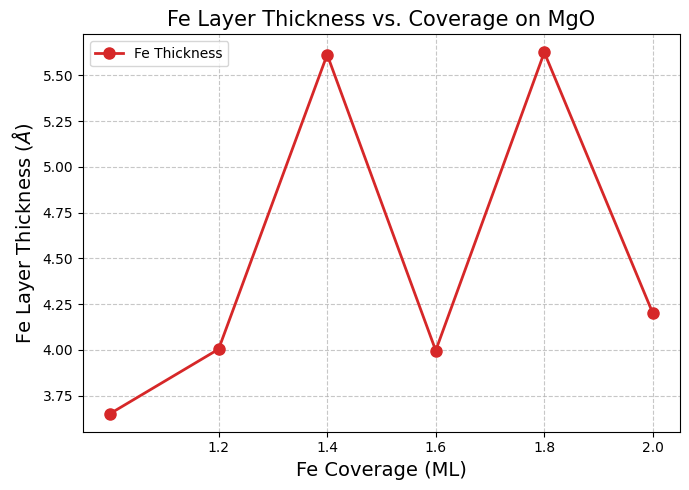

In [55]:
import os
import numpy as np
from ase.io import read
from ase.constraints import FixAtoms
from scripts.plot_structure import plot_structure

trajs = ["traj_27.traj", "traj_28.traj", "traj_29.traj", "traj_30.traj", "traj_31.traj", "traj_19.traj"]

output_img_dir = f"{dir_out}/2_im"
os.makedirs(output_img_dir, exist_ok=True)

thickness_list = []
for traj, (_,num) in zip(trajs,db_paths):
    
    output_img_dir_num = f"{output_img_dir}/{num}"
    os.makedirs(output_img_dir_num, exist_ok=True)

    structures = read(f"{dir_out}/{dir_xsf_traj}/{traj}", index=':')
    energies = [s.get_potential_energy() for s in structures]
    best_idx = np.argmin(energies)
    best_structure = structures[best_idx]

    symbols = np.array(best_structure.get_chemical_symbols())
    positions = best_structure.get_positions()

    fe_indices = np.where(symbols == 'Fe')[0]
    
    z_fe = positions[fe_indices, 2]

    fe_thickness = z_fe.max() - z_fe.min()
    plot_structure(
        best_structure, 
        plane='xy+', 
        save_path = f"{output_img_dir_num}/ground_{best_idx}.png",
        figsize=(5, 5),
        cell_offset=cell_offset,
        repeat=3,
        constraint_symbols=['Mg', 'O'], 
        height_darken_symbols=['Fe'],  
        add_cell=True,
        radius_factor=0.9,
        linewidths=2.5,
        cbar_label=r'$\Delta z$ ($\AA$)',
        show_colorbar=True,
        fontsize=21,
        max_cbar=5.61, 
        darken_factor=0.7,
        num_ticks=3,
        plot_show=False,
    )

    print(f"Traj: {traj}")
    print(f"  Lowest Energy: {best_structure.get_potential_energy():.4f} eV")
    print(f"  Fe layer thickness (span): {fe_thickness:.3f} Å")

    thickness_list.append(fe_thickness)

coverage_list = [float(label.split()[0]) for label in labels]
sorted_data = sorted(zip(coverage_list, thickness_list))
x_plot, y_plot = zip(*sorted_data)

# # 4. Create the plot
plt.figure(figsize=(7, 5))
plt.plot(x_plot, y_plot, marker='o', markersize=8, linestyle='-', linewidth=2, color='tab:red', label='Fe Thickness')

# # Formatting
plt.xlabel("Fe Coverage (ML)", fontsize=14)
plt.ylabel(r"Fe Layer Thickness ($\AA$)", fontsize=14)
plt.title("Fe Layer Thickness vs. Coverage on MgO", fontsize=15)
plt.xticks(np.arange(1.2, 2.1, 0.2)) # Ensure ticks match your data
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.savefig(f"{output_img_dir}/fe_thickness_vs_coverage.png", dpi=300)
plt.show()

## Index Finder

In [ ]:
import numpy as np
from ase.io import read

target_energy = 0 # 0.254 # 0.5106 eV
tolerance = 0.2      # 0.005
top_n = 5   # 3          

structures = read(f"{dir_out}/{dir_xsf_traj}/traj_28.traj", index=':')
raw_energies, z_height_spans = [], []

# for atoms in structures:
#     try:
#         raw_energies.append(atoms.get_potential_energy())
#         z_pos = atoms.get_positions()[:, 2]
#         z_height_spans.append(z_pos.max() - z_pos.min())
#     except Exception:
#         continue

for atoms in structures:
    try:
        symbols = np.array(atoms.get_chemical_symbols())
        fe_indices = np.where(symbols == 'Fe')[0]
        
        if len(fe_indices) > 0:
            z_fe = atoms.get_positions()[fe_indices, 2]
            
            z_height_spans.append(z_fe.max() - z_fe.min())
            raw_energies.append(atoms.get_potential_energy())
            
    except Exception as e:
        print(f"Skipping frame due to error: {e}")
        continue

num_atoms = len(structures[0])
energies = (np.array(raw_energies) - min(raw_energies)) / num_atoms
z_data = np.array(z_height_spans)
z_data = z_data - min(z_data)

energy_mask = np.abs(energies - target_energy) <= tolerance
target_indices = np.where(energy_mask)[0]

if len(target_indices) > 0:
    subset_z = z_data[target_indices]

    flat_sub_indices = np.argsort(subset_z)[:top_n] # find flattest
    idx_flat = target_indices[flat_sub_indices]

    peak_sub_indices = np.argsort(subset_z)[::-1][:top_n] # find peak height
    idx_peak = target_indices[peak_sub_indices]

    target_median_z = np.median(subset_z)
    median_diffs = np.abs(subset_z - target_median_z)
    median_sub_indices = np.argsort(median_diffs)[:top_n]
    idx_median = target_indices[median_sub_indices]

    categories = [
        ("Flattest & Near Flattest", idx_flat),
        ("Median & Near Median", idx_median),
        ("Peak & Near Peak", idx_peak)
    ]

    for label, indices in categories:
        print(f"[{label}]")
        print(f"{'Index':<10} | {'Energy (eV/at)':<15} | {'Z-Span (Å)':<10}")
        print("-" * 42)
        for idx in indices:
            # We use energies[idx] to see exactly how close it was to 0.5106
            print(f"{idx:<10} | {energies[idx]:<15.6f} | {z_data[idx]:<10.6f}")
        print()


[Flattest & Near Flattest]
Index      | Energy (eV/at)  | Z-Span (Å)
------------------------------------------
119        | 0.000000        | 1.981761  

[Median & Near Median]
Index      | Energy (eV/at)  | Z-Span (Å)
------------------------------------------
119        | 0.000000        | 1.981761  

[Peak & Near Peak]
Index      | Energy (eV/at)  | Z-Span (Å)
------------------------------------------
119        | 0.000000        | 1.981761  



# dos

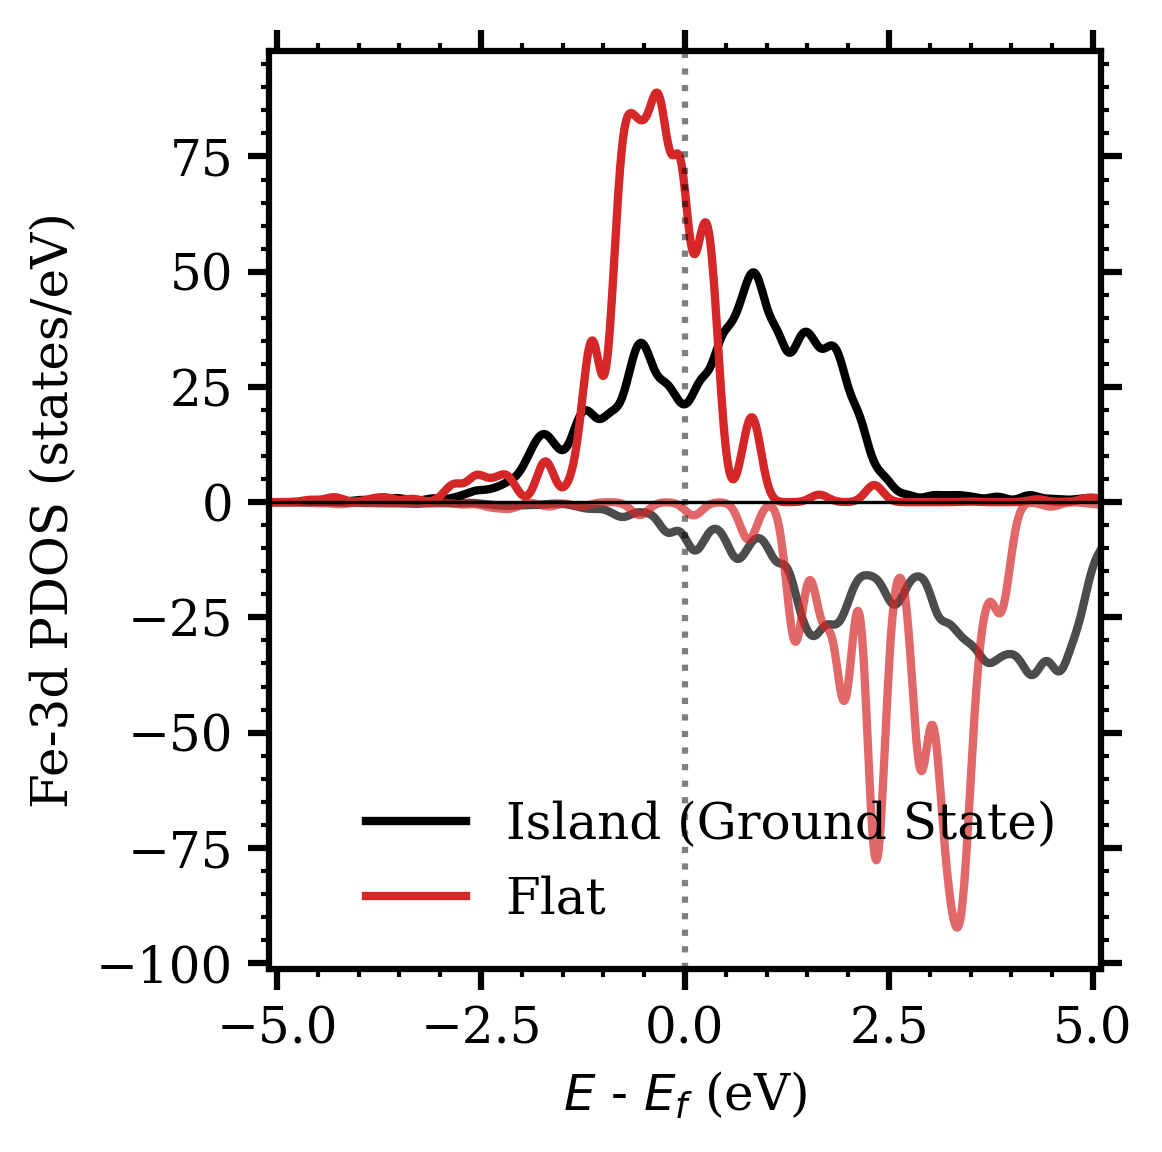

Plotting complete. File saved: dos_comparison_overlay.png


In [16]:
import pandas as pd
import matplotlib.pyplot as plt

seed_map = {3: 'Island (Ground State)', 4: 'Flat'}
use_multi_color = True                 
main_color = 'black'                   
color_map = {'Island': '#1f77b4', 'Flat': '#d62728'} 
line_styles = {'Island': '-', 'Flat': '-'} 
energy_range = (-5.1, 5.1)                 

plot_type = 'overlay'                  # Options: 'subplot' or 'overlay'
fig_dims = (4, 4)                      
dpi_val = 300                          
x_label = '$E$ - $E_f$ (eV)'
y_label = 'Fe-3d PDOS (states/eV)'
plot_title = 'Fe-3d Comparison: Island vs Flat Growth'
legend_loc = 'lower right'             

data = {}
for seed, name in seed_map.items():
    try:
        df = pd.read_csv(f"{dir_simul}/37_dos/dos_seed_{seed}.csv")
        data[name] = df
    except (FileNotFoundError, NameError) as e:
        print(f"Skipping {name}: {e}")

if plot_type == 'subplot':
    fig, axes = plt.subplots(2, 1, figsize=(fig_dims[0], fig_dims[1] * 1.8), sharex=True, dpi=dpi_val)
    
    for i, name in enumerate(data.keys()):
        ax = axes[i]
        df = data[name]
        c = color_map.get(name, main_color) if use_multi_color else main_color
        
        # Total DOS + Filled Fe-3d
        ax.plot(df['energy'], df['total_dos_up'], color='black', lw=1, label='Total DOS')
        ax.fill_between(df['energy'], df['total_Fe_d_up'], color=c, alpha=0.4, label=f'{name}')
        
        # Spin Down Mirrored
        ax.plot(df['energy'], -df['total_dos_down'], color='black', lw=1)
        ax.fill_between(df['energy'], -df['total_Fe_d_down'], color=c, alpha=0.6)
        
        ax.axvline(x=0, color='gray', linestyle=':', lw=1, alpha=0.7)
        ax.axhline(y=0, color='black', lw=0.8)
        ax.set_xlim(energy_range)
        ax.set_ylabel('DOS (states/eV)')
        ax.set_title(f'Electronic Structure: {name}', fontweight='bold')
        ax.legend(frameon=False, loc=legend_loc)
    plt.xlabel(x_label)

elif plot_type == 'overlay':
    plt.figure(figsize=fig_dims, dpi=dpi_val)
    
    for name in data.keys():
        df = data[name]
        ls = line_styles.get(name, '-')
        c = color_map.get(name, main_color) if use_multi_color else main_color
        
        # Plotting manifold
        plt.plot(df['energy'], df['total_Fe_d_up'], 
                 color=c, ls=ls, lw=2, label=f'{name}')
        
        # Spin down mirrored
        plt.plot(df['energy'], -df['total_Fe_d_down'], 
                 color=c, ls=ls, lw=2, alpha=0.7)
    
    plt.axvline(x=0, color='black', linestyle=':', alpha=0.5)
    plt.axhline(y=0, color='black', lw=0.8)
    plt.xlim(energy_range)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    # plt.title(plot_title)
    plt.legend(frameon=False, loc=legend_loc)

# --- SAVE & DISPLAY ---
plt.tight_layout()
output_name = f"dos_comparison_{plot_type}.png"
plt.savefig(output_name, bbox_inches='tight')
plt.show()

print(f"Plotting complete. File saved: {output_name}")

# kmeans

Success: Clustering results saved to clustering_results.csv


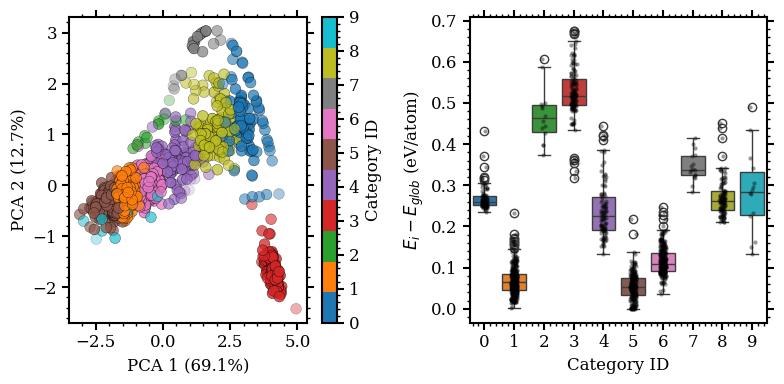

Category   | Count    | Avg Rel Energy (eV/atom) 
--------------------------------------------------
0          | 93       | 0.267962
1          | 346      | 0.067888
2          | 14       | 0.469168
3          | 133      | 0.524764
4          | 100      | 0.239421
5          | 223      | 0.055249
6          | 285      | 0.116500
7          | 17       | 0.344801
8          | 108      | 0.269817
9          | 14       | 0.284491


In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ase.io import read
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from agox.models.descriptors import Fingerprint

INPUT_TRAJ = f"{dir_out}/{dir_xsf_traj}/traj_19.traj"
CSV_OUTPUT = "clustering_results.csv" 

structures = read(INPUT_TRAJ, index=':')
num_atoms = len(structures[0])
energies = np.array([s.get_potential_energy() for s in structures])
rel_energies = (energies - np.min(energies)) / num_atoms

descriptor = Fingerprint.from_atoms(structures[0])
X_raw = np.array(descriptor.get_features(structures))
X = X_raw.sum(axis=1) if X_raw.ndim == 3 else X_raw

# X_scaled = StandardScaler().fit_transform(X)
X_scaled = X

n_categories = 1 + min(9, int(np.floor(len(energies) / 5)))
kmeans = KMeans(
    n_clusters=n_categories, 
    init='k-means++', 
    n_init=10, 
    random_state=42
)
labels = kmeans.fit_predict(X_scaled)

# Calculate "certainty" based on distance to center 
# (Closer to center = higher alpha)
distances = kmeans.transform(X_scaled) 
min_distances = np.min(distances, axis=1)
# Normalize distances for alpha (1.0 at center, 0.2 at furthest point)
alpha_values = 1.0 - 0.8 * (min_distances / np.max(min_distances))

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled)
variance_ratio = pca.explained_variance_ratio_

data_to_save = {
    'structure_index': np.arange(len(structures)),
    'category_id': labels,
    'potential_energy_ev': energies,
    'relative_energy_ev_atom': rel_energies,
    'pca_1': X_2d[:, 0],
    'pca_2': X_2d[:, 1],
    'dist_to_centroid': min_distances
}

df = pd.DataFrame(data_to_save)
df.to_csv(f"{dir_out}/{CSV_OUTPUT}", index=False)
print(f"Success: Clustering results saved to {CSV_OUTPUT}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

scatter1 = ax1.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='tab10', 
                       s=60, alpha=alpha_values, edgecolors='black', linewidth=0.3)
# ax1.set_title(f"K-Means++ Categories ({n_categories} clusters)")
ax1.set_xlabel(f'PCA 1 ({variance_ratio[0]*100:.1f}%)')
ax1.set_ylabel(f'PCA 2 ({variance_ratio[1]*100:.1f}%)')
fig.colorbar(scatter1, ax=ax1, label='Category ID')

sns.boxplot(x=labels, y=rel_energies, ax=ax2, palette='tab10', hue=labels, legend=False)
sns.stripplot(x=labels, y=rel_energies, ax=ax2, color='black', size=3, alpha=0.4)
# ax2.set_title('Thermodynamic Stability by Category')
ax2.set_xlabel('Category ID')
ax2.set_ylabel(r'$E_i - E_{glob}$ (eV/atom)')

plt.tight_layout()
plt.show()

print(f"{'Category':<10} | {'Count':<8} | {'Avg Rel Energy (eV/atom)':<25}")
print("-" * 50)
for i in range(n_categories):
    mask = (labels == i)
    count = np.sum(mask)
    if count > 0:
        avg_e = np.mean(rel_energies[mask])
        print(f"{i:<10} | {count:<8} | {avg_e:.6f}")

# Best so far xsf

In [69]:
from ase.io import write
import numpy as np
import os
# from .plot_structure import plot_structure
from scripts.plot_structure import plot_structure


def write_best_so_far_xsf(
    trajs, 
    energies, 
    output_dir = '.',

    cell_offset = np.array([0.5, 0.5, 0]),
    constraint_symbols = ['Mg', 'O'],
    visual_params = {
        'repeat': 3,
        'figsize': (7, 7),
        'radius_factor': 0.9,
        'linewidths': 2.0,
        'darken_factor': 0.7,
        'add_cell': True,
        'fontsize': 21,
        'plot_show': False,
        'show_colorbar': True,
        'num_ticks': 3
    },
):
    
    """
    Writes the best-so-far structures from a list of ASE trajectories to XSF files.

    Parameters:
        trajs (list): List of ASE Atoms objects.
        energies (list): List of potential energies corresponding to trajs.
        output_dir (str): Directory to save XSF files.
    """

    os.makedirs(output_dir, exist_ok=True)
    dir_im = os.path.join(output_dir, "dir_im")
    os.makedirs(dir_im, exist_ok=True)

    best_so_far_indices = []
    current_best = float('inf')
    for i, e in enumerate(energies):
        if e < current_best:
            current_best = e
            best_so_far_indices.append(i)
    
    # recheck if glob min is already inside
    absolute_min_idx = int(np.argmin(energies))
    if absolute_min_idx not in best_so_far_indices:
        best_so_far_indices.append(absolute_min_idx)
    
    best_so_far_indices.sort()

    for idx in best_so_far_indices:
        atoms = trajs[idx].copy()

        # Clean atoms for XSF compatibility
        for key in ['initial_magmoms', 'magmoms']:
            if key in atoms.arrays:
                del atoms.arrays[key]

        # Save XSF
        fname = os.path.join(output_dir, f"{idx}.xsf")
        write(fname, atoms)

        # Generate plots for all three planes
        for plane in ['xy+', 'yz+', 'xz+']:
            save_name = f"figure_{plane[:2]}_{idx}.png"
            
            plot_structure(
                atoms,
                plane=plane,
                save_path=os.path.join(dir_im, save_name),
                cell_offset=cell_offset,
                constraint_symbols=constraint_symbols,
                **visual_params
            )


"""
for dir_path, file_idx in db_paths:
    db_path = f"{dir_path}/1_db/db_0.db"
    database = Database(filename=db_path)
    database.restore_to_memory()
    trajs = database.restore_to_trajectory()
    
    energies = [atoms.get_potential_energy() for atoms in trajs]
    
    output_path = f"{dir_out}/{dir_xsf_min_so_far}/{file_idx}"
    write_best_so_far_xsf(trajs=trajs, energies=energies, output_dir=output_path)
"""

'\nfor dir_path, file_idx in db_paths:\n    db_path = f"{dir_path}/1_db/db_0.db"\n    database = Database(filename=db_path)\n    database.restore_to_memory()\n    trajs = database.restore_to_trajectory()\n    \n    energies = [atoms.get_potential_energy() for atoms in trajs]\n    \n    output_path = f"{dir_out}/{dir_xsf_min_so_far}/{file_idx}"\n    write_best_so_far_xsf(trajs=trajs, energies=energies, output_dir=output_path)\n'

In [72]:
# from scripts.write_best_so_far_xsf import write_best_so_far_xsf
from ase.io import read

trajs = read(f"{dir_out}/{dir_xsf_traj}/traj_1.traj", index=":")
all_e = [atoms.get_potential_energy() for atoms in trajs]

write_best_so_far_xsf(
    trajs=trajs,
    energies=all_e, 
    output_dir=f"{dir_out}/{dir_xsf_min_so_far}/1",
    cell_offset = np.array([0.5, 0.5, 0]),
    constraint_symbols = ['Mg', 'O'],
    visual_params = {
        'repeat': 3,
        'figsize': (4, 4),
        'radius_factor': 0.9,
        'linewidths': 2.0,
        'darken_factor': 0.7,
        'add_cell': True,
        'fontsize': 21,
        'plot_show': False,
        'show_colorbar': True,
        'num_ticks': 3,
        'max_cbar': 5.0,
        'cbar_label': r'$\Delta z$ (Å)',
    })

# Make snapshot

In [6]:
import os
import numpy as np
from ase.io import read
from ase.constraints import FixAtoms
from scripts.plot_structure import plot_structure

# --- 1. Selection Logic & Data Preparation ---
structures = read(f"{dir_out}/{dir_xsf_traj}/traj_19.traj", index=':')
raw_energies, z_height_spans = [], []

for atoms in structures:
    try:
        raw_energies.append(atoms.get_potential_energy())
        z_pos = atoms.get_positions()[:, 2]
        z_height_spans.append(z_pos.max() - z_pos.min())
    except Exception:
        continue

num_atoms = len(structures[0])
energies = (np.array(raw_energies) - min(raw_energies)) / num_atoms
z_data = np.array(z_height_spans)
z_data = z_data - min(z_data)

energy_threshold = 0.25
low_energy_indices = np.where(energies < energy_threshold)[0]
n_show = 4  

if len(low_energy_indices) >= n_show:
    subset_z = z_data[low_energy_indices]
    sorted_subset_indices = np.argsort(subset_z)
    
    # Define the three distinct groups
    low_z_indices = low_energy_indices[sorted_subset_indices[:n_show]]
    high_z_indices = low_energy_indices[sorted_subset_indices[-n_show:]]
    
    mid_point = len(sorted_subset_indices) // 2
    half_n = n_show // 2
    mid_z_indices = low_energy_indices[sorted_subset_indices[mid_point - half_n : mid_point - half_n + n_show]]

    # This is the variable used by the plotting loop below
    categories = {
        "flat": low_z_indices,
        "mid": mid_z_indices,
        "tall": high_z_indices
    }
else:
    print(f"Error: Not enough structures below {energy_threshold}.")
    categories = {}

# --- 2. Automated Plotting Loop ---
output_img_dir = f"./{dir_out}/structure_images"
if not os.path.exists(output_img_dir) and categories:
    os.makedirs(output_img_dir)

for cat_prefix, idx_list in categories.items():
    for i, idx in enumerate(idx_list):
        file_path = f"{dir_out}/{dir_xsf}/19/struct_{idx}.xsf"
        
        if not os.path.exists(file_path):
            print(f"Skipping: {file_path} not found.")
            continue
            
        structs = read(file_path)
        
        # Substrate setup
        substrate_symbols = ['Mg', 'O']
        substrate_indices = [atom.index for atom in structs if atom.symbol in substrate_symbols]
        structs.set_constraint(FixAtoms(indices=substrate_indices))

        # View settings
        cell_offset = np.array([5, 5, 0])  
        save_path = f"{output_img_dir}/{cat_prefix}_{i}_idx{idx}.png"

        print(f"Generating image: {save_path}")
        plot_structure(
            structs,
            plane='yz+', # Side view to capture Delta Z evolution
            save_path=save_path,
            figsize=(5, 5),
            repeat=7,
            plot_show=False, 
            linewidths_cell=4.0,
            cell_offset=cell_offset,
            darken_factor=0.3,
            n_darken_layers=2,
        )

print("\nProcessing complete.")

Generating image: ./0_analy/structure_images/flat_0_idx851.png
Generating image: ./0_analy/structure_images/flat_1_idx734.png
Generating image: ./0_analy/structure_images/flat_2_idx839.png
Generating image: ./0_analy/structure_images/flat_3_idx500.png
Generating image: ./0_analy/structure_images/mid_0_idx898.png
Generating image: ./0_analy/structure_images/mid_1_idx73.png
Generating image: ./0_analy/structure_images/mid_2_idx887.png
Generating image: ./0_analy/structure_images/mid_3_idx361.png
Generating image: ./0_analy/structure_images/tall_0_idx1222.png
Generating image: ./0_analy/structure_images/tall_1_idx588.png
Generating image: ./0_analy/structure_images/tall_2_idx1227.png
Generating image: ./0_analy/structure_images/tall_3_idx1268.png

Processing complete.


# Energy progression

In [47]:
colors = [
    "#FFA500",
    "#006400",
]

labels = [
    "MgO on Fe",
    "Fe on MgO",
]

1_result/0_5x5_mgoOnFe/1_db/db_0.db
1_result/0_5x5_feOnMgo/1_db/db_0.db


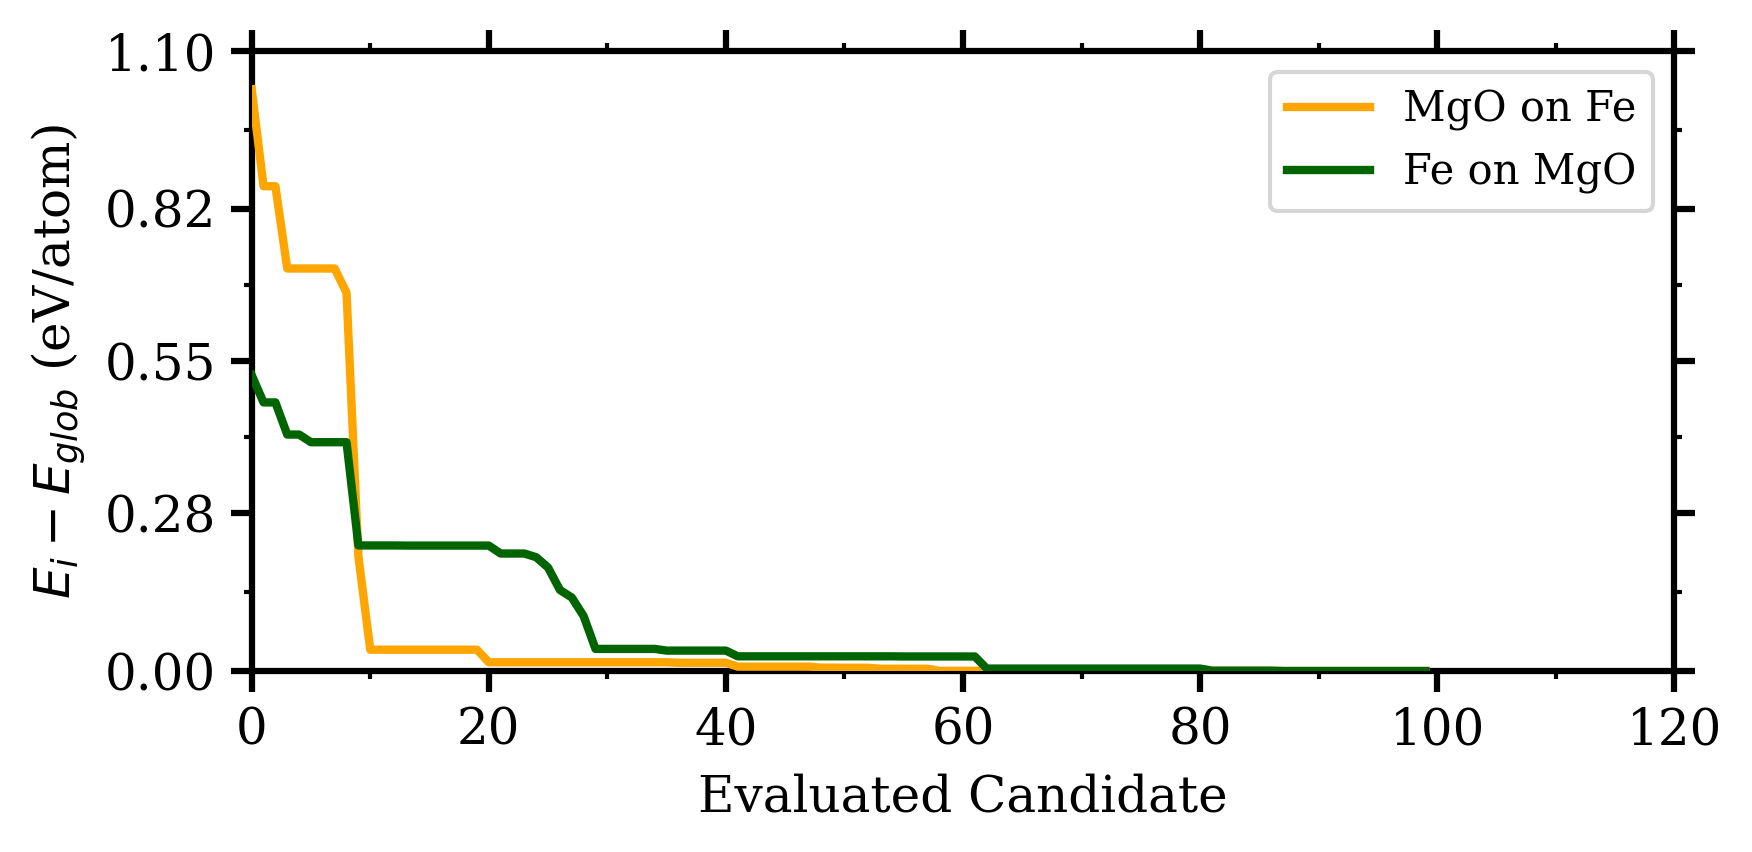

In [52]:
from scripts.plot_energy_progression import plot_energy_progression
import numpy as np

max_x = 120
max_y = 1.1

xticks = np.linspace(0, max_x, 7)
xticks = np.round(xticks).astype(int)

yticks = np.linspace(0, max_y, 5)
yticks = np.round(yticks, 2)

x_lim=(0, max_x)
y_lim=(0, max_y)


plot_energy_progression(
    db_paths,
    labels,
    dir_out,
    dir_im,

    figsize=(6, 3),

    y_label=e_label,
    x_label=r'Evaluated Candidate',
    line_styles=['-'],

    rcParams=rcParams,
    colors=colors,

    linewidth=2.0,

    x_lim=x_lim,
    y_lim=y_lim,

    xticks = xticks,
    yticks = yticks,

    # index_skip=3,
    # add_scatter=True,
    #scale_up = 1,
)

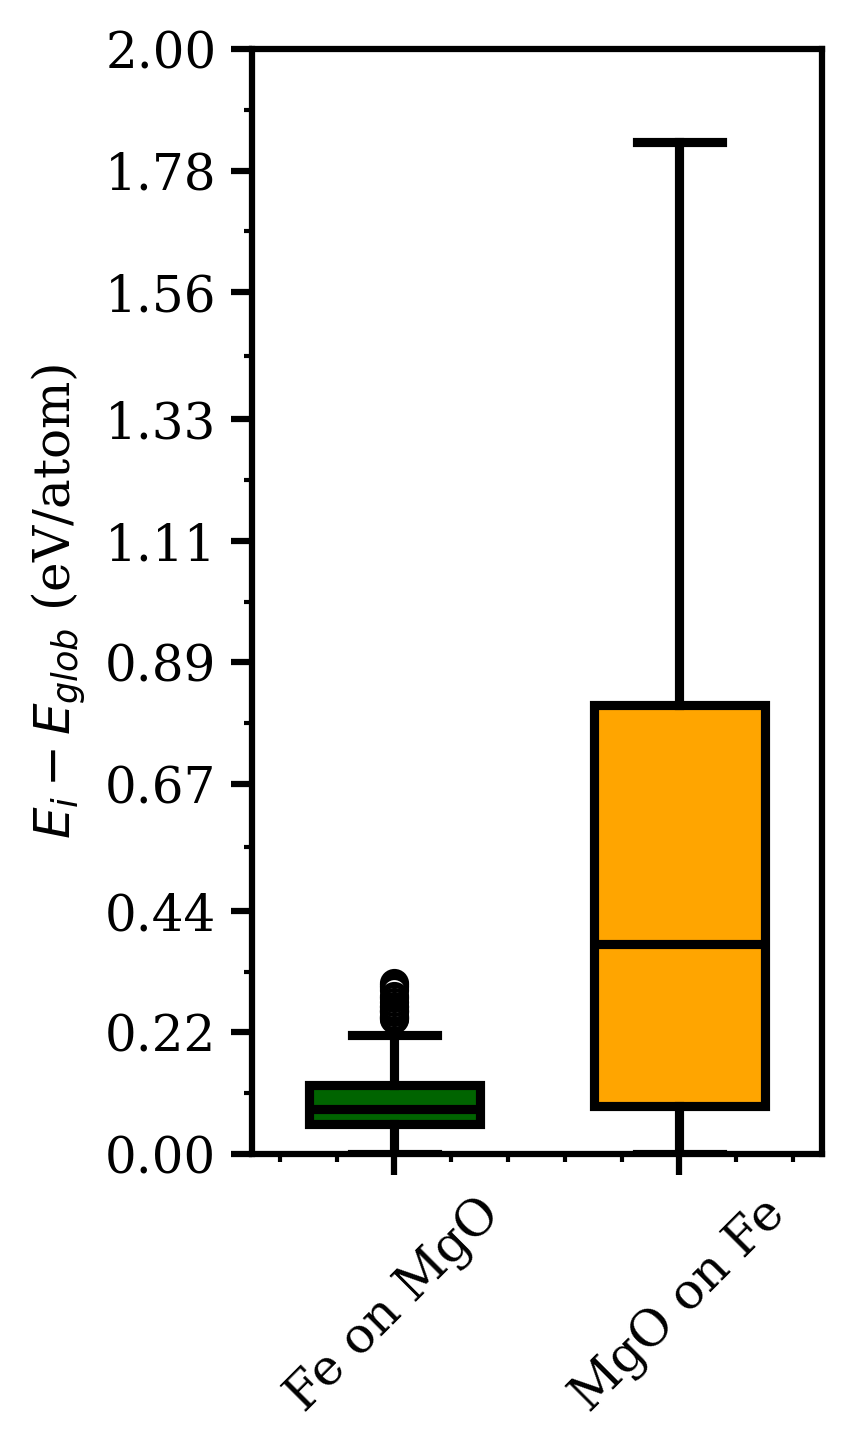

In [45]:
from scripts.plot_energy_distribution import plot_energy_distribution

max_x = 2
max_y = 2.0

xticks = np.linspace(0, max_x, 2)
xticks = np.round(xticks).astype(int)

yticks = np.linspace(0, max_y, 10)
yticks = np.round(yticks, 2)

x_lim=(0, max_x)
y_lim=(0, max_y)

plot_energy_distribution(
        db_paths,
        labels,
        dir_out,
        dir_im,
        figsize=(3, 5),
        y_label=e_label,
        x_label=None,
        colors=colors,

        # xticks = xticks,
        yticks = yticks,

        # x_lim=x_lim,
        y_lim=y_lim,
        
        plot_type="box",  # "box" or "density"
        font_family='serif',
        rcParams=rcParams,
        widths = 0.6
)

# Pca

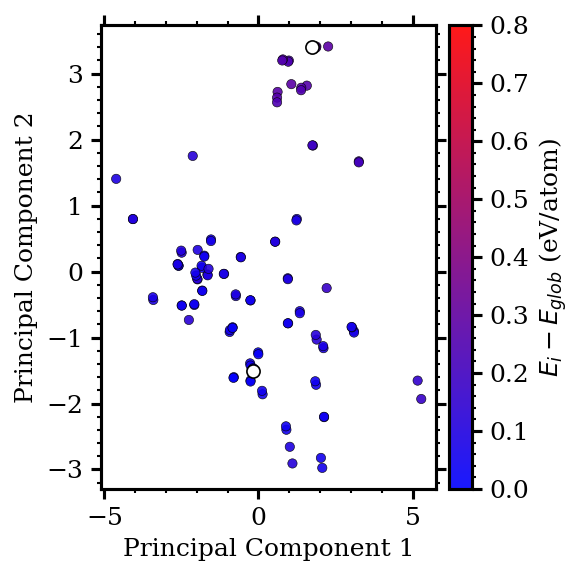

In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from agox.databases import Database
from agox.models.descriptors.fingerprint import Fingerprint
from matplotlib.colors import LinearSegmentedColormap

from matplotlib.ticker import FixedLocator

# Plot configuration
figsize = (4, 4)
min_x, max_x = -4, 4
min_y, max_y = -2, 4
min_e, max_e = 0.0, 0.8

# Generate tick values
xticks = np.round(np.linspace(min_x, max_x, 5), 0)
yticks = np.round(np.linspace(min_y, max_y, 5), 1)
eticks = np.round(np.linspace(min_e, max_e, 10), 1)

xticks_minor = (xticks[:-1] + xticks[1:]) / 2
yticks_minor = (yticks[:-1] + yticks[1:]) / 2
eticks_minor = (eticks[:-1] + eticks[1:]) / 2

# Load database
dir_path = db_paths[0][0]
db_path = os.path.join(dir_path, "1_db", "db_0.db")
db = Database(filename=db_path)
db.restore_to_memory()
traj = db.restore_to_trajectory()

# Extract descriptors and energies
descriptor = Fingerprint.from_atoms(traj[0])
all_features, raw_energies = [], []

for atoms in traj:
    try:
        f = descriptor.create_features(atoms)
        all_features.append(f.flatten())
        raw_energies.append(atoms.get_potential_energy())
    except Exception:
        continue 

# Process data
X = np.array(all_features)
num_atoms = len(traj[0])
energies = (np.array(raw_energies) - min(raw_energies)) / num_atoms

# Dimension reduction
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Initialize plot
fig, ax = plt.subplots(figsize=figsize, dpi=150)

# Create custom colormap
cmap = LinearSegmentedColormap.from_list("custom", ["#0000FF", "#FF0000"])

# Plot scatter data
sc = ax.scatter(
    X_pca[:, 0], X_pca[:, 1], c=energies, 
    cmap=cmap, vmin=min_e, vmax=max_e, 
    s=20, alpha=0.9, edgecolors='black', linewidths=0.3
)

# Find indices for the global minimum and maximum energies
idx_min: int = np.argmin(energies)
idx_max: int = np.argmax(energies)

# Add additional scatter points for extrema in black
# Using 'X_pca' for coordinates and a distinct size/edge for visibility
ax.scatter(
    X_pca[[idx_min, idx_max], 0], 
    X_pca[[idx_min, idx_max], 1], 
    color='white',
    s=40,               # Slightly larger than the standard points
    marker='o',         # Circular marker
    edgecolors='black', # White edge to make black points pop
    linewidths=0.8,
    zorder=10           # Ensure these points are on top of the main scatter
)

# Set axis aesthetics
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
# ax.set_xlim(min_x, max_x)
# ax.set_ylim(min_y, max_y)
# ax.set_xticks(xticks)
# ax.set_yticks(yticks)
# ax.tick_params(labelsize=12)

# ax.xaxis.set_minor_locator(FixedLocator(xticks_minor))
# ax.yaxis.set_minor_locator(FixedLocator(yticks_minor))

# Configure colorbar
cbar = fig.colorbar(sc, ax=ax, shrink=1, pad=0.03)
cbar.set_label(e_label)
# cbar.set_ticks(eticks)
# cbar.ax.yaxis.set_minor_locator(FixedLocator(eticks_minor))

# Save figure
fig.tight_layout()
out_path = os.path.join(dir_out, dir_im, 'energy_landscape_pca.png')
fig.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()

# Make graph of height

In [41]:
import matplotlib.pyplot as plt
from pathlib import Path

from agox.databases import Database

from scripts.calculate_relative_energy import calculate_relative_energy
from scripts.calculate_best_so_far import calculate_best_so_far

db_path = db_paths[0][0]
# Database loading
db_path = Path(db_path) / "1_db" / "db_0.db"
database = Database(filename=str(db_path))
trajs = database.restore_to_trajectory()

# Data Calculation
_, _, _, rel_energies = calculate_relative_energy(trajs)
best_energies, best_indices = calculate_best_so_far(rel_energies)

z_height_spans = [atoms.get_positions()[:, 2].max() - atoms.get_positions()[:, 2].min() for atoms in trajs]

In [ ]:

z_height_spans = [atoms.get_positions()[:, 2].max() - atoms.get_positions()[:, 2].min() for atoms in trajs]
plt.scatter(rel_energies_mev, z_height_spans, color=colors[0], s=20, edgecolors='black', linewidths=0.5)


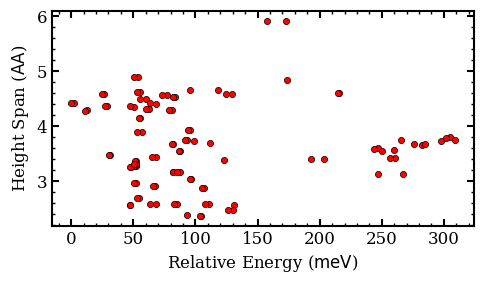

In [42]:
import matplotlib.pyplot as plt

plt.rcParams.update(rcParams)

# Data Conversion
rel_energies_mev = [e * 1000 for e in rel_energies]

# Plotting with Reversed Axes
plt.figure(figsize=(5, 3))
plt.scatter(rel_energies_mev, z_height_spans, color=colors[0], s=20, edgecolors='black', linewidths=0.5)

plt.xlabel(r"Relative Energy ($\text{meV}$)")
plt.ylabel(r"Height Span ($\text{\AA}$)")
plt.tight_layout()
plt.savefig('energy_vs_z_scatter.png', dpi=300)

# trash

## conf space

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import AutoMinorLocator
import matplotlib.patheffects as patheffects
from scipy.stats import gaussian_kde

def plot_structure_landscape(
    X_eigen, 
    energies,                    # Can be an array, list of arrays, or dict of arrays
    z_data=None, 
    show_colorbar=True, 
    cmap='viridis',
    z_limit=(None, None, 5),
    e_limit=(0.0, 0.8, 5),
    figsize=(6, 3),
    limits={"Islands": 0.07, "Quasi-flat": 0.25, "Flat": 0.50},
    show_limits=True, 
    fontsize=10, 
    wspace=0.05, 
    cbar_pad=0.02, 
    density_left=True,
    plot_density_only=False,  
    custom_legends=None,         # Explicit text labels list if energies is a list
    density_cmap='Blues',        # Colormap gradient name (e.g., 'Blues', 'Purples', 'magma')
    black_seed_zero=False,       # NEW PARAMETER: Force index 0 to be black, remainder to be gradient
    fill_density=False,          # Toggle to fill under the curve or not
    density_alpha=0.12,          # Control fill opacity
    dens_line_weight=0.5,
    save_path='./'
):
    
    min_e, max_e = e_limit[0], e_limit[1]
    eticks = np.round(np.linspace(min_e, max_e, e_limit[2]), 1)

    # --- Structure & Normalize Input Energies ---
    energy_datasets = {}
    if isinstance(energies, dict):
        energy_datasets = energies
    elif isinstance(energies, (list, tuple)) and len(energies) > 0 and isinstance(energies[0], (list, np.ndarray)):
        for i, dataset in enumerate(energies):
            label = custom_legends[i] if (custom_legends and i < len(custom_legends)) else f"Dataset {i+1}"
            energy_datasets[label] = np.asarray(dataset)
    else:
        # Fallback for single data array
        label = custom_legends[0] if custom_legends else "State Density"
        energy_datasets[label] = np.asarray(energies)

    # --- Setup Gradient Color Palette ---
    num_curves = len(energy_datasets)
    try:
        color_gradient = plt.colormaps.get_cmap(density_cmap)
    except AttributeError:
        # Fallback for older Matplotlib versions
        color_gradient = plt.cm.get_cmap(density_cmap)
        
    sampled_colors = []
    if num_curves > 1:
        if black_seed_zero:
            # First element is black
            sampled_colors.append('black')
            # The remaining curves divide up the gradient space evenly
            remaining_count = num_curves - 1
            if remaining_count > 1:
                color_indices = np.linspace(0.85, 0.35, remaining_count)
                for x in color_indices:
                    sampled_colors.append(color_gradient(x))
            else:
                sampled_colors.append(color_gradient(0.60))
        else:
            # Traditional dark to lighter gradient mapping sequence
            color_indices = np.linspace(0.95, 0.35, num_curves)
            sampled_colors = [color_gradient(x) for x in color_indices]
    else:
        sampled_colors = ['black' if black_seed_zero else color_gradient(0.85)]

    # --- Setup Subplots Axis Framework ---
    if plot_density_only:
        width_mod = 0.55 if num_curves > 1 else 0.4
        fig, ax_dens = plt.subplots(figsize=(figsize[0] * width_mod, figsize[1]))
        ax_scat = None
    else:
        ratios = [1, 2.5] if density_left else [2.5, 1]
        fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=figsize, sharey=True, 
                                         gridspec_kw={'width_ratios': ratios})
        fig.subplots_adjust(wspace=wspace)
        ax_scat = ax_r if density_left else ax_l
        ax_dens = ax_l if density_left else ax_r

    # --- Scatter Plot Representation ---
    if not plot_density_only:
        if z_data is not None:
            vmin = z_limit[0] if z_limit[0] is not None else np.min(z_data)
            vmax = z_limit[1] if z_limit[1] is not None else np.max(z_data)
            norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
            color_src = z_data
        else:
            norm = None
            color_src = 'white'

        scat_energies = next(iter(energy_datasets.values())) if num_curves > 1 else list(energy_datasets.values())[0]
        
        if len(X_eigen) == len(scat_energies):
            sc = ax_scat.scatter(X_eigen, scat_energies, c=color_src, s=25, 
                                 cmap=cmap if z_data is not None else None,
                                 norm=norm, edgecolors='black', linewidth=0.5, 
                                 alpha=0.5, zorder=2)
            
            if show_colorbar and z_data is not None:
                cbar = plt.colorbar(sc, ax=ax_scat, pad=cbar_pad)
                cbar.set_label(r'$\Delta z$ (Å)', fontsize=fontsize)
                tick_locs = np.linspace(vmin, vmax, z_limit[2])
                cbar.set_ticks(tick_locs)
                cbar.set_ticklabels([f"{t:.2f}" for t in tick_locs])
        else:
            print("Warning: X_eigen layout dims don't match base layout. Skipping scatter population.")

    # --- Evaluate & Generate Multiple Gaussian KDE Curves with Gradient Colors ---
    energy_grid = np.linspace(min_e, max_e, 200)
    
    for idx, (name, data_array) in enumerate(energy_datasets.items()):
        if len(data_array) > 1:
            kde = gaussian_kde(data_array)
            density = kde.evaluate(energy_grid)
            
            curve_color = sampled_colors[idx]
            
            # Plot profiles
            ax_dens.plot(density, energy_grid, color=curve_color, lw=dens_line_weight, zorder=4, label=name)
            
            if fill_density:
                ax_dens.fill_betweenx(energy_grid, 0, density, color=curve_color, alpha=density_alpha, zorder=3)

    ax_dens.set_xlabel('State Density (config./eV)', fontsize=fontsize)
    
    # Places the legend vertically outside to the far right side of the entire layout
    if num_curves > 1:
        fig.legend(
            frameon=False, 
            fontsize=fontsize-2, 
            loc='center left', 
            bbox_to_anchor=(1.02, 0.5)
        )

    if not plot_density_only and ax_scat is not None:
        ax_scat.set_xlabel(r'$\psi_{1d}(a.u.)$', fontsize=fontsize)
        ax_scat.xaxis.set_minor_locator(AutoMinorLocator())

    if plot_density_only or density_left:
        ax_dens.set_ylabel(r'$E_{i}-E_{glob}$ (eV/atom)', fontsize=fontsize)

    # --- Horizontal Boundaries Phase Limits Logic ---
    if show_limits:
        axes_to_mark = [ax_dens] if plot_density_only else [ax_l, ax_r]
        for label, val in limits.items():
            for ax in axes_to_mark:
                if ax is not None:
                    ax.axhline(y=val, color='black', linestyle='--', linewidth=1, alpha=0.5, zorder=1)
            
            display_text = f'{label}: {val:.2f} eV'
            t = ax_dens.text(0.05, val + 0.005, display_text, 
                             fontsize=8, color='black', verticalalignment='bottom', zorder=11)
            t.set_path_effects([patheffects.withStroke(linewidth=2, foreground='white')])

    # Boundary Fixes
    ax_dens.set_ylim(min_e, max_e)
    ax_dens.set_yticks(eticks)
    ax_dens.yaxis.set_minor_locator(AutoMinorLocator())

    plt.tight_layout()
    plt.savefig(f'{save_path}/conf_space.png', dpi=300, bbox_inches='tight')
    return fig
    
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import AutoMinorLocator
import matplotlib.patheffects as patheffects
from scipy.stats import gaussian_kde

def plot_structure_landscape(
    X_eigen, 
    energies,                    # Can be an array, list of arrays, or dict of arrays
    z_data=None, 
    show_colorbar=True, 
    cmap='viridis',
    z_limit=(None, None, 5),
    e_limit=(0.0, 0.8, 5),
    figsize=(6, 3),
    limits={"Islands": 0.07, "Quasi-flat": 0.25, "Flat": 0.50},
    show_limits=True, 
    fontsize=10, 
    wspace=0.05, 
    cbar_pad=0.02, 
    density_left=True,
    plot_density_only=False,  
    custom_legends=None,         # Explicit text labels list if energies is a list
    density_cmap='Blues',        # Colormap gradient name (e.g., 'Blues', 'Purples', 'magma')
    black_seed_zero=False,       # Force index 0 to be black, remainder to be gradient
    seed_zero_top_zorder=False,  # NEW PARAMETER: Force seed 0 to have the highest zorder layer visibility
    fill_density=False,          # Toggle to fill under the curve or not
    density_alpha=0.12,          # Control fill opacity
    dens_line_weight=1.5,
    save_path='./'
):
    
    min_e, max_e = e_limit[0], e_limit[1]
    eticks = np.round(np.linspace(min_e, max_e, e_limit[2]), 1)

    # --- Structure & Normalize Input Energies ---
    energy_datasets = {}
    if isinstance(energies, dict):
        energy_datasets = energies
    elif isinstance(energies, (list, tuple)) and len(energies) > 0 and isinstance(energies[0], (list, np.ndarray)):
        for i, dataset in enumerate(energies):
            label = custom_legends[i] if (custom_legends and i < len(custom_legends)) else f"Dataset {i+1}"
            energy_datasets[label] = np.asarray(dataset)
    else:
        # Fallback for single data array
        label = custom_legends[0] if custom_legends else "State Density"
        energy_datasets[label] = np.asarray(energies)

    # --- Setup Gradient Color Palette ---
    num_curves = len(energy_datasets)
    try:
        color_gradient = plt.colormaps.get_cmap(density_cmap)
    except AttributeError:
        # Fallback for older Matplotlib versions
        color_gradient = plt.cm.get_cmap(density_cmap)
        
    sampled_colors = []
    if num_curves > 1:
        if black_seed_zero:
            # First element is black
            sampled_colors.append('black')
            # The remaining curves divide up the gradient space evenly
            remaining_count = num_curves - 1
            if remaining_count > 1:
                color_indices = np.linspace(0.85, 0.35, remaining_count)
                for x in color_indices:
                    sampled_colors.append(color_gradient(x))
            else:
                sampled_colors.append(color_gradient(0.60))
        else:
            # Traditional dark to lighter gradient mapping sequence
            color_indices = np.linspace(0.95, 0.35, num_curves)
            sampled_colors = [color_gradient(x) for x in color_indices]
    else:
        sampled_colors = ['black' if black_seed_zero else color_gradient(0.85)]

    # --- Setup Subplots Axis Framework ---
    if plot_density_only:
        width_mod = 0.55 if num_curves > 1 else 0.4
        fig, ax_dens = plt.subplots(figsize=(figsize[0] * width_mod, figsize[1]))
        ax_scat = None
    else:
        ratios = [1, 2.5] if density_left else [2.5, 1]
        fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=figsize, sharey=True, 
                                         gridspec_kw={'width_ratios': ratios})
        fig.subplots_adjust(wspace=wspace)
        ax_scat = ax_r if density_left else ax_l
        ax_dens = ax_l if density_left else ax_r

    # --- Scatter Plot Representation ---
    if not plot_density_only:
        if z_data is not None:
            vmin = z_limit[0] if z_limit[0] is not None else np.min(z_data)
            vmax = z_limit[1] if z_limit[1] is not None else np.max(z_data)
            norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
            color_src = z_data
        else:
            norm = None
            color_src = 'white'

        scat_energies = next(iter(energy_datasets.values())) if num_curves > 1 else list(energy_datasets.values())[0]
        
        if len(X_eigen) == len(scat_energies):
            sc = ax_scat.scatter(X_eigen, scat_energies, c=color_src, s=25, 
                                 cmap=cmap if z_data is not None else None,
                                 norm=norm, edgecolors='black', linewidth=0.5, 
                                 alpha=0.8, zorder=2)
            
            if show_colorbar and z_data is not None:
                cbar = plt.colorbar(sc, ax=ax_scat, pad=cbar_pad)
                cbar.set_label(r'$\Delta z$ (Å)', fontsize=fontsize)
                tick_locs = np.linspace(vmin, vmax, z_limit[2])
                cbar.set_ticks(tick_locs)
                cbar.set_ticklabels([f"{t:.2f}" for t in tick_locs])
        else:
            print("Warning: X_eigen layout dims don't match base layout. Skipping scatter population.")

    # --- Evaluate & Generate Multiple Gaussian KDE Curves with Gradient Colors ---
    energy_grid = np.linspace(min_e, max_e, 200)
    
    for idx, (name, data_array) in enumerate(energy_datasets.items()):
        if len(data_array) > 1:
            kde = gaussian_kde(data_array)
            density = kde.evaluate(energy_grid)
            
            curve_color = sampled_colors[idx]
            
            # Dynamically select zorder based on the parameter choice
            if idx == 0 and seed_zero_top_zorder:
                current_line_zorder = 10
                current_fill_zorder = 9
            else:
                current_line_zorder = 4
                current_fill_zorder = 3
            
            # Plot profiles
            ax_dens.plot(density, energy_grid, color=curve_color, lw=dens_line_weight, zorder=current_line_zorder, label=name)
            
            if fill_density:
                ax_dens.fill_betweenx(energy_grid, 0, density, color=curve_color, alpha=density_alpha, zorder=current_fill_zorder)

    ax_dens.set_xlabel('State Density (config./eV)', fontsize=fontsize)
    
    # Places the legend vertically outside to the far right side of the entire layout
    if num_curves > 1:
        fig.legend(
            frameon=False, 
            fontsize=fontsize-2, 
            loc='center left', 
            bbox_to_anchor=(1.02, 0.5)
        )

    if not plot_density_only and ax_scat is not None:
        ax_scat.set_xlabel(r'$\psi_{1d}(a.u.)$', fontsize=fontsize)
        ax_scat.xaxis.set_minor_locator(AutoMinorLocator())

    if plot_density_only or density_left:
        ax_dens.set_ylabel(r'$E_{i}-E_{glob}$ (eV/atom)', fontsize=fontsize)

    # --- Horizontal Boundaries Phase Limits Logic ---
    if show_limits:
        axes_to_mark = [ax_dens] if plot_density_only else [ax_l, ax_r]
        for label, val in limits.items():
            for ax in axes_to_mark:
                if ax is not None:
                    ax.axhline(y=val, color='black', linestyle='--', linewidth=1, alpha=0.5, zorder=1)
            
            display_text = f'{label}: {val:.2f} eV'
            t = ax_dens.text(0.05, val + 0.005, display_text, 
                             fontsize=8, color='black', verticalalignment='bottom', zorder=11)
            t.set_path_effects([patheffects.withStroke(linewidth=2, foreground='white')])

    # Boundary Fixes
    ax_dens.set_ylim(min_e, max_e)
    ax_dens.set_yticks(eticks)
    ax_dens.yaxis.set_minor_locator(AutoMinorLocator())

    plt.tight_layout()
    plt.savefig(f'{save_path}/conf_space.png', dpi=300, bbox_inches='tight')
    return fig
    
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator 
from matplotlib import patheffects
from scipy.stats import gaussian_kde
from ase.io import read
import matplotlib.colors as mcolors

def plot_structure_landscape(
    X_eigen, 
    energies, 
    z_data=None, 
    show_colorbar=True, 
    cmap='viridis',
    z_limit=(None,None,5),
    e_limit=(0.0, 0.8, 5),
    figsize = (6, 3),
    limits = {"Islands": 0.07, "Quasi-flat": 0.25, "Flat": 0.50},
    wspace=0.05, # gap between ax1, and ax2
    cbar_pad=0.02, # gap of ax1 and colorbar
    density_left=True
):
    
    min_e, max_e = e_limit[0], e_limit[1]
    eticks = np.round(np.linspace(min_e, max_e, e_limit[2]), 1)

    ratios = [1, 2.5] if density_left else [2.5, 1]

    fig, (ax_l, ax_r)= plt.subplots(1, 2, figsize=figsize, sharey=True, 
                                   gridspec_kw={'width_ratios': ratios})

    fig.subplots_adjust(wspace=wspace)

    ax_scat = ax_r if density_left else ax_l
    ax_dens = ax_l if density_left else ax_r

    if z_data is not None:
        vmin = z_limit[0] if z_limit[0] is not None else np.min(z_data)
        vmax = z_limit[1] if z_limit[1] is not None else np.max(z_data)
        norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
        color_src = z_data
    else:
        norm = None
        color_src = 'white'

    sc = ax_scat.scatter(X_eigen, energies, c=color_src, s=25, 
                         cmap=cmap if z_data is not None else None,
                         norm=norm, edgecolors='black', linewidth=0.5, 
                         alpha=0.8, zorder=2)

    if show_colorbar and z_data is not None:
        cbar = plt.colorbar(sc, ax=ax_scat, pad=cbar_pad)
        cbar.set_label(r'$\Delta z$ (Å)', fontsize=10)
        tick_locs = np.linspace(vmin, vmax, z_limit[2])
        cbar.set_ticks(tick_locs)
        cbar.set_ticklabels([f"{t:.2f}" for t in tick_locs])
    elif show_colorbar and z_data is None:
        print("Warning: show_colorbar is True but no z_data was provided.")
    
    energy_grid = np.linspace(min_e, max_e, 100)
    kde = gaussian_kde(energies)
    density = kde.evaluate(energy_grid)
    ax_dens.plot(density, energy_grid, color='black', lw=1.5, zorder=4)
    ax_dens.fill_betweenx(energy_grid, 0, density, color='gray', alpha=0.1)

    ax_scat.set_xlabel(r'$\psi_{1d}(a.u.)$')
    ax_scat.xaxis.set_minor_locator(AutoMinorLocator())
    ax_dens.set_xlabel('State Density (config./eV)')

    ax_l.set_ylabel(r'$E_{i}-E_{glob}$ (eV/atom)')
    ax_l.set_ylim(min_e, max_e)
    ax_l.set_yticks(eticks)
    ax_l.yaxis.set_minor_locator(AutoMinorLocator())

    for label, val in limits.items():
        ax_l.axhline(y=val, color='black', linestyle='--', linewidth=1, alpha=0.8, zorder=1)
        ax_r.axhline(y=val, color='black', linestyle='--', linewidth=1, alpha=0.8, zorder=1)
        
        display_text = f'{label}: {val:.2f} eV'

        t = ax_dens.text(0.05, val + 0.005, display_text, 
                         fontsize=10, color='black', verticalalignment='bottom', zorder=11)
        t.set_path_effects([patheffects.withStroke(linewidth=2, foreground='white')])

    plt.tight_layout()
    return fig

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator 
from matplotlib import patheffects
from scipy.stats import gaussian_kde
from ase.io import read

structures = read(f"{dir_out}/{dir_xsf_traj}/traj_19.traj", index=':')

raw_energies = []
valid_structures = []
z_height_spans = []

for atoms in structures:
    try:
        e = atoms.get_potential_energy()
        z_pos = atoms.get_positions()[:, 2]
        
        raw_energies.append(e)
        z_height_spans.append(z_pos.max() - z_pos.min())
        valid_structures.append(atoms)
    except Exception: 
        continue 

num_atoms = len(valid_structures[0])
energies = (np.array(raw_energies) - min(raw_energies)) / num_atoms
z_data = np.array(z_height_spans)
z_data = z_data - min(z_data)  # Relative delta_z

from agox.models.descriptors.fingerprint import Fingerprint
fp_instance = Fingerprint.from_atoms(valid_structures[0])
data = np.array([fp_instance.create_features(s).flatten() for s in valid_structures])

X_centered = data - np.mean(data, axis=0)
cov_matrix = np.cov(X_centered, rowvar=False)
evals, evecs = np.linalg.eigh(cov_matrix)
idx = np.argsort(evals)[::-1]
X_eigen = X_centered @ evecs[:, idx[0]]

# Option 1: With Colorbar
fig1 = plot_structure_landscape(
    X_eigen, 
    energies, 
    z_data=z_data, 
    show_colorbar=True, 
    wspace=0.01,
    cmap='PuBu',
)

# Option 2: Without Colorbar
# fig2 = plot_structure_landscape(X_eigen, energies, z_data=None, show_colorbar=False)

plt.show()

import os
import glob
import re
import numpy as np
from ase.io import read

seeds_dir = os.path.join(dir_out, dir_xsf_traj, "seeds")
traj_files = glob.glob(os.path.join(seeds_dir, "*.traj"))
energy_landscape_dict = {}

for file_path in traj_files:
    file_name = os.path.basename(file_path)
    
    match = re.search(r'seed_(\d+)', file_name)
    if match:
        dict_key = f"seed {match.group(1)}"
    else:
        # Fallback to the file name without extension if format varies
        dict_key = os.path.splitext(file_name)[0]

    try:
        # Read all frames from the trajectory file
        structures = read(file_path, index=':')
    except Exception as e:
        print(f"Failed to read file {file_name}: {e}")
        continue

    raw_energies = []

    for atoms in structures:
        try:
            e = atoms.get_potential_energy()
            
            raw_energies.append(e)
        except Exception: 
            continue 

    num_atoms = len(valid_structures[0])
    raw_energies_arr = np.array(raw_energies)
    
    normalized_energies = (raw_energies_arr - np.min(raw_energies_arr)) / num_atoms
    
    energy_landscape_dict[dict_key] = normalized_energies



plot_structure_landscape(
    X_eigen=None, 
    energies=energy_landscape_dict, 
    plot_density_only=True,
    e_limit=(0.0, 1.0, 6),
    show_limits=False
)
    
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import AutoMinorLocator
import matplotlib.patheffects as patheffects
from scipy.stats import gaussian_kde

def plot_structure_landscape(
    X_eigen, 
    energies,                    # Can be an array, list of arrays, or dict of arrays
    z_data=None, 
    show_colorbar=True, 
    cmap='viridis',
    z_limit=(None, None, 5),
    e_limit=(0.0, 0.8, 5),
    figsize=(6, 3),
    limits={"Islands": 0.07, "Quasi-flat": 0.25, "Flat": 0.50},
    show_limits=True, 
    fontsize=10, 
    wspace=0.05, 
    cbar_pad=0.02, 
    density_left=True,
    plot_density_only=False,  
    custom_legends=None,         # Explicit text labels list if energies is a list
    density_colors=None,         # List or dict of color mappings for DOS curves
    save_path='./'
):
    
    min_e, max_e = e_limit[0], e_limit[1]
    eticks = np.round(np.linspace(min_e, max_e, e_limit[2]), 1)

    # --- Structure & Normalize Input Energies ---
    energy_datasets = {}
    if isinstance(energies, dict):
        energy_datasets = energies
    elif isinstance(energies, (list, tuple)) and len(energies) > 0 and isinstance(energies[0], (list, np.ndarray)):
        for i, dataset in enumerate(energies):
            label = custom_legends[i] if (custom_legends and i < len(custom_legends)) else f"Dataset {i+1}"
            energy_datasets[label] = np.asarray(dataset)
    else:
        # Fallback for single data array
        label = custom_legends[0] if custom_legends else "State Density"
        energy_datasets[label] = np.asarray(energies)

    # Setup colors mapping for density profiles
    if density_colors is None:
        default_palette = ['black', '#1f77b4', '#d62728', '#2ca02c', '#9467bd']
        density_colors = {name: default_palette[i % len(default_palette)] for i, name in enumerate(energy_datasets.keys())}
    elif isinstance(density_colors, (list, tuple)):
        density_colors = {name: density_colors[i % len(density_colors)] for i, name in enumerate(energy_datasets.keys())}

    # --- Setup Subplots Axis Framework ---
    if plot_density_only:
        # Increase width dynamically if multiple datasets exist to fit the legend safely
        width_mod = 0.55 if len(energy_datasets) > 1 else 0.4
        fig, ax_dens = plt.subplots(figsize=(figsize[0] * width_mod, figsize[1]))
        ax_scat = None
    else:
        ratios = [1, 2.5] if density_left else [2.5, 1]
        fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=figsize, sharey=True, 
                                         gridspec_kw={'width_ratios': ratios})
        fig.subplots_adjust(wspace=wspace)
        ax_scat = ax_r if density_left else ax_l
        ax_dens = ax_l if density_left else ax_r

    # --- Scatter Plot Representation (Only valid if tracking a unified/primary sample set) ---
    if not plot_density_only:
        if z_data is not None:
            vmin = z_limit[0] if z_limit[0] is not None else np.min(z_data)
            vmax = z_limit[1] if z_limit[1] is not None else np.max(z_data)
            norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
            color_src = z_data
        else:
            norm = None
            color_src = 'white'

        # Flatten/combine or pick primary dataset slice for underlying cluster landscape scattering
        scat_energies = next(iter(energy_datasets.values())) if len(energy_datasets) > 1 else list(energy_datasets.values())[0]
        
        # Ensure match sizing for scatter 
        if len(X_eigen) == len(scat_energies):
            sc = ax_scat.scatter(X_eigen, scat_energies, c=color_src, s=25, 
                                 cmap=cmap if z_data is not None else None,
                                 norm=norm, edgecolors='black', linewidth=0.5, 
                                 alpha=0.8, zorder=2)
            
            if show_colorbar and z_data is not None:
                cbar = plt.colorbar(sc, ax=ax_scat, pad=cbar_pad)
                cbar.set_label(r'$\Delta z$ (Å)', fontsize=fontsize)
                tick_locs = np.linspace(vmin, vmax, z_limit[2])
                cbar.set_ticks(tick_locs)
                cbar.set_ticklabels([f"{t:.2f}" for t in tick_locs])
        else:
            print("Warning: X_eigen layout dims don't match base layout. Skipping scatter population.")

    # --- Evaluate & Generate Multiple Gaussian KDE Curves ---
    energy_grid = np.linspace(min_e, max_e, 200)
    
    for name, data_array in energy_datasets.items():
        if len(data_array) > 1: # Gaussian KDE requires variation
            kde = gaussian_kde(data_array)
            density = kde.evaluate(energy_grid)
            
            curve_color = density_colors.get(name, 'black')
            
            # Plot profiles
            ax_dens.plot(density, energy_grid, color=curve_color, lw=1.5, zorder=4, label=name)
            ax_dens.fill_betweenx(energy_grid, 0, density, color=curve_color, alpha=0.12, zorder=3)

    ax_dens.set_xlabel('State Density (config./eV)', fontsize=fontsize)
    
    # Add clear custom legend to density panel if plotting multiple sets
    if len(energy_datasets) > 1:
        ax_dens.legend(frameon=False, fontsize=fontsize-2, loc='best')

    if not plot_density_only and ax_scat is not None:
        ax_scat.set_xlabel(r'$\psi_{1d}(a.u.)$', fontsize=fontsize)
        ax_scat.xaxis.set_minor_locator(AutoMinorLocator())

    if plot_density_only or density_left:
        ax_dens.set_ylabel(r'$E_{i}-E_{glob}$ (eV/atom)', fontsize=fontsize)

    # --- Horizontal Boundaries Phase Limits Logic ---
    if show_limits:
        axes_to_mark = [ax_dens] if plot_density_only else [ax_l, ax_r]
        for label, val in limits.items():
            for ax in axes_to_mark:
                if ax is not None:
                    ax.axhline(y=val, color='black', linestyle='--', linewidth=1, alpha=0.5, zorder=1)
            
            display_text = f'{label}: {val:.2f} eV'
            t = ax_dens.text(0.05, val + 0.005, display_text, 
                             fontsize=8, color='black', verticalalignment='bottom', zorder=11)
            t.set_path_effects([patheffects.withStroke(linewidth=2, foreground='white')])

    # Boundary Fixes
    ax_dens.set_ylim(min_e, max_e)
    ax_dens.set_yticks(eticks)
    ax_dens.yaxis.set_minor_locator(AutoMinorLocator())

    plt.tight_layout()
    plt.savefig(f'{save_path}/conf_space.png', dpi=300, bbox_inches='tight')
    return fig
    
def plot_structure_landscape(
    X_eigen, 
    energies, 
    z_data=None, 
    show_colorbar=True, 
    cmap='viridis',
    z_limit=(None,None,5),
    e_limit=(0.0, 0.8, 5),
    figsize = (6, 3),
    limits = {"Islands": 0.07, "Quasi-flat": 0.25, "Flat": 0.50},
    show_limits = True, 
    fontsize = 10, 
    wspace=0.05, 
    cbar_pad=0.02, 
    density_left=True,
    plot_density_only=False,  
    save_path='./'
):
    
    min_e, max_e = e_limit[0], e_limit[1]
    eticks = np.round(np.linspace(min_e, max_e, e_limit[2]), 1)

    if plot_density_only:
        fig, ax_dens = plt.subplots(figsize=(figsize[0]*0.4, figsize[1]))
        ax_scat = None
    else:
        ratios = [1, 2.5] if density_left else [2.5, 1]
        fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=figsize, sharey=True, 
                                          gridspec_kw={'width_ratios': ratios})
        fig.subplots_adjust(wspace=wspace)
        ax_scat = ax_r if density_left else ax_l
        ax_dens = ax_l if density_left else ax_r

    if not plot_density_only:
        if z_data is not None:
            vmin = z_limit[0] if z_limit[0] is not None else np.min(z_data)
            vmax = z_limit[1] if z_limit[1] is not None else np.max(z_data)
            norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
            color_src = z_data
        else:
            norm = None
            color_src = 'white'

        sc = ax_scat.scatter(X_eigen, energies, c=color_src, s=25, 
                             cmap=cmap if z_data is not None else None,
                             norm=norm, edgecolors='black', linewidth=0.5, 
                             alpha=0.8, zorder=2)
    
        if show_colorbar and z_data is not None:
            cbar = plt.colorbar(sc, ax=ax_scat, pad=cbar_pad)
            cbar.set_label(r'$\Delta z$ (Å)', fontsize=fontsize) # Applied fontsize
            tick_locs = np.linspace(vmin, vmax, z_limit[2])
            cbar.set_ticks(tick_locs)
            cbar.set_ticklabels([f"{t:.2f}" for t in tick_locs])
        elif show_colorbar and z_data is None:
            print("Warning: show_colorbar is True but no z_data was provided.")
    
    energy_grid = np.linspace(min_e, max_e, 100)
    kde = gaussian_kde(energies)
    density = kde.evaluate(energy_grid)
    ax_dens.plot(density, energy_grid, color='black', lw=1.5, zorder=4)
    ax_dens.fill_betweenx(energy_grid, 0, density, color='gray', alpha=0.1)
    
    # Applied fontsize to Density x-label
    ax_dens.set_xlabel('State Density (config./eV)', fontsize=fontsize)

    if not plot_density_only:
        # Applied fontsize to Scatter x-label
        ax_scat.set_xlabel(r'$\psi_{1d}(a.u.)$', fontsize=fontsize)
        ax_scat.xaxis.set_minor_locator(AutoMinorLocator())

    if plot_density_only or density_left:
        # Applied fontsize to y-label
        ax_dens.set_ylabel(r'$E_{i}-E_{glob}$ (eV/atom)', fontsize=fontsize)

    # --- Horizontal Limits Logic ---
    if show_limits:
        axes_to_mark = [ax_dens] if plot_density_only else [ax_l, ax_r]
        for label, val in limits.items():
            for ax in axes_to_mark:
                ax.axhline(y=val, color='black', linestyle='--', linewidth=1, alpha=0.6, zorder=1)
            
            display_text = f'{label}: {val:.2f} eV'
            t = ax_dens.text(0.05, val + 0.005, display_text, 
                             fontsize=9, color='black', verticalalignment='bottom', zorder=11)
            t.set_path_effects([patheffects.withStroke(linewidth=2, foreground='white')])

    # Set consistent y-limits for the energy axis
    ax_dens.set_ylim(min_e, max_e)
    ax_dens.set_yticks(eticks)
    ax_dens.yaxis.set_minor_locator(AutoMinorLocator())

    plt.tight_layout()
    plt.savefig(f'{save_path}/conf_space.png', dpi=300, bbox_inches='tight')
    return fig

## plot probability

In [10]:
traj[0].get_potential_energy() - (E_slab + n_fe * mu_fe) 



127.5687608349455

In [16]:
min(relative_eb)

0.0

In [22]:
raw_energies = np.array([atoms.get_potential_energy() for atoms in traj if hasattr(atoms, 'get_potential_energy')])
e_global = np.min(raw_energies)
intensive_energies = (raw_energies - e_global)

intensive_energies

array([8.24028206, 8.14300556, 6.6752979 , 6.58763691, 7.44421311,
       7.16095789, 8.33772046, 8.03281717, 7.62999779, 7.22017555,
       6.6639319 , 5.49160622, 5.20217171, 7.69989452, 7.03757099,
       6.92966285, 7.00869424, 6.76293247, 2.37296464, 2.34672812,
       3.54245752, 2.28975771, 2.22693612, 4.67043157, 4.25433384,
       2.50802715, 1.40432925, 1.36439845, 2.60457268, 2.57688944,
       2.81378692, 2.79312312, 1.8317432 , 1.78089386, 1.50135717,
       1.43417174, 3.3187686 , 1.28141948, 1.27328056, 2.66781821,
       2.21153345, 2.19441587, 3.52478918, 3.39943931, 1.47828315,
       1.44018636, 1.8403905 , 1.72160701, 2.98388364, 2.91404436,
       1.41647464, 1.39375239, 2.20811854, 2.21069297, 1.62471896,
       1.49184273, 2.08814013, 1.97647952, 3.48678937, 3.37115999,
       3.18123355, 2.58167877, 2.58535662, 2.5482933 , 2.52337741,
       2.47229576, 2.19421826, 2.11627692, 0.35075187, 0.30296488,
       4.68933257, 3.02429536, 5.83001983, 5.79291834, 1.69069

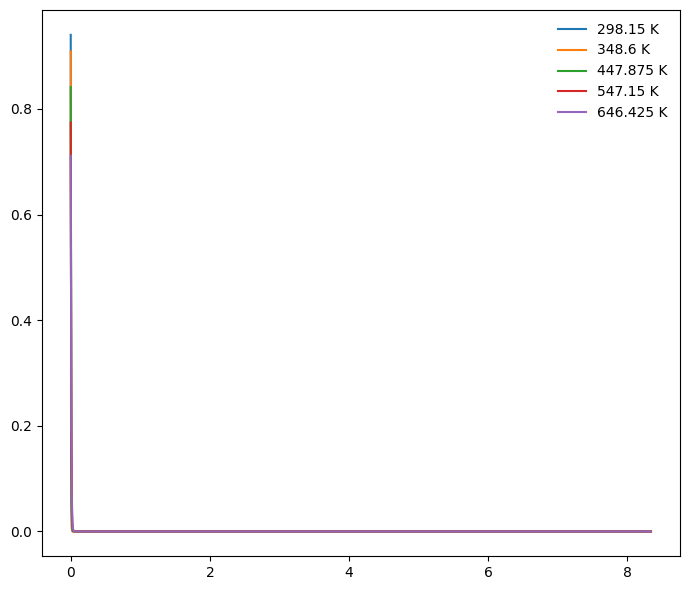

In [37]:
import numpy as np
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt

dir_path = db_paths[0][0]
db_path = f"{dir_path}/1_db/db_0.db"
db = Database(filename=db_path)
db.restore_to_memory()
traj = db.restore_to_trajectory()
num_points=1000

# Constants for Binding Energy
# E_slab = -195.463476  # eV
E_slab = -92.946489 # eV
mu_fe = -8.553673     # eV/atom
n_fe = 9              # Number of Fe atoms


# Calculate Binding Energy for each frame: E_b = E_total - (E_slab + n*mu)
binding_energies = np.array([
    # atoms.get_potential_energy() - (E_slab + n_fe * mu_fe) 
    # for atoms in traj if hasattr(atoms, 'get_potential_energy')
    atoms.get_potential_energy()
    for atoms in traj if hasattr(atoms, 'get_potential_energy')
])


# Use relative binding energy for KDE
min_eb = np.min(binding_energies)
relative_eb = binding_energies - min_eb

kde = gaussian_kde(relative_eb)
eb_grid = np.linspace(np.min(relative_eb), np.max(relative_eb), num_points)
eb_density = kde(eb_grid)
eb_density = eb_density/min(eb_density)

########################################

# Statistical Mechanics Loop
kB = 8.617333262e-5
temperatures = [298.15, 348.60, 447.875, 547.15, 646.425]
results = []

for T in temperatures:
    beta = 1.0 / (kB * T)
    
    # 1. Intensive Gibbs Level (per atom)
    G_levels = eb_grid - kB * T * np.log(eb_density + 1e-20)
    delta_G_intensive = G_levels - np.min(G_levels)
    
    # 2. Boltzmann weighting using EXTENSIVE energy (total cluster)
    # This is the critical fix:
    boltzmann_factors = np.exp(-beta * (delta_G_intensive * n_fe))
    
    # 3. Partition Function and Probability
    Z = np.sum(boltzmann_factors)
    P_Eb = boltzmann_factors / Z
    
    # 4. Total Ensemble Gibbs Free Energy
    G_total = -kB * T * np.log(Z) + (np.min(G_levels) * n_fe)
    
    results.append({
        'T': T, 
        'G_total': G_total, 
        'P': P_Eb, 
        'G_levels': G_levels
    })

# 3. Plotting with Mandatory Researcher Style
fig, ax = plt.subplots(figsize=(7, 6))

# Tick Parameters as requested
min_x, max_x = -4, 4
min_y, max_y = -2, 4
min_e, max_e = 0.0, 0.8

xticks = np.round(np.linspace(min_x, max_x, 5), 0)
yticks = np.round(np.linspace(min_y, max_y, 5), 1)
eticks = np.round(np.linspace(min_e, max_e, 10), 1)

# xticks_minor = (xticks[:-1] + xticks[1:]) / 2
# yticks_minor = (yticks[:-1] + yticks[1:]) / 2

# ax.set_xlabel('Principal Component 1') # Keeping labels per your style instructions
# ax.set_ylabel('Principal Component 2')
# ax.set_xlim(min_x, max_x)
# ax.set_ylim(min_y, max_y)
# ax.set_xticks(xticks)
# ax.set_yticks(yticks)
# ax.tick_params(labelsize=12)
# ax.xaxis.set_minor_locator(FixedLocator(xticks_minor))
# ax.yaxis.set_minor_locator(FixedLocator(yticks_minor))

# Note: Mapping eb_grid to the required visual range [-4, 4] for PC1 compliance
# Here we plot the Probability P(Eb) across the normalized grid
for res in results:
    # Scale eb_grid for visualization if necessary, or plot directly
    ax.plot(eb_grid, res['P'], label=f"{res['T']} K", lw=1.5)

ax.legend(frameon=False, loc='upper right')
plt.tight_layout()
plt.savefig('binding_probability_vs_temperature.png', dpi=300)
plt.show()

###  Prev

(Original) Probability State:

$$
p_i = \frac{\exp\left(-\frac{E_i}{k_B T}\right)}{Z}
$$

Boltzmann Factor of every accessable state:
$$
Z = \sum_{j} \exp\left(-\frac{E_j}{k_B T}\right)
$$

### **1. Kernel Density Estimation (KDE)**

We estimate the numerical **Density of States**, $g(E)$, by placing a Gaussian kernel over each observed energy point from your data:

$$g(E) = \frac{1}{Nh} \sum_{i=1}^{N} K \left( \frac{E - E_i}{h} \right)$$

Where:
- $N$ is the number of configurations.
- $h$ is the smoothing bandwidth.
- $K$ is the kernel function (Gaussian).
    

### **2. The Unnormalized Probability**

The probability of occupancy at a specific energy $E$ is the product of the available density of states and the **Boltzmann factor**:

$$P_{unnorm}(E) = g(E) \cdot \exp\left( -\frac{E}{k_B T} \right)$$

### **3. Sum-Normalization**

To treat the energy grid as a discrete set of states where the total probability equals 1, we normalize the distribution by the sum of all points $j$ on the grid:

$$P(E_j) = \frac{g(E_j) e^{-E_j / k_B T}}{\sum_{i=1}^{N} g(E_i) e^{-E_i / k_B T}}$$


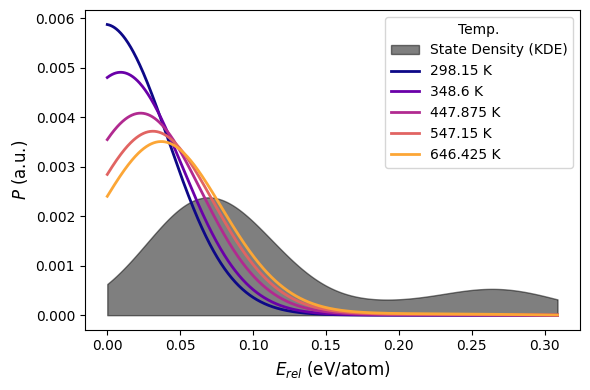

In [9]:
import numpy as np
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt

dir_path = db_paths[0][0]
db_path = f"{dir_path}/1_db/db_0.db"
db = Database(filename=db_path)
db.restore_to_memory()
traj = db.restore_to_trajectory()

energies = np.array([atoms.get_potential_energy()/len(atoms) for atoms in traj if hasattr(atoms, 'get_potential_energy')])

min_energy = np.min(energies)
relative_energies = energies - min_energy

# Constants
k_B = 1.380649e-23  # J/K
ev_to_j = 1.60218e-19

temperatures = [298.15, 348.60, 447.875, 547.15, 646.425]
# temperatures = np.linspace(298.15, 1046.425, 100)

def calculate_weighted_probability(relative_energies, temp, num_points=1000, plot_ratio=False):
    # 1. Fit the Energy Density (KDE)
    # This represents the density of states (how often an energy level appears)
    kde = gaussian_kde(relative_energies)
    
    # Create an energy grid for evaluation
    energy_grid = np.linspace(np.min(relative_energies), np.max(relative_energies), num_points)
    energy_density = kde(energy_grid)

    if plot_ratio:
        j = 0.04715
        k = 0
        idx_j = np.abs(energy_grid - j).argmin()
        idx_k = np.abs(energy_grid - k).argmin()

        Ej = energy_grid[idx_j]
        Ek = energy_grid[idx_k]

        g_Ej = energy_density[idx_j]
        g_Ek = energy_density[idx_k]

        energy_diff = Ej - Ek
        boltzmann_ratio = np.exp(-(energy_diff * ev_to_j) / (k_B * temp))
        ratio = (g_Ej / g_Ek) * boltzmann_ratio
        return energy_grid, energy_density, ratio

    
    # 2. Calculate Boltzmann Factors for the grid
    # We use the grid points to ensure the density and factors align
    boltzmann_factors = np.exp(-(energy_grid * ev_to_j) / (k_B * temp))
    
    # 3. Combine: Probability = Density of States * Boltzmann Occupancy
    # Unnormalized combined probability
    combined_prob_unnorm = energy_density * boltzmann_factors
    
    # 4. Normalize so the integral/sum equals 1
    # total_probability = np.trapz(combined_prob_unnorm, energy_grid)
    # final_probability_density = combined_prob_unnorm / total_probability

    final_probability_density = combined_prob_unnorm / np.sum(combined_prob_unnorm)
    energy_density = energy_density / np.sum(energy_density)

    avg_energy = np.sum(energy_grid * final_probability_density)

    
    # if plot_ratio:
    #     idx_ref = 0 
    #     E_k = energy_grid[idx_ref]
    #     g_Ek = energy_density[idx_ref]
        
        # ratio_all = []
        # for T in temp:
        #     # Calculate P(Ej) / P(Ek)
        #     # Ratio = (g_j / g_k) * exp(-(Ej - Ek) / kT)
        #     energy_diff = grid - E_k
        #     boltzmann_ratio = np.exp(-(energy_diff * ev_to_j) / (k_B * T))
        #     ratio = (energy_density / g_Ek) * boltzmann_ratio
        #     ratio_all.append(ratio)
            
    return energy_grid, final_probability_density, energy_density, avg_energy


plt.figure(figsize=(6, 4))

# ratio_all = []
# for i, temp in enumerate(temperatures):
#     # Use ratios
#     grid, prob_dist, ratio = calculate_weighted_probability(relative_energies, temp, plot_ratio=True)
#     ratio_all.append(ratio)

# plt.plot(temperatures,ratio_all)
# plt.show()

# We only need to plot the Raw Density once as a background
grid, _, raw_density_norm, _ = calculate_weighted_probability(relative_energies, temperatures[0])
plt.fill_between(grid, raw_density_norm, alpha=0.5, color='black', label='State Density (KDE)')

# Use a colormap to distinguish temperatures
colors = plt.cm.plasma(np.linspace(0, 0.8, len(temperatures)))

ratio_all = []
for i, temp in enumerate(temperatures):
    grid, prob_dist, _, avg_E = calculate_weighted_probability(relative_energies, temp)
    
    # Plot probability curve
    line, = plt.plot(grid, prob_dist, label=f'{temp} K', color=colors[i], linewidth=2)

    # Plot vertical line for <E> with same color
    # plt.axvline(avg_E, color=colors[i], linestyle='--', alpha=0.7, linewidth=1.5)
    
    # Annotate the average energy for clarity
    # plt.text(avg_E, np.max(prob_dist)*1.02, f'{avg_E:.3f}', 
    #          color=colors[i], horizontalalignment='center', fontsize=9)



plt.xlabel(r'$E_{rel}$ (eV/atom)', fontsize=12)
plt.ylabel('$P$ (a.u.)', fontsize=12)
# plt.title('Evolution of Energy Probability and Ensemble Average with Temperature', fontsize=14)
plt.legend(title="Temp.")
# plt.grid(True, alpha=0.2, linestyle='--')
# plt.ylim(0, 0.08) # Ensure y-axis starts at 0
# plt.xlim(0, 0.30) # Ensure y-axis starts at 0
plt.tight_layout()
plt.show()

The Mathematical RatioThe plot will visualize the following relationship as a function of temperature:

$$\frac{P(E_j)}{P(E_k)} = \frac{g(E_j)}{g(E_k)} \exp\left( -\frac{E_j - E_k}{k_B T} \right)$$

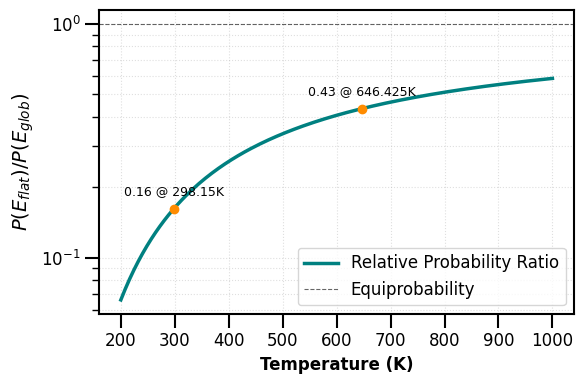

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Define a smoother range of temperatures for a clean curve
temp_range = np.linspace(200, 1000, 200) 

ratio_values = []
for t in temp_range:
    # Using your function with the plot_ratio=True flag
    _, _, ratio = calculate_weighted_probability(relative_energies, t, plot_ratio=True)
    ratio_values.append(ratio)

# --- Plot Construction ---
plt.figure(figsize=(6, 4), dpi=100)

# Main ratio curve
plt.plot(temp_range, ratio_values, color='teal', linewidth=2.5, label='Relative Probability Ratio')

# Reference values: specific points from your original list
for t_spec in [298.15, 646.425]:
    _, _, r_spec = calculate_weighted_probability(relative_energies, t_spec, plot_ratio=True)
    plt.scatter(t_spec, r_spec, color='darkorange', zorder=5)
    plt.annotate(f'{r_spec:.2f} @ {t_spec}K', (t_spec, r_spec), 
                 textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

# Formatting for Research
plt.yscale('log') # Probability ratios are best viewed on log scales
plt.xlabel('Temperature (K)', fontsize=12, fontweight='bold')
plt.ylabel(r'$P(E_{flat}) / P(E_{glob})$', fontsize=14, fontweight='bold')
# plt.title('Relative State Occupancy vs. Temperature', fontsize=14, pad=15)

# Adding a horizontal line at 1.0 (where states are equally likely)
plt.axhline(1, color='black', linewidth=0.8, linestyle='--', alpha=0.6, label='Equiprobability')

plt.grid(True, which="both", linestyle=':', alpha=0.4)
plt.legend(frameon=True, loc='lower right')
plt.tight_layout()

plt.show()

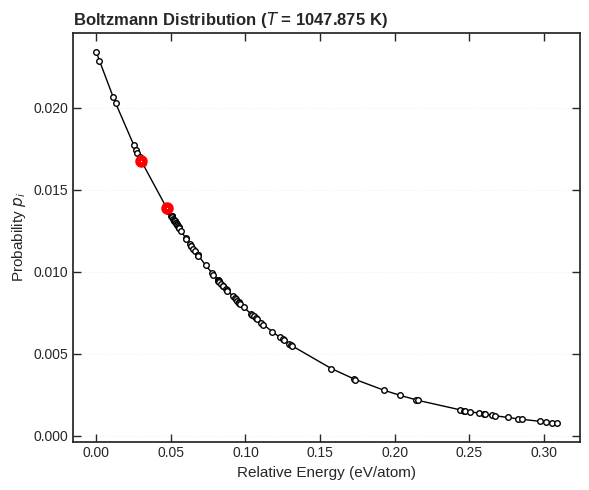

In [78]:
import numpy as np
import matplotlib.pyplot as plt
from agox.databases import Database
import matplotlib.ticker as ticker

# 1. Load Data
dir_path = db_paths[0][0]
db_path = f"{dir_path}/1_db/db_0.db"
db = Database(filename=db_path)
db.restore_to_memory()
traj = db.restore_to_trajectory()

# 2. Extract Energies (assumed to be in eV from AGOX)
energies = []
for atoms in traj:
    try:
        energies.append(atoms.get_potential_energy()/len(atoms))
    except Exception:
        continue 

energies = np.array(energies)

# 3. Process Energies (Relative to Ground State)
min_idx = np.argmin(energies)
min_energy = energies[min_idx]
relative_energies = energies - min_energy

# 4. Constants & Calculation
# Converting eV to Joules for the standard k_B value
ev_to_j = 1.60218e-19
k_B = 1.380649e-23  
# T = 298.15
T = 447.875
T = 1047.875
# T1 = 298.15
# T2 = 447.875

def calculate_probabilities(E_ev, temp):
    # Convert eV to Joules inside the exponential
    boltzmann_factors = np.exp(-(E_ev * ev_to_j) / (k_B * temp))
    Z = np.sum(boltzmann_factors)
    probabilities = boltzmann_factors / Z
    return probabilities, Z

probs, partition_Z = calculate_probabilities(relative_energies, T)
# probs_t1, partition_Z_t1 = calculate_probabilities(relative_energies, T1)
# probs_t2, partition_Z_t2 = calculate_probabilities(relative_energies, T2)

# 5. Sorting for a smooth Line Graph
# This ensures the line represents the probability distribution from lowest to highest energy
sort_idx = np.argsort(relative_energies)
sorted_relative_energies = relative_energies[sort_idx]
sorted_probs = probs[sort_idx]

# 6. Plotting
import matplotlib.pyplot as plt

# Using a clean style base
plt.style.use('seaborn-v0_8-white') 

fig, ax = plt.subplots(figsize=(6, 5)) # Square-ish ratios look better in papers
ax.plot(sorted_relative_energies, sorted_probs, 
        color='black', 
        marker='o', 
        markersize=4, 
        markerfacecolor='white', 
        markeredgewidth=1,
        linewidth=1, 
        label=f'T = {T} K',
        zorder=1)

ax.scatter(sorted_relative_energies[8], sorted_probs[8], 
           edgecolors='red', 
           facecolors='white', 
           marker='o', 
           s=16,  # s is marker size in points^2; 4^2 = 16
           linewidth=5, 
           label=f'T = {T} K',
           zorder=2)
ax.scatter(sorted_relative_energies[10], sorted_probs[10], 
           edgecolors='red', 
           facecolors='white', 
           marker='o', 
           s=16,  # s is marker size in points^2; 4^2 = 16
           linewidth=5, 
           label=f'T = {T} K',
           zorder=2)

# Minimalist Axis Styling
ax.set_xlabel('Relative Energy (eV/atom)', fontsize=11)
ax.set_ylabel(r'Probability $p_i$', fontsize=11)
# ax.set_yscale('log')

ax.tick_params(axis='both', which='major', direction='in', length=6, width=1, top=True, right=True)
# Minor ticks: Shorter, thinner, pointing IN
ax.tick_params(axis='both', which='minor', direction='in', length=3, width=0.8, top=True, right=True)

# Remove top and right spines (standard minimalist look)
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)

# Refined Grid (Only horizontal for readability, or very subtle)
ax.grid(axis='y', which='both', linestyle=':', alpha=0.3)
# ax.grid(True, which="major", axis="y", ls="-", alpha=0.2, color='gray')

# Title and Layout
ax.set_title(f'Boltzmann Distribution ($T$ = {T} K)', loc='left', fontsize=12, fontweight='bold')
plt.tight_layout()

# Save with high DPI for publications
# plt.savefig('boltzmann_plot.pdf', dpi=300, bbox_inches='tight')
plt.show()

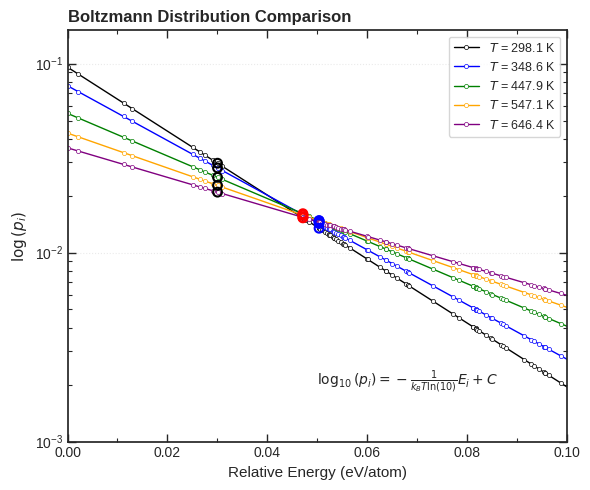

In [115]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from agox.databases import Database

# 1. Load Data
dir_path = db_paths[0][0]
db_path = f"{dir_path}/1_db/db_0.db"
db = Database(filename=db_path)
db.restore_to_memory()
traj = db.restore_to_trajectory()

# 2. Extract Energies per atom
energies = np.array([atoms.get_potential_energy()/len(atoms) for atoms in traj if hasattr(atoms, 'get_potential_energy')])

# 3. Process Energies (Relative to Ground State)
min_energy = np.min(energies)
relative_energies = energies - min_energy
sort_idx = np.argsort(relative_energies)
sorted_relative_energies = relative_energies[sort_idx]

# 4. Constants & Temperatures
ev_to_j = 1.60218e-19
k_B = 1.380649e-23  

temperatures = [298.15, 348.60, 447.875, 547.15, 646.425]
colors = ['black', 'blue', 'green', 'orange', 'purple']


def calculate_probabilities(E_ev, temp):
    boltzmann_factors = np.exp(-(E_ev * ev_to_j) / (k_B * temp))
    Z = np.sum(boltzmann_factors)
    return boltzmann_factors / Z

# 5. Plotting Setup
plt.style.use('seaborn-v0_8-white') 
fig, ax = plt.subplots(figsize=(6, 5))

# Loop through temperatures
for i, T in enumerate(temperatures):
    # Calculate
    probs = calculate_probabilities(relative_energies, T)
    sorted_probs = probs[sort_idx]
    
    # Line + Scatter Plot
    line_label = f'$T$ = {T:.1f} K'
    ax.plot(sorted_relative_energies, sorted_probs, 
            color=colors[i], 
            marker='o', markersize=3, markerfacecolor='white',
            markeredgewidth=0.5, linewidth=1, 
            label=line_label, zorder=1)

    # Highlight specific indices (e.g., 8 and 10) with red scatter
    # We only label the scatter once to avoid legend clutter
    sc_label = "Highlighted States" if i == 0 else ""
    highlight_idx = [8, 10, 16]
    # ax.scatter(sorted_relative_energies[highlight_idx[0]], sorted_probs[highlight_idx[0]], 
    #            edgecolors='blue', facecolors='none', marker='o', 
    #            s=40, linewidth=1.5, zorder=3, label=sc_label)
    # ax.scatter(sorted_relative_energies[highlight_idx[1]], sorted_probs[highlight_idx[1]], 
    #            edgecolors='red', facecolors='none', marker='o', 
    #            s=40, linewidth=1.5, zorder=3, label=sc_label)
    ax.scatter(sorted_relative_energies[highlight_idx[0]], sorted_probs[highlight_idx[0]], 
               edgecolors='black', facecolors='none', marker='o', 
               s=40, linewidth=1.5, zorder=3)
    ax.scatter(sorted_relative_energies[highlight_idx[1]], sorted_probs[highlight_idx[1]], 
               edgecolors='red', facecolors='none', marker='o', 
               s=40, linewidth=1.5, zorder=3)
    ax.scatter(sorted_relative_energies[highlight_idx[2]], sorted_probs[highlight_idx[2]], 
               edgecolors='blue', facecolors='none', marker='o', 
               s=40, linewidth=1.5, zorder=3)

# 6. Minimalist Research Styling
ax.set_yscale('log')
ax.set_xlabel('Relative Energy (eV/atom)', fontsize=11)
ax.set_ylabel(r'$\log{(p_i)}$', fontsize=11)

# Tickers (Major and Minor)
ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=10))
ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=10))
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))

ax.tick_params(axis='both', which='major', direction='in', length=6, width=1, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in', length=3, width=0.8, top=True, right=True)

# Grid and Legend
ax.grid(axis='y', which='major', linestyle=':', alpha=0.4)
ax.legend(frameon=True, fontsize=9, loc='upper right')

ax.set_xlim(0.0, 0.1)
ax.set_ylim(0.001, 0.15)

# Mathematical Note Annotation
ax.text(0.05, 0.002, r'$\log_{10}(p_i) = -\frac{1}{k_B T \ln(10)} E_i + C$', 
        fontsize=10, bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Title and Final Touches
ax.set_title('Boltzmann Distribution Comparison', loc='left', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

The Mathematical DerivationThe Boltzmann equation is:

$$
p_i = \frac{1}{Z} \exp\left(-\frac{E_i}{k_B T}\right)
$$

Taking the natural logarithm ($\ln$):

$$
\ln(p_i) = \underbrace{-\frac{1}{k_B T}}_{\text{gradient } m} E_i \underbrace{- \ln(Z)}_{\text{intercept } c}
$$

If you use $\log_{10}$ (as in your plot):

$$
\log_{10}(p_i) = \underbrace{-\frac{1}{k_B T \ln(10)}}_{m} E_i \underbrace{- \log_{10}(Z)}_{c}
$$

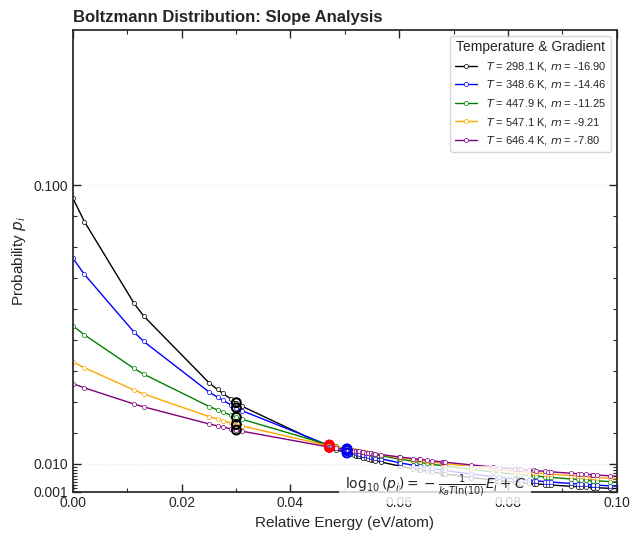

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from agox.databases import Database

# 1. Load Data
dir_path = db_paths[0][0]
db_path = f"{dir_path}/1_db/db_0.db"
db = Database(filename=db_path)
db.restore_to_memory()
traj = db.restore_to_trajectory()

# 2. Extract Energies per atom
energies = np.array([atoms.get_potential_energy()/len(atoms) for atoms in traj if hasattr(atoms, 'get_potential_energy')])

# 3. Process Energies (Relative to Ground State)
min_energy = np.min(energies)
relative_energies = energies - min_energy
sort_idx = np.argsort(relative_energies)
sorted_relative_energies = relative_energies[sort_idx]

# 4. Constants & Temperatures
ev_to_j = 1.60218e-19
k_B = 1.380649e-23  

temperatures = [298.15, 348.60, 447.875, 547.15, 646.425]
colors = ['black', 'blue', 'green', 'orange', 'purple']

def calculate_probabilities(E_ev, temp):
    boltzmann_factors = np.exp(-(E_ev * ev_to_j) / (k_B * temp))
    Z = np.sum(boltzmann_factors)
    return boltzmann_factors / Z

# 5. Plotting Setup
plt.style.use('seaborn-v0_8-white') 
fig, ax = plt.subplots(figsize=(6.5, 5.5))

# Loop through temperatures
for i, T in enumerate(temperatures):
    # Calculate
    probs = calculate_probabilities(relative_energies, T)
    sorted_probs = probs[sort_idx]
    
    # CALCULATE GRADIENT (m)
    # We fit log10(p) = m * E + c
    log_p = np.log10(sorted_probs)
    m, c = np.polyfit(sorted_relative_energies, log_p, 1)
    
    # Line + Scatter Plot - Label now includes gradient m
    line_label = f'$T$ = {T:.1f} K, $m$ = {m:.2f}'
    ax.plot(sorted_relative_energies, sorted_probs, 
            color=colors[i], 
            marker='o', markersize=3, markerfacecolor='white',
            markeredgewidth=0.5, linewidth=1, 
            label=line_label, zorder=1)

    # Highlight specific indices
    highlight_idx = [8, 10, 16]
    ax.scatter(sorted_relative_energies[highlight_idx[0]], sorted_probs[highlight_idx[0]], 
               edgecolors='black', facecolors='none', marker='o', s=40, linewidth=1.5, zorder=3)
    ax.scatter(sorted_relative_energies[highlight_idx[1]], sorted_probs[highlight_idx[1]], 
               edgecolors='red', facecolors='none', marker='o', s=40, linewidth=1.5, zorder=3)
    ax.scatter(sorted_relative_energies[highlight_idx[2]], sorted_probs[highlight_idx[2]], 
               edgecolors='blue', facecolors='none', marker='o', s=40, linewidth=1.5, zorder=3)

# 6. Minimalist Research Styling
# ax.set_yscale('log')
ax.set_xlabel('Relative Energy (eV/atom)', fontsize=11)
ax.set_ylabel(r'Probability $p_i$', fontsize=11)

# Tickers
ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=10))
ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=10))
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))

ax.tick_params(axis='both', which='major', direction='in', length=6, width=1, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in', length=3, width=0.8, top=True, right=True)

# Grid and Legend
ax.grid(axis='y', which='major', linestyle=':', alpha=0.4)
ax.legend(frameon=True, fontsize=8, loc='upper right', title="Temperature & Gradient")

ax.set_xlim(0.0, 0.1)
ax.set_ylim(0.001, 0.15)

# Mathematical Note Annotation
ax.text(0.05, 0.002, r'$\log_{10}(p_i) = -\frac{1}{k_B T \ln(10)} E_i + C$', 
        fontsize=10, bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Title
ax.set_title('Boltzmann Distribution: Slope Analysis', loc='left', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## database

In [ ]:
from typing import Optional, List, Dict
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ase.io import write
from agox.databases import Database
from scripts.calculate_relative_energy import calculate_relative_energy
from matplotlib.ticker import AutoMinorLocator

def process_database(
    dir_path: str,
    file_idx: int,
    dir_out: str,
    dir_xsf_traj: str,
    dir_xsf: str,
    plot_best_so_far: bool = True,
    plot_by_seed: bool = True ,
    save_individual_trajectories: bool = True, 
    figsize =(6, 3.5),
    custom_max_x: Optional[float] = None,  
    custom_max_y: Optional[float] = None,  
) -> None:
    """
    Extracts trajectory data. Seeds are renamed to start at 0 sequentially 
    for cleaner labeling.
    """
    root = Path(dir_path)
    # Sort seeds naturally by name
    seed_dirs = sorted(root.glob("seed_*"), key=lambda x: int(x.name.split('_')[-1]) if x.name.split('_')[-1].isdigit() else x.name)
    
    seed_data: Dict[str, List] = {}

    if not seed_dirs:
        db_path = root / "1_db" / "db_0.db"
        if db_path.exists():
            db = Database(filename=str(db_path))
            db.restore_to_memory()
            seed_data["Seed 0"] = db.restore_to_trajectory()
    else:
        # Renaming logic: Always start from 0 based on the order found
        for i, p in enumerate(seed_dirs):
            seed_num = p.name.split('_')[-1]
            db_path = p / "1_db" / f"db_{seed_num}.db"
            if db_path.exists():
                db = Database(filename=str(db_path))
                db.restore_to_memory()
                # Create a standardized name: "Seed 0", "Seed 1", etc.
                seed_data[f"Seed {i}"] = db.restore_to_trajectory()

    # Flatten for combined files
    all_traj = []
    # Using sorted keys ensures we process Seed 0, Seed 1, etc., in order
    sorted_seed_names = sorted(seed_data.keys(), key=lambda x: int(x.split()[-1]))
    for s_name in sorted_seed_names:
        all_traj.extend(seed_data[s_name])

    if not all_traj:
        return

    # Setup directories
    out_base = Path(dir_out)
    traj_dir = out_base / dir_xsf_traj
    xsf_dir = out_base / dir_xsf / str(file_idx)
    traj_dir.mkdir(parents=True, exist_ok=True)
    xsf_dir.mkdir(parents=True, exist_ok=True)

    # Save trajectories and CSV
    write(traj_dir / f"traj_{file_idx}.xsf", all_traj)
    write(traj_dir / f"traj_{file_idx}.traj", all_traj)

    if save_individual_trajectories:
        seed_traj_dir = traj_dir / "seeds"
        seed_traj_dir.mkdir(exist_ok=True)
        for s_name, s_traj in seed_data.items():
            clean_name = s_name.lower().replace(" ", "_")
            write(seed_traj_dir / f"{file_idx}_{clean_name}.traj", s_traj)
            write(seed_traj_dir / f"{file_idx}_{clean_name}.xsf", s_traj)
    
    energies, _, rel_e, rel_e_atom = calculate_relative_energy(all_traj)

    df = pd.DataFrame({
        "index": range(len(all_traj)),
        "energy": energies,
        "relative_energy": rel_e,
        "relative_energy_per_atom": rel_e_atom
    })
    df.to_csv(out_base / f"data_{file_idx}.csv", index=False)

    # Individual XSF saving
    for i, frame in enumerate(all_traj):
        frame_i = frame.copy()
        for key in ["initial_magmoms", "magmoms"]:
            frame_i.arrays.pop(key, None)
        write(xsf_dir / f"struct_{i}.xsf", frame_i)

    # --- Best-So-Far Plotting ---
    if plot_best_so_far:
        fig, ax = plt.subplots(figsize=figsize)
        max_y = 0
        max_x = 0

        if plot_by_seed:
            num_seeds = len(sorted_seed_names)
            cmap = plt.get_cmap('tab10')
            for i, s_name in enumerate(sorted_seed_names):
                s_traj = seed_data[s_name]
                _, _, _, s_rel_e_atom = calculate_relative_energy(s_traj)
                s_best_so_far = np.minimum.accumulate(s_rel_e_atom)
                
                # --- Specific Color Logic ---
                if i == 0:
                    current_color = 'black'
                    linewidth = 2.0  # Slightly thicker to emphasize Seed 0
                    zorder = 50      # Ensures Seed 0 is drawn on top of others
                else:
                    # Offset the color index so we don't waste the first cmap color
                    current_color = cmap((i-1) % 10) 
                    linewidth = 1.5
                    zorder = 1

                ax.plot(range(len(s_best_so_far)), s_best_so_far, 
                        label=s_name, lw=linewidth, color=current_color, zorder=zorder)
                
                max_y = max(max_y, np.max(s_rel_e_atom))
                max_x = max(max_x, len(s_best_so_far))
        else:
            best_so_far = np.minimum.accumulate(rel_e_atom)
            ax.plot(range(len(best_so_far)), best_so_far, color='black', lw=2, label='Combined')
            max_y = np.max(rel_e_atom)
            max_x = len(best_so_far)

        # Formatting
        ax.set_xlabel('Evaluated Candidates')
        ax.set_ylabel(r'$E_{i}-E_{glob}$ (eV/atom)')

        final_xlim = custom_max_x if custom_max_x is not None else max_x
        final_ylim = custom_max_y if custom_max_y is not None else max_y * 1.1

        ax.set_xlim(0, final_xlim)
        ax.set_ylim(0, final_ylim)
        
        ax.xaxis.set_minor_locator(AutoMinorLocator())
        ax.yaxis.set_minor_locator(AutoMinorLocator())

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        ax.tick_params(
            axis='both',          # Apply to both x and y axes
            which='both',         # Apply to both major and minor ticks
            top=False,            # Turn off ticks on the top
            right=False,          # Turn off ticks on the right
            labeltop=False,       # Turn off labels on the top
            labelright=False      # Turn off labels on the right
        )

        if plot_by_seed:
            ax.legend(
                loc='upper left', 
                fontsize=9, 
                ncol=1, 
                frameon=True,
                bbox_to_anchor=(1.02, 1),
                borderaxespad=0.,
            )
            
        plt.tight_layout()
        
        plot_path = out_base / "progression_plots"
        plot_path.mkdir(exist_ok=True)
        plt.savefig(plot_path / f"progression_seed_split_{file_idx}.png", dpi=300)
        plt.show()
        plt.close(fig)

In [ ]:
def process_database(
    dir_path: str,
    file_idx: int,
    dir_out: str,
    dir_xsf_traj: str,
    dir_xsf: str,
    plot_best_so_far: bool = True,
    plot_by_seed: bool = True,
    figsize=(6, 3.5),
    show_legend: bool = False,  # Added as parameter
) -> None:
    """
    Extracts trajectory data. Seeds are renamed to start at 0 sequentially 
    for cleaner labeling.
    """
    root = Path(dir_path)
    # Sort seeds naturally by name
    seed_dirs = sorted(root.glob("seed_*"), key=lambda x: int(x.name.split('_')[-1]) if x.name.split('_')[-1].isdigit() else x.name)
    
    seed_data: Dict[str, List] = {}

    if not seed_dirs:
        db_path = root / "1_db" / "db_0.db"
        if db_path.exists():
            db = Database(filename=str(db_path))
            db.restore_to_memory()
            seed_data["Seed 0"] = db.restore_to_trajectory()
    else:
        for i, p in enumerate(seed_dirs):
            seed_num = p.name.split('_')[-1]
            db_path = p / "1_db" / f"db_{seed_num}.db"
            if db_path.exists():
                db = Database(filename=str(db_path))
                db.restore_to_memory()
                seed_data[f"Seed {i}"] = db.restore_to_trajectory()

    all_traj = []
    sorted_seed_names = sorted(seed_data.keys(), key=lambda x: int(x.split()[-1]))
    for s_name in sorted_seed_names:
        all_traj.extend(seed_data[s_name])

    if not all_traj:
        return

    out_base = Path(dir_out)
    traj_dir = out_base / dir_xsf_traj
    xsf_dir = out_base / dir_xsf / str(file_idx)
    traj_dir.mkdir(parents=True, exist_ok=True)
    xsf_dir.mkdir(parents=True, exist_ok=True)

    write(traj_dir / f"traj_{file_idx}.xsf", all_traj)
    write(traj_dir / f"traj_{file_idx}.traj", all_traj)
    energies, _, rel_e, rel_e_atom = calculate_relative_energy(all_traj)

    df = pd.DataFrame({
        "index": range(len(all_traj)),
        "energy": energies,
        "relative_energy": rel_e,
        "relative_energy_per_atom": rel_e_atom
    })
    df.to_csv(out_base / f"data_{file_idx}.csv", index=False)

    for i, frame in enumerate(all_traj):
        frame_i = frame.copy()
        for key in ["initial_magmoms", "magmoms"]:
            frame_i.arrays.pop(key, None)
        write(xsf_dir / f"struct_{i}.xsf", frame_i)

    # --- Best-So-Far Plotting ---
    if plot_best_so_far:
        fig, ax = plt.subplots(figsize=figsize)
        max_y = 0
        max_x = 0

        if plot_by_seed:
            cmap = plt.get_cmap('tab10')
            for i, s_name in enumerate(sorted_seed_names):
                s_traj = seed_data[s_name]
                _, _, _, s_rel_e_atom = calculate_relative_energy(s_traj)
                s_best_so_far = np.minimum.accumulate(s_rel_e_atom)
                
                if i == 0:
                    current_color = 'black'
                    linewidth = 2.0  
                    zorder = 50      
                else:
                    current_color = cmap((i-1) % 10) 
                    linewidth = 1.5
                    zorder = 1

                ax.plot(range(len(s_best_so_far)), s_best_so_far, 
                        label=s_name, lw=linewidth, color=current_color, zorder=zorder)
                
                max_y = max(max_y, np.max(s_rel_e_atom))
                max_x = max(max_x, len(s_best_so_far))
        else:
            best_so_far = np.minimum.accumulate(rel_e_atom)
            ax.plot(range(len(best_so_far)), best_so_far, color='black', lw=2, label='Combined')
            max_y = np.max(rel_e_atom)
            max_x = len(best_so_far)

        # Formatting
        ax.set_xlabel('Evaluated Candidates')
        ax.set_ylabel(r'$E_{i}-E_{glob}$ (eV/atom)')
        ax.set_xlim(0, max_x)
        ax.set_ylim(0, max_y * 1.1)
        
        ax.xaxis.set_minor_locator(AutoMinorLocator())
        ax.yaxis.set_minor_locator(AutoMinorLocator())

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        ax.tick_params(axis='both', which='both', top=False, right=False)

        # Updated Legend Logic
        if show_legend:
            ax.legend(
                loc='upper left', 
                fontsize=9, 
                ncol=1, 
                frameon=True,
                bbox_to_anchor=(1.02, 1),
                borderaxespad=0.,
            )
            
        plt.tight_layout()
        
        plot_path = out_base / "progression_plots"
        plot_path.mkdir(exist_ok=True)
        plt.savefig(plot_path / f"progression_seed_split_{file_idx}.png", dpi=300)
        plt.show()
        plt.close(fig)

## coverage:

Technical Breakdown, $5 \times 5$ unit cell has 25 atoms per monolayer:Each 5 atoms added represents an increase of 0.2 ML.The coverage $\theta$ is calculated as:$$\theta = 1.0 + \frac{N_{added}}{25}$$

## pes

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Reproducibility
np.random.seed(42)

# Control parameter
complexity = 3 

# 1. Define the parameterized PES function
def complex_potential_surface(x, complexity_factor=0.5):
    y = 0.45 
    primary_valleys = [
        (2.0, 0.45, 0.7), (4.8, 0.35, 0.6), 
        (7.5, 0.40, 0.8), (10.5, 0.28, 0.5)
    ]
    local_valleys = [
        (1.2, 0.1, 0.2), (2.8, 0.08, 0.15), (4.0, 0.15, 0.25), 
        (5.5, 0.12, 0.2), (6.5, 0.2, 0.3), (8.5, 0.18, 0.25),
        (9.5, 0.1, 0.2), (11.2, 0.05, 0.1)
    ]
    for pos, depth, width in primary_valleys:
        y -= depth * np.exp(-((x - pos)**2) / (2 * width**2))
    for pos, depth, width in local_valleys:
        y -= (depth * complexity_factor) * np.exp(-((x - pos)**2) / (2 * width**2))
    y += (0.015 * complexity_factor) * np.sin(2 * np.pi * x * 1.5)
    return y

# 2. Sampling
x_range = np.linspace(0.2, 12, 1500)
x_minima = [1.2, 2.0, 2.8, 4.0, 4.8, 5.5, 6.5, 7.5, 8.5, 9.5, 10.5, 11.2]
x_extra = [np.random.normal(xm, 0.12, 100) for xm in x_minima]
X_eigen = np.sort(np.concatenate([x_range] + x_extra))

# 3. Apply Energies and Normalize
raw_energies = complex_potential_surface(X_eigen, complexity) + np.random.exponential(0.006, len(X_eigen))
offset = np.min(raw_energies)
energies = raw_energies - offset

# 4. Generate Smooth Line Data
x_line = np.linspace(0.5, 11.5, 1000)
y_line = complex_potential_surface(x_line, complexity) - offset

# 5. Create the plot
fig, ax = plt.subplots(figsize=(5, 3), dpi=120)

# Clean scatter
ax.scatter(X_eigen, energies, s=10, facecolors='white', edgecolors='black', 
            linewidth=0.5, alpha=0.3, zorder=2)

# Line Graph
ax.plot(x_line, y_line, color='black', linewidth=1.5, alpha=0.8, zorder=1)

# --- REMOVE AXIS ENTIRELY ---
ax.axis('off')

# Ensure consistent framing
ax.set_ylim(-0.05, 1.0) 
ax.set_xlim(0.5, 11.5)

plt.tight_layout()
plt.show()

## probability; density

In [ ]:
"""
AGOX Data Analysis: Energy Distributions and Thermal Statistics
---------------------------------------------------------------
1. plot_energy_distribution: Versatile box/KDE plotting for database comparison.
2. calculate_weighted_probability: Thermodynamic weighting of State Density.
3. Temperature Sweep: Visualization of probability shift with T.
"""

import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from agox.databases import Database
from scripts.calculate_relative_energy import calculate_relative_energy

# --- Constants ---
K_B = 1.380649e-23     # J/K
EV_TO_J = 1.60218e-19  # Conversion factor

# =============================================================================
# 1. ENSEMBLE VISUALIZATION TOOLS
# =============================================================================

def plot_energy_distribution(
        db_paths, labels, dir_out, dir_im,
        figsize=(4, 6),
        y_label=r'$E_{rel}$ (eV/atom)',
        x_label='State Density',
        colors=None,
        plot_single=False,
        single_index=0,
        linewidth=2.2,
        plot_type="box",  # "box" or "density"
        x_lim=(None, None, None),
        y_lim=(None, None, None),
        show_legend=True
    ):
    """
    Plots energy distributions from multiple databases as Box Plots or KDEs.
    """
    # Standard Publication-Style Formatting
    params = {
        'font.size': 10,
        'font.family': 'sans-serif',
        'mathtext.fontset': 'cm',
        'xtick.direction': 'in',
        'ytick.direction': 'in',
        'axes.linewidth': linewidth,
        'xtick.major.width': linewidth,
        'ytick.major.width': linewidth,
    }
    plt.rcParams.update(params)
    plt.figure(figsize=figsize, dpi=300)

    indices = [single_index] if plot_single else range(len(db_paths))

    for idx in indices:
        # Load Database
        dir_path, _ = db_paths[idx]
        db_file = os.path.join(dir_path, "1_db", "db_0.db")
        db = Database(filename=db_file)
        trajs = db.restore_to_trajectory()
        
        # Calculate Relative Energies (eV/atom)
        _, _, _, rel_energies = calculate_relative_energy(trajs)
        rel_energies = np.array(rel_energies)
        color = colors[idx % len(colors)] if colors else "lightgray"

        if plot_type == "box":
            plt.boxplot(
                rel_energies, positions=[idx + 1], patch_artist=True,
                boxprops=dict(facecolor=color, linewidth=linewidth),
                medianprops=dict(color='black', linewidth=linewidth)
            )
        else:
            # KDE Density Plot
            ys = np.sort(rel_energies)
            kde = gaussian_kde(ys)
            density_y = np.linspace(ys.min(), ys.max(), 300)
            density_x = kde(density_y)
            plt.plot(density_x, density_y, color=color, linewidth=linewidth)
            plt.fill_betweenx(density_y, 0, density_x, color=color, alpha=0.1)

    # Axis Styling
    plt.ylabel(y_label)
    if plot_type == "density": plt.xlabel(x_label)
    else: plt.xticks([i + 1 for i in indices], [labels[i] for i in indices], rotation=45)

    # Set Limits
    if x_lim[0] is not None: plt.xlim(x_lim[0:2])
    if y_lim[0] is not None: plt.ylim(y_lim[0:2])

    plt.tight_layout()
    plt.show()

# =============================================================================
# 2. THERMODYNAMIC PROBABILITY CALCULATIONS
# =============================================================================

def calculate_weighted_probability(relative_energies, temp, num_points=1000):
    """
    Calculates Boltzmann-weighted probability density from a KDE of the energy.
    Probability = Density of States * Boltzmann Occupancy
    """
    # 1. Density of States (KDE)
    kde = gaussian_kde(relative_energies)
    energy_grid = np.linspace(np.min(relative_energies), np.max(relative_energies), num_points)
    energy_density = kde(energy_grid)
    
    # 2. Boltzmann Factors
    boltzmann_factors = np.exp(-(energy_grid * EV_TO_J) / (K_B * temp))
    
    # 3. Combine and Normalize
    combined_prob_unnorm = energy_density * boltzmann_factors
    final_prob = combined_prob_unnorm / np.sum(combined_prob_unnorm)
    raw_density_norm = energy_density / np.sum(energy_density)

    # 4. Ensemble Average <E>
    avg_energy = np.sum(energy_grid * final_prob)
    
    return energy_grid, final_prob, raw_density_norm, avg_energy

# =============================================================================
# 3. EXECUTION: TEMPERATURE SWEEP VISUALIZATION
# =============================================================================

# Example setup for a single database (Index 3)
target_db = db_paths[3][0]
db = Database(filename=f"{target_db}/1_db/db_0.db")
traj = db.restore_to_trajectory()

# Extract per-atom relative energies
energies = np.array([a.get_potential_energy()/len(a) for a in traj if hasattr(a, 'get_potential_energy')])
rel_energies = energies - np.min(energies)

# Parameters
temperatures = [298.15, 348.60, 447.875, 547.15, 646.425]
colors = plt.cm.plasma(np.linspace(0, 0.8, len(temperatures)))

plt.figure(figsize=(10, 6))

# Plot underlying State Density
grid, _, raw_density, _ = calculate_weighted_probability(rel_energies, temperatures[0])
plt.fill_between(grid, raw_density, alpha=0.15, color='gray', label='State Density (KDE)')

# Plot Thermalized Distributions
for i, T in enumerate(temperatures):
    grid, prob_dist, _, avg_E = calculate_weighted_probability(rel_energies, T)
    
    plt.plot(grid, prob_dist, label=f'{T} K', color=colors[i], linewidth=2)
    plt.axvline(avg_E, color=colors[i], linestyle='--', alpha=0.7)
    
    # Annotate <E>
    plt.text(avg_E, np.max(prob_dist)*1.02, f'{avg_E:.3f}', 
             color=colors[i], ha='center', fontsize=9)

plt.xlabel('Relative Energy (eV/atom)')
plt.ylabel('Probability ($P_i$)')
plt.legend(title="Temperature")
plt.grid(True, alpha=0.2, linestyle='--')
plt.ylim(0, None)
plt.tight_layout()
plt.show()

## amorph

In [ ]:
"""
AGOX Workflow: Amorphous Ta–B Bulk Optimization
-----------------------------------------------
1. Builds a periodic Ta supercell with dilute B concentration.
2. Initializes an AGOX environment with periodic confinement.
3. Uses GPR with a Fingerprint descriptor as a surrogate model.
4. Generates candidates via Amorphous randomization, Permutation, and Rattle.
5. Performs Bayesian optimization (UCB) with GPAW (LCAO) as the true evaluator.
"""

import os
import numpy as np
import ray
from ase import Atoms
from ase.build import bulk
from ase.io import write

# AGOX Core Imports
from agox import AGOX
from agox.environments import Environment
from agox.generators import RattleGenerator, PermutationGenerator
from agox.samplers import KMeansSampler, FixedSampler
from agox.collectors import StandardCollector
from agox.acquisitors import LowerConfidenceBoundAcquisitor
from agox.postprocessors import RelaxPostprocess
from agox.evaluators import LocalOptimizationEvaluator
from agox.databases import Database
from agox.models.descriptors.fingerprint import Fingerprint
from agox.models.GPR import GPR
from agox.models.GPR.kernels import RBF, Noise, Constant as C
from agox.models.GPR.priors import Repulsive
from agox.helpers import SubprocessGPAW

# Custom/Project-specific Imports
from scripts.amorph_struct_randomize import AmorphStructRandomize
from scripts.add_B_concentration import add_B_concentration
from gpaw import FermiDirac

# =============================================================================
# 1. GLOBAL PARAMETERS & DIRECTORIES
# =============================================================================
a_ta = 3.30             # Ta bcc lattice constant (Å)
scale_cell = 1.05       # Slight expansion (+5%) for amorphous headroom
supercell_size = (3, 3, 3)
kpts_grid = (3, 3, 3)
cB = 0.04               # Target Boron concentration
N_iterations = 100      # Total AGOX optimization steps
ncores = 1              # MPI cores per GPAW task

# Setup output directory structure
path_result = "0_simul"
paths = [path_result, f"{path_result}/0_xsf", f"{path_result}/1_fig", f"{path_result}/1_db"]
for p in paths:
    os.makedirs(p, exist_ok=True)

# =============================================================================
# 2. STRUCTURE BUILDING & ENVIRONMENT
# =============================================================================
# Build the base Ta supercell
ta_bulk = bulk("Ta", "bcc", a=a_ta, cubic=True) * supercell_size
ta_bulk.set_cell(ta_bulk.cell * scale_cell, scale_atoms=True)

# Define template (empty cell for AGOX)
template = Atoms("", cell=ta_bulk.cell.copy(), pbc=True)

# Inject Boron atoms based on concentration
tab_bulk, n_b, n_ta = add_B_concentration(ta_bulk, cB=cB, make_structure=True)

# Set up the search space environment
environment = Environment(
    template=template,
    symbols=tab_bulk.get_chemical_formula(),
    confinement_cell=template.cell.copy(),
    confinement_corner=np.array([0, 0, 0]),
    box_constraint_pbc=[True, True, True],
)

# =============================================================================
# 3. SEARCH STRATEGY (GENERATORS & SAMPLERS)
# =============================================================================
n_atoms = len(ta_bulk)

generators = [
    # Primary: Complete randomization into amorphous state
    AmorphStructRandomize(
        **environment.get_confinement(),
        amorph=tab_bulk,
        rattle_amplitude=1.5,
        n_rattle=n_atoms,
        generate_pristine=False,
    ),
    # Secondary: Swap Ta and B positions
    PermutationGenerator(
        **environment.get_confinement(),
        max_number_of_swaps=1,
        rattle_strength=1.0,
    ),
    # Tertiary: Small local displacements
    RattleGenerator(
        **environment.get_confinement(),
        n_rattle=int(0.7 * n_atoms),
        rattle_amplitude=2.3,
    ),
]

# Database for storing calculated structures
database = Database(filename=f"{path_result}/1_db/db_0.db", order=5)

# =============================================================================
# 4. SURROGATE MODEL (GPR)
# =============================================================================
descriptor = Fingerprint(environment=environment)

# Kernel setup: Composite RBF with noise and scaling
beta = 0.01
k_base = (C(beta, (beta, beta)) * RBF()) + (C(1 - beta, (1 - beta, 1 - beta)) * RBF())
kernel = C(5000, (1, 1e5)) * k_base + Noise(0.01, (0.01, 0.01))

model = GPR(
    descriptor=descriptor,
    kernel=kernel,
    database=database,
    prior=Repulsive(),  # Prior to prevent atoms from overlapping
    use_ray=False
)

# =============================================================================
# 5. AGOX COMPONENTS (COLLECTOR, RELAXER, EVALUATOR)
# =============================================================================
sampler = KMeansSampler(descriptor=descriptor, database=database, sample_size=10)

# Diversity-driven candidate collection
num_candidates = {0: [10, 0, 0], 10: [5, 5, 0], 25: [0, 5, 5]}
collector = StandardCollector(
    generators=generators,
    sampler=sampler,
    environment=environment,
    num_candidates=num_candidates,
    order=1,
)

# Bayesian Acquisition (LCB)
acquisitor = LowerConfidenceBoundAcquisitor(model=model, kappa=2, order=3)

# Surrogate Relaxation: Relax candidates on the GPR surface before DFT evaluation
relaxer = RelaxPostprocess(
    model=acquisitor.get_acquisition_calculator(),
    optimizer_run_kwargs={"fmax": 0.05, "steps": 200},
    constraints=environment.get_constraints(),
    start_relax=10,
    order=2,
)

# DFT Evaluator: High-fidelity calculations with GPAW
calc = SubprocessGPAW(
    ncores=ncores,
    mode={"name": "lcao"},
    basis="dzp",
    xc="PBE",
    h=0.22,
    kpts={'size': kpts_grid, 'gamma': True},
    occupations=FermiDirac(0.1),
    convergence={'energy': 1e-6, 'density': 1e-4},
    symmetry={'point_group': False},
    maxiter=100,
    txt="gpaw_eval.txt",
)

evaluator = LocalOptimizationEvaluator(
    calc,
    gets={"get_key": "prioritized_candidates"},
    optimizer_kwargs={"logfile": None},
    optimizer_run_kwargs={"fmax": 0.05, "steps": 1},
    constraints=environment.get_constraints(),
    order=4,
)

# =============================================================================
# 6. EXECUTION
# =============================================================================
agox = AGOX(
    collector,
    relaxer,
    acquisitor,
    evaluator,
    database,
    seed=1,
)

agox.run(N_iterations=N_iterations)

## Vibrational

In [ ]:
"""
Quantification of the Fe/MgO(001) ensemble free energy.
Calculates configuration-specific Helmholtz Free Energies and the 
total ensemble free energy G_total at a given temperature.
"""

import os
import numpy as np
import pandas as pd
from ase.io import read
from ase.vibrations import Vibrations
from ase.thermochemistry import HarmonicThermo
from ase.units import kB
from gpaw import GPAW

def calculate_f_vib_from_traj(traj_file, temperature, gpaw_params, output_name="vibrational_data"):
    # 1. Initialization
    configs = read(traj_file, index=':')
    f_vib_list = []
    data_log = []
    
    # Pre-calculate beta for ensemble math
    beta = 1.0 / (kB * temperature)

    # 2. Iterate through ensemble configurations
    for i, atoms in enumerate(configs):
        # Set up GPAW calculator
        calc = GPAW(**gpaw_params)
        atoms.calc = calc
        
        # Calculate Potential Energy (H_0K)
        potential_energy = atoms.get_potential_energy()
        
        # Harmonic vibrational analysis
        name = f'vib_tmp_{i}'
        vib = Vibrations(atoms, name=name)
        vib.run()
        vib_energies = vib.get_energies()
        
        # Calculate Helmholtz Free Energy: F_i(T) = E_pot + F_vib(T)
        thermo = HarmonicThermo(vib_energies=vib_energies, 
                                potential_energy=potential_energy)
        
        f_i = thermo.get_helmholtz_free_energy(temperature=temperature)
        f_vib_list.append(f_i)

        # Log individual configuration data
        data_log.append({
            'Config_Index': i,
            'Temperature_K': temperature,
            'Potential_Energy_eV': potential_energy,
            'Helmholtz_Free_Energy_F_eV': f_i
        })
        
        # Cleanup temporary vibration files and directories
        vib.clean()
        if os.path.exists(name):
            import shutil
            shutil.rmtree(name)

    # 3. Ensemble Statistics (Partition Function math)
    f_vibs = np.array(f_vib_list)
    f_min = np.min(f_vibs)
    
    # Calculate G_total = -kBT * ln(sum(exp(-beta * (F_i - F_min)))) + F_min
    # Subtracting F_min prevents exponential overflow/underflow
    z_relative = np.sum(np.exp(-beta * (f_vibs - f_min)))
    g_total = f_min - (kB * temperature * np.log(z_relative))

    # 4. Save Results
    pd.DataFrame(data_log).to_csv(f"{output_name}_configs.csv", index=False)
    
    df_summary = pd.DataFrame([{
        'Temperature_K': temperature,
        'G_total_ensemble_eV': g_total,
        'F_min_eV': f_min,
        'Num_Configurations': len(f_vibs)
    }])
    df_summary.to_csv(f"{output_name}_summary.csv", index=False)
    
    return f_vibs, g_total

# --- Execution ---
# Ensure your path variables (dir_out, etc.) are defined prior to this block
path_traj = f"{dir_out}/{dir_xsf_traj}/traj_0.traj"

gpaw_params = {
    "mode": "lcao",
    "xc": "PBE",
    "basis": "dzp",
    "txt": "gpaw_vib.txt",
    "mixer": {"backend": "pulay", "beta": 0.05, "nmaxold": 5, "weight": 100},
    "convergence": {"energy": 1e-4, "density": 1e-3, "eigenstates": 1e-3},
    "kpts": {"size": (4, 4, 1), "gamma": True},
    "nbands": "nao",
    "occupations": {"name": "fermi-dirac", "width": 0.01},
    "spinpol": True,
    "symmetry": "off",
}

f_values, g_sum = calculate_f_vib_from_traj(
    traj_file=path_traj, 
    temperature=1500, 
    gpaw_params=gpaw_params, 
    output_name="5x5_island_results"
)

## Configurational

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, AutoMinorLocator 
from agox.models.descriptors.fingerprint import Fingerprint
from scipy.stats import gaussian_kde
from agox.databases import Database
from ase.io import read

structures = read(f"{dir_out}/{dir_xsf_traj}/traj_19.traj", index=':')

raw_energies, valid_structures = [], []
for atoms in structures:
    try:
        raw_energies.append(atoms.get_potential_energy())
        valid_structures.append(atoms)
    except: continue 

num_atoms = len(valid_structures[0])
energies = (np.array(raw_energies) - min(raw_energies)) / num_atoms
# energies = (np.array(raw_energies) - min(raw_energies))

fp_instance = Fingerprint.from_atoms(valid_structures[0])
data = np.array([fp_instance.create_features(s).flatten() for s in valid_structures])

X_centered = data - np.mean(data, axis=0)
cov_matrix = np.cov(X_centered, rowvar=False)
evals, evecs = np.linalg.eigh(cov_matrix)
idx = np.argsort(evals)[::-1]
X_eigen = X_centered @ evecs[:, idx[0]]


min_x, max_x = -4, 4
min_e, max_e = 0.0, 0.8
# Target Style Parameters from Memory
# min_x, max_x = min(X_eigen), max(X_eigen)
# min_e, max_e = min(energies), max(energies)
xticks = np.round(np.linspace(min_x, max_x, 5), 0)
eticks = np.round(np.linspace(min_e, max_e, 5), 1)

energy_grid = np.linspace(min_e, max_e, 100)

plt.rcParams.update(rcParams)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 3), sharey=True, 
                               gridspec_kw={'width_ratios': [2, 1]})

# Scatter Plot of raw data on ax1
ax1.scatter(X_eigen, energies, s=15, facecolors='white', edgecolors='black', 
            linewidth=1.0, alpha=0.5, zorder=2)

# Raw State Density on ax2 (Calculated from actual energy distribution)
kde = gaussian_kde(energies)
density = kde.evaluate(energy_grid)
ax2.plot(density, energy_grid, color='black', lw=1.5, zorder=4)
ax2.fill_betweenx(energy_grid, 0, density, color='gray', alpha=0.2)

# Ticks and Labels
ax1.set_xlabel(r'$\psi_{1d}$ (Valle-Oganov)')
ax1.set_ylabel(r'$E_{i}-E_{glob}$ (eV/atom)')
# ax1.set_xlim(min_x, max_x)
ax1.set_ylim(min_e, max_e)
# ax1.set_xticks(xticks)
ax1.set_yticks(eticks)
ax1.tick_params(labelsize=12)
# ax1.xaxis.set_minor_locator(FixedLocator((xticks[:-1] + xticks[1:]) / 2))
# ax1.yaxis.set_minor_locator(FixedLocator((eticks[:-1] + eticks[1:]) / 2))
ax1.xaxis.set_minor_locator(AutoMinorLocator())
ax1.yaxis.set_minor_locator(AutoMinorLocator())

ax2.set_xlabel('State Density')
ax2.tick_params(labelsize=12)

plt.tight_layout()
plt.show()


########

import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, AutoMinorLocator 
from agox.models.descriptors.fingerprint import Fingerprint
from scipy.stats import gaussian_kde
from agox.databases import Database
from ase.io import read

from matplotlib import patheffects  # Required for the white outline


structures = read(f"{dir_out}/{dir_xsf_traj}/traj_19.traj", index=':')

raw_energies, valid_structures = [], []
for atoms in structures:
    try:
        raw_energies.append(atoms.get_potential_energy())
        valid_structures.append(atoms)
    except: continue 

limits = {
    "Islands": 0.07,
    "Quasi-flat": 0.25,
    "Flat": 0.50
}

num_atoms = len(valid_structures[0])
energies = (np.array(raw_energies) - min(raw_energies)) / num_atoms
# energies = (np.array(raw_energies) - min(raw_energies))

fp_instance = Fingerprint.from_atoms(valid_structures[0])
data = np.array([fp_instance.create_features(s).flatten() for s in valid_structures])

X_centered = data - np.mean(data, axis=0)
cov_matrix = np.cov(X_centered, rowvar=False)
evals, evecs = np.linalg.eigh(cov_matrix)
idx = np.argsort(evals)[::-1]
X_eigen = X_centered @ evecs[:, idx[0]]


min_x, max_x = -4, 4
min_e, max_e = 0.0, 0.8
# Target Style Parameters from Memory
# min_x, max_x = min(X_eigen), max(X_eigen)
# min_e, max_e = min(energies), max(energies)
xticks = np.round(np.linspace(min_x, max_x, 5), 0)
eticks = np.round(np.linspace(min_e, max_e, 5), 1)

energy_grid = np.linspace(min_e, max_e, 100)

plt.rcParams.update(rcParams)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 3), sharey=True, 
                               gridspec_kw={'width_ratios': [2, 1]})

# Scatter Plot of raw data on ax1
ax1.scatter(X_eigen, energies, s=15, facecolors='white', edgecolors='black', 
            linewidth=1.0, alpha=0.5, zorder=2)

# Raw State Density on ax2 (Calculated from actual energy distribution)
kde = gaussian_kde(energies)
density = kde.evaluate(energy_grid)
ax2.plot(density, energy_grid, color='black', lw=1.5, zorder=4)
ax2.fill_betweenx(energy_grid, 0, density, color='gray', alpha=0.2)

# Ticks and Labels
ax1.set_xlabel(r'$\psi_{1d}$')
ax1.set_ylabel(r'$E_{i}-E_{glob}$ (eV/atom)')
# ax1.set_xlim(min_x, max_x)
ax1.set_ylim(min_e, max_e)
# ax1.set_xticks(xticks)
ax1.set_yticks(eticks)
ax1.tick_params(labelsize=12)
# ax1.xaxis.set_minor_locator(FixedLocator((xticks[:-1] + xticks[1:]) / 2))
# ax1.yaxis.set_minor_locator(FixedLocator((eticks[:-1] + eticks[1:]) / 2))
ax1.xaxis.set_minor_locator(AutoMinorLocator())
ax1.yaxis.set_minor_locator(AutoMinorLocator())

for label, val in limits.items():
    # Horizontal lines across both plots
    ax1.axhline(y=val, color='black', linestyle='--', linewidth=1, alpha=0.6, zorder=10)
    ax2.axhline(y=val, color='black', linestyle='--', linewidth=1, alpha=0.6, zorder=10)
    
    # Create the horizontal text label (No bold fontweight)
    t = ax2.text(0, val + 0.005, f'{val:.2f} eV/atom', 
                fontsize=10, color='black', 
                verticalalignment='bottom', zorder=11)
    
    # Apply the white outline effect for readability
    t.set_path_effects([
        patheffects.withStroke(linewidth=3, foreground='white')
    ])

ax2.set_xlabel('State Density')
ax2.tick_params(labelsize=12)

plt.tight_layout()
plt.show()